In [1]:
import pandas as pd

df = pd.read_csv("fixation/18sat_fixfinal.csv")

print(df.shape)
print(df.columns.tolist())
print(df.head())
print(df.dtypes)

(463564, 29)
['RECORDING_SESSION_LABEL', 'TRIAL_INDEX', 'CURRENT_FIX_X', 'CURRENT_FIX_Y', 'CURRENT_FIX_PUPIL', 'CURRENT_FIX_DURATION', 'CURRENT_FIX_INTEREST_AREA_ID', 'CURRENT_FIX_INTEREST_AREA_LABEL', 'CURRENT_FIX_INTEREST_AREA_PIXEL_AREA', 'CURRENT_FIX_INTEREST_AREA_RUN_ID', 'CURRENT_FIX_INTEREST_AREA_DWELL_TIME', 'PREVIOUS_SAC_DIRECTION', 'PREVIOUS_SAC_ANGLE', 'PREVIOUS_SAC_AMPLITUDE', 'PREVIOUS_SAC_AVG_VELOCITY', 'PREVIOUS_SAC_CONTAINS_BLINK', 'PREVIOUS_SAC_BLINK_DURATION', 'Session_Name_', 'Trial_Index_', 'Trial_Recycled_', 'total_page', 'type', 'book_name', 'book', 'page', 'RT', 'answer', 'correct_answer', 'page_name']
  RECORDING_SESSION_LABEL  TRIAL_INDEX  CURRENT_FIX_X  CURRENT_FIX_Y  \
0                  msd001            1           59.8          125.4   
1                  msd001            1          348.7          182.0   
2                  msd001            1          630.5          400.3   
3                  msd001            1          492.0          400.2   
4      

In [2]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 463564 entries, 0 to 463563
Data columns (total 29 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   RECORDING_SESSION_LABEL               463564 non-null  str    
 1   TRIAL_INDEX                           463564 non-null  int64  
 2   CURRENT_FIX_X                         463564 non-null  float64
 3   CURRENT_FIX_Y                         463564 non-null  float64
 4   CURRENT_FIX_PUPIL                     463564 non-null  float64
 5   CURRENT_FIX_DURATION                  463564 non-null  int64  
 6   CURRENT_FIX_INTEREST_AREA_ID          251087 non-null  float64
 7   CURRENT_FIX_INTEREST_AREA_LABEL       251087 non-null  str    
 8   CURRENT_FIX_INTEREST_AREA_PIXEL_AREA  251087 non-null  float64
 9   CURRENT_FIX_INTEREST_AREA_RUN_ID      251087 non-null  float64
 10  CURRENT_FIX_INTEREST_AREA_DWELL_TIME  251087 non-null  float64
 11  PREVIOUS_SA

# Pre-processing

In [3]:
## Distinguishing between reading the passages or answering the questions

reading = df[df["type"] == "reading"].copy()
questions = df[df["type"] == "question"].copy()

In [4]:
## Get comprehension score per passage
# One row per question rather than one row per fixation
question_trials = (
    questions[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "page",
            "answer",
            "correct_answer"
        ]
    ]
    .drop_duplicates()
)

# Scored comprehension questions only
comprehension_questions = question_trials[
    question_trials["correct_answer"] != -99
].copy()

comprehension_questions["correct"] = (
    comprehension_questions["answer"]
    == comprehension_questions["correct_answer"]
).astype(int)

passage_comprehension = (
    comprehension_questions
    .groupby(["RECORDING_SESSION_LABEL", "book_name"])
    .agg(
        n_correct=("correct", "sum"),
        n_questions=("correct", "count"),
        comprehension_score=("correct", "mean")
    )
    .reset_index()
)

In [5]:
print(passage_comprehension.head())

  RECORDING_SESSION_LABEL  book_name  n_correct  n_questions  \
0                  msd001    dickens          3            5   
1                  msd001    flytrap          4            5   
2                  msd001     genome          4            5   
3                  msd001  northpole          4            5   
4                  msd002    dickens          3            5   

   comprehension_score  
0                  0.6  
1                  0.8  
2                  0.8  
3                  0.8  
4                  0.6  


In [6]:
## Try to get the same median score as paper to classify as high/low comprehension level

median_comprehension = passage_comprehension["comprehension_score"].median()

print("Median comprehension:", median_comprehension)


Median comprehension: 0.6


In [7]:
passage_comprehension["comprehension_level"] = (
    passage_comprehension["comprehension_score"]
    .apply(lambda x: "High" if x >= median_comprehension else "Low")
)

print(passage_comprehension.head(10))

  RECORDING_SESSION_LABEL  book_name  n_correct  n_questions  \
0                  msd001    dickens          3            5   
1                  msd001    flytrap          4            5   
2                  msd001     genome          4            5   
3                  msd001  northpole          4            5   
4                  msd002    dickens          3            5   
5                  msd002    flytrap          0            5   
6                  msd002     genome          3            5   
7                  msd002  northpole          3            5   
8                  msd003    dickens          3            5   
9                  msd003    flytrap          4            5   

   comprehension_score comprehension_level  
0                  0.6                High  
1                  0.8                High  
2                  0.8                High  
3                  0.8                High  
4                  0.6                High  
5                  0.0   

In [8]:
passage_comprehension.shape

(380, 6)

In [9]:
## Calculate overall_comprehension

overall_comprehension = (
    passage_comprehension
    .groupby("RECORDING_SESSION_LABEL")
    .agg(
        n_correct=("n_correct", "sum"),
        n_questions=("n_questions", "sum")
    )
    .reset_index()
)

overall_comprehension["comprehension_score"] = (
    overall_comprehension["n_correct"]
    / overall_comprehension["n_questions"]
)

print(overall_comprehension.head())

  RECORDING_SESSION_LABEL  n_correct  n_questions  comprehension_score
0                  msd001         15           20                 0.75
1                  msd002          9           20                 0.45
2                  msd003         13           20                 0.65
3                  msd004         12           20                 0.60
4                  msd005         15           20                 0.75


In [10]:
overall_median = overall_comprehension["comprehension_score"].median()

print("Overall comprehension median:", overall_median)

Overall comprehension median: 0.55


In [11]:
overall_comprehension["comprehension_level"] = (
   overall_comprehension["comprehension_score"]
    .apply(lambda x: "High" if x >= overall_median else "Low")
)

print(overall_comprehension.head(10))


  RECORDING_SESSION_LABEL  n_correct  n_questions  comprehension_score  \
0                  msd001         15           20                 0.75   
1                  msd002          9           20                 0.45   
2                  msd003         13           20                 0.65   
3                  msd004         12           20                 0.60   
4                  msd005         15           20                 0.75   
5                  msd007         17           20                 0.85   
6                  msd008         11           20                 0.55   
7                  msd009         12           20                 0.60   
8                  msd010          9           20                 0.45   
9                  msd011         10           20                 0.50   

  comprehension_level  
0                High  
1                 Low  
2                High  
3                High  
4                High  
5                High  
6                

# Reading-data quality control

Before extracting eye-tracking features, the structure and completeness of the
reading data are checked.

The main unit of analysis will eventually be participant × passage. However,
each passage consists of several page-level reading trials, and some pages may
have been presented more than once.

The quality-control step therefore examines:

* whether each reading trial has a single reading-time value;
* whether all expected pages of a passage are present;
* how many fixation observations are available;
* whether some passages contain additional page presentations.

This is particularly important for reading time, because page-level RT values
are repeated across all fixations belonging to that trial.

In [12]:
trial_rt_check = (
    reading
    .groupby(
        ["RECORDING_SESSION_LABEL", "TRIAL_INDEX"]
    )["RT"]
    .nunique()
)

print(trial_rt_check.value_counts())

RT
1    2358
Name: count, dtype: int64


In [17]:
trial_structure = (
    reading[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "page",
            "TRIAL_INDEX",
            "Trial_Index_",
            "Trial_Recycled_",
            "RT"
        ]
    ]
    .drop_duplicates()
)

print(trial_structure.head(20))

print("\nTrial_Recycled_:")
print(
    trial_structure["Trial_Recycled_"]
    .value_counts(dropna=False)
)

     RECORDING_SESSION_LABEL  book_name  page  TRIAL_INDEX  Trial_Index_  \
0                     msd001    dickens     1            1             1   
112                   msd001    dickens     2            2             2   
218                   msd001    dickens     3            3             3   
328                   msd001    dickens     4            4             4   
423                   msd001    dickens     5            5             5   
1085                  msd001    flytrap     1           19            19   
1207                  msd001    flytrap     2           20            20   
1364                  msd001    flytrap     3           21            21   
1453                  msd001    flytrap     4           22            22   
1582                  msd001    flytrap     5           23            23   
1649                  msd001    flytrap     6           24            24   
2168                  msd001     genome     1           38            38   
2244        

In [18]:
trials_per_passage = (
    trial_structure
    .groupby(
        ["RECORDING_SESSION_LABEL", "book_name"]
    )
    .agg(
        n_unique_pages=("page", "nunique"),
        n_trials=("TRIAL_INDEX", "nunique")
    )
    .reset_index()
)

trials_per_passage["extra_trials"] = (
    trials_per_passage["n_trials"]
    - trials_per_passage["n_unique_pages"]
)

print(
    trials_per_passage["extra_trials"]
    .value_counts()
    .sort_index()
)

extra_trials
0     270
1      57
2      13
3       8
4      10
5       7
6       2
7       3
8       5
9       1
10      4
Name: count, dtype: int64


In [19]:
false_per_passage = (
    trial_structure
    .groupby(
        ["RECORDING_SESSION_LABEL", "book_name"]
    )["Trial_Recycled_"]
    .apply(lambda x: (x == False).sum())
)

print(false_per_passage.value_counts())

Trial_Recycled_
1    380
Name: count, dtype: int64


In [20]:
reading_time_features = (
    trial_structure
    .groupby(
        ["RECORDING_SESSION_LABEL", "book_name"]
    )
    .agg(
        reading_time_ms=("RT", "sum"),
        n_reading_trials=("TRIAL_INDEX", "nunique"),
        n_unique_pages=("page", "nunique")
    )
    .reset_index()
)

reading_time_features["reading_time_seconds"] = (
    reading_time_features["reading_time_ms"] / 1000
)

reading_time_features["n_page_revisits"] = (
    reading_time_features["n_reading_trials"]
    - reading_time_features["n_unique_pages"]
)

print(reading_time_features.head())
print(reading_time_features["reading_time_seconds"].describe())
print(reading_time_features["n_page_revisits"].describe())

  RECORDING_SESSION_LABEL  book_name  reading_time_ms  n_reading_trials  \
0                  msd001    dickens    110936.852066                 5   
1                  msd001    flytrap    150708.822479                 6   
2                  msd001     genome    119624.161479                 6   
3                  msd001  northpole     93813.898065                 5   
4                  msd002    dickens    206050.737241                 5   

   n_unique_pages  reading_time_seconds  n_page_revisits  
0               5            110.936852                0  
1               6            150.708822                0  
2               6            119.624161                0  
3               5             93.813898                0  
4               5            206.050737                0  
count     380.000000
mean      160.659994
std       160.679090
min     -1907.680118
25%       140.990218
50%       179.010675
75%       218.047895
max       285.148038
Name: reading_time_seconds,

### Reading-time quality control

Inspection of the trial-level reading times revealed a small number of
impossible negative RT values.

Because reading time cannot be negative, these values are treated as invalid
rather than transformed or replaced. The affected participant × passage
observations are retained for analyses of other eye-tracking measures, but are
excluded from analyses involving passage reading time or reading rate.

This avoids discarding otherwise usable eye-tracking data while preventing
invalid RT values from affecting reading-speed measures.

In [21]:
reading_time_features = (
    trial_structure
    .groupby(
        ["RECORDING_SESSION_LABEL", "book_name"]
    )
    .agg(
        reading_time_ms=("RT", "sum"),
        n_reading_trials=("TRIAL_INDEX", "nunique"),
        n_unique_pages=("page", "nunique"),
        has_invalid_rt=("RT", lambda x: (x <= 0).any())
    )
    .reset_index()
)

reading_time_features["reading_time_seconds"] = (
    reading_time_features["reading_time_ms"] / 1000
)

reading_time_features["n_page_revisits"] = (
    reading_time_features["n_reading_trials"]
    - reading_time_features["n_unique_pages"]
)

print(
    reading_time_features["has_invalid_rt"]
    .value_counts()
)

has_invalid_rt
False    371
True       9
Name: count, dtype: int64


In [23]:
import numpy as np

reading_time_features.loc[
    reading_time_features["has_invalid_rt"],
    "reading_time_seconds"
] = np.nan

In [24]:
reading_time_features = (
    trial_structure
    .groupby(
        ["RECORDING_SESSION_LABEL", "book_name"]
    )
    .agg(
        reading_time_ms=("RT", "sum"),
        n_reading_trials=("TRIAL_INDEX", "nunique"),
        n_unique_pages=("page", "nunique"),
        has_invalid_rt=("RT", lambda x: (x <= 0).any())
    )
    .reset_index()
)

reading_time_features["reading_time_seconds"] = (
    reading_time_features["reading_time_ms"] / 1000
)

reading_time_features["n_page_revisits"] = (
    reading_time_features["n_reading_trials"]
    - reading_time_features["n_unique_pages"]
)

# Invalid reading times are kept as missing rather than deleting the
# whole participant × passage observation
reading_time_features.loc[
    reading_time_features["has_invalid_rt"],
    "reading_time_seconds"
] = np.nan

print(
    reading_time_features["has_invalid_rt"]
    .value_counts()
)

print(
    reading_time_features["reading_time_seconds"]
    .describe()
)

has_invalid_rt
False    371
True       9
Name: count, dtype: int64
count    371.000000
mean     180.973746
std       50.889593
min       31.817803
25%      143.366794
50%      181.313123
75%      218.375776
max      285.148038
Name: reading_time_seconds, dtype: float64


In [25]:
passage_quality = (
    reading
    .groupby(
        ["RECORDING_SESSION_LABEL", "book_name"]
    )
    .agg(
        n_pages=("page", "nunique"),
        expected_pages=("total_page", "max"),
        n_fixations=("CURRENT_FIX_DURATION", "count")
    )
    .reset_index()
)

passage_quality["complete_passage"] = (
    passage_quality["n_pages"]
    == passage_quality["expected_pages"]
)

print(
    passage_quality["complete_passage"]
    .value_counts()
)

complete_passage
True     357
False     23
Name: count, dtype: int64


In [26]:
reading_time_features = reading_time_features.merge(
    passage_quality,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="left"
)

reading_time_features["valid_for_reading_rate"] = (
    reading_time_features["complete_passage"]
    & ~reading_time_features["has_invalid_rt"]
)

print(
    reading_time_features[
        [
            "complete_passage",
            "has_invalid_rt",
            "valid_for_reading_rate"
        ]
    ]
    .value_counts()
)

complete_passage  has_invalid_rt  valid_for_reading_rate
True              False           True                      352
False             False           False                      19
True              True            False                       5
False             True            False                       4
Name: count, dtype: int64


### Passage word counts

Each word in a reading page is represented by an interest-area ID.

Before using these IDs to determine passage length, the IDs are checked to
verify that they form a continuous sequence within each page. If the IDs run
from 1 to N without gaps, the maximum interest-area ID corresponds to the
number of words on that page.

Word counts can then be summed across pages to obtain the total number of words
in each passage.

In [27]:
word_id_check = (
    reading
    .dropna(subset=["CURRENT_FIX_INTEREST_AREA_ID"])
    .groupby(["book_name", "page"])
    .agg(
        min_word_id=("CURRENT_FIX_INTEREST_AREA_ID", "min"),
        max_word_id=("CURRENT_FIX_INTEREST_AREA_ID", "max"),
        n_unique_word_ids=("CURRENT_FIX_INTEREST_AREA_ID", "nunique")
    )
    .reset_index()
)

word_id_check["continuous_ids"] = (
    (word_id_check["min_word_id"] == 1)
    & (word_id_check["max_word_id"] == word_id_check["n_unique_word_ids"])
)

print(word_id_check)

    book_name  page  min_word_id  max_word_id  n_unique_word_ids  \
0     dickens     1          1.0        137.0                137   
1     dickens     2          1.0        134.0                134   
2     dickens     3          1.0        146.0                146   
3     dickens     4          1.0        110.0                110   
4     dickens     5          1.0        116.0                116   
5     flytrap     1          1.0        134.0                134   
6     flytrap     2          1.0        130.0                130   
7     flytrap     3          1.0        124.0                124   
8     flytrap     4          1.0        116.0                116   
9     flytrap     5          1.0        114.0                114   
10    flytrap     6          1.0         98.0                 98   
11     genome     1          1.0        103.0                103   
12     genome     2          1.0        130.0                130   
13     genome     3          1.0        106.0   

In [28]:
passage_word_counts = (
    word_id_check
    .groupby("book_name")
    .agg(
        n_words=("max_word_id", "sum")
    )
    .reset_index()
)

passage_word_counts["n_words"] = (
    passage_word_counts["n_words"].astype(int)
)

print(passage_word_counts)

   book_name  n_words
0    dickens      643
1    flytrap      716
2     genome      606
3  northpole      574


In [29]:
reading_time_features = reading_time_features.merge(
    passage_word_counts,
    on="book_name",
    how="left"
)

In [30]:
reading_time_features["reading_rate_wpm"] = np.nan

valid_mask = reading_time_features["valid_for_reading_rate"]

reading_time_features.loc[
    valid_mask,
    "reading_rate_wpm"
] = (
    reading_time_features.loc[valid_mask, "n_words"]
    /
    (
        reading_time_features.loc[
            valid_mask,
            "reading_time_seconds"
        ] / 60
    )
)

print(
    reading_time_features[
        "reading_rate_wpm"
    ].describe()
)

count    352.000000
mean     229.148576
std       71.921097
min      122.946098
25%      174.066260
50%      212.681940
75%      264.189325
max      536.179901
Name: reading_rate_wpm, dtype: float64


In [31]:
print(
    reading_time_features[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "reading_time_seconds",
            "n_words",
            "reading_rate_wpm",
            "n_page_revisits"
        ]
    ]
    .sort_values(
        "reading_rate_wpm",
        ascending=False
    )
    .head(10)
)

    RECORDING_SESSION_LABEL  book_name  reading_time_seconds  n_words  \
332                  msd095    dickens             71.953462      643   
312                  msd090    dickens             81.495169      643   
349                  msd099    flytrap             91.966010      716   
315                  msd090  northpole             76.639731      574   
88                   msd027    dickens             85.974937      643   
276                  msd080    dickens             86.345764      643   
12                   msd004    dickens             86.418477      643   
72                   msd023    dickens             86.694707      643   
89                   msd027    flytrap             98.075345      716   
272                  msd079    dickens             89.804281      643   

     reading_rate_wpm  n_page_revisits  
332        536.179901                0  
312        473.402293                1  
349        467.129105                0  
315        449.375271           

# Passage-level eye-tracking features

Eye-tracking behaviour is summarized at the participant × passage level,
matching the level at which passage comprehension was measured.

The initial feature set includes:

* mean and median fixation duration;
* number of fixations;
* mean saccade amplitude;
* mean pupil size;
* reading time;
* reading rate;
* number of page revisits.

Additional reading-specific features, including regression and refixation
measures, are added subsequently.

Reading time and reading rate describe closely related aspects of reading
speed. Reading rate (WPM) will be used as the primary reading-speed predictor,
while reading time is retained for descriptive and quality-control purposes.

In [32]:
eye_features = (
    reading
    .groupby(
        ["RECORDING_SESSION_LABEL", "book_name"]
    )
    .agg(
        mean_fix_duration=(
            "CURRENT_FIX_DURATION",
            "mean"
        ),
        median_fix_duration=(
            "CURRENT_FIX_DURATION",
            "median"
        ),
        n_fixations=(
            "CURRENT_FIX_DURATION",
            "count"
        ),
        mean_saccade_amplitude=(
            "PREVIOUS_SAC_AMPLITUDE",
            "mean"
        ),
        mean_pupil_size=(
            "CURRENT_FIX_PUPIL",
            "mean"
        )
    )
    .reset_index()
)

In [33]:
eye_features = eye_features.merge(
    reading_time_features[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "reading_time_seconds",
            "reading_rate_wpm",
            "n_page_revisits",
            "complete_passage",
            "has_invalid_rt",
            "valid_for_reading_rate"
        ]
    ],
    on=[
        "RECORDING_SESSION_LABEL",
        "book_name"
    ],
    how="left"
)

print(eye_features.head())
print(eye_features.shape)

  RECORDING_SESSION_LABEL  book_name  mean_fix_duration  median_fix_duration  \
0                  msd001    dickens         182.131373                177.5   
1                  msd001    flytrap         198.790373                188.5   
2                  msd001     genome         205.161677                189.0   
3                  msd001  northpole         184.591146                178.0   
4                  msd002    dickens         234.771053                201.0   

   n_fixations  mean_saccade_amplitude  mean_pupil_size  reading_time_seconds  \
0          510                5.353921      1610.600000            110.936852   
1          644                4.832022      1684.288820            150.708822   
2          501                4.912505      1609.059880            119.624161   
3          384                4.548945      1456.223958             93.813898   
4          760                3.406000      1727.018421            206.050737   

   reading_rate_wpm  n_page_revi

### Regression rate

Regressions represent backward movements to an earlier word in the text and
can reflect rereading or reanalysis.

A regression is defined here as a transition in which the current word's
interest-area ID is lower than the preceding word's interest-area ID.

Transitions are calculated within individual reading trials (`TRIAL_INDEX`).
This is important because participants can revisit pages. Eye movements from
two separate presentations of the same page should not be treated as one
continuous scanpath.

Regression rate is calculated as the proportion of valid word-to-word
transitions that move backwards in the text.

In [34]:
# Keep fixations that fall on a word
reading_words = reading.dropna(
    subset=["CURRENT_FIX_INTEREST_AREA_ID"]
).copy()

# Preserve original fixation order
reading_words["_original_order"] = reading_words.index

reading_words = reading_words.sort_values(
    [
        "RECORDING_SESSION_LABEL",
        "TRIAL_INDEX",
        "_original_order"
    ]
)

# Previous word within the same actual reading trial
reading_words["previous_ia_id"] = (
    reading_words
    .groupby(
        ["RECORDING_SESSION_LABEL", "TRIAL_INDEX"]
    )["CURRENT_FIX_INTEREST_AREA_ID"]
    .shift(1)
)

# Keep transitions where both current and previous fixation
# correspond to a word
word_transitions = reading_words.dropna(
    subset=["previous_ia_id"]
).copy()

word_transitions["is_regression"] = (
    word_transitions["CURRENT_FIX_INTEREST_AREA_ID"]
    < word_transitions["previous_ia_id"]
)

In [35]:
regression_features = (
    word_transitions
    .groupby(
        ["RECORDING_SESSION_LABEL", "book_name"]
    )
    .agg(
        n_regressions=("is_regression", "sum"),
        n_transitions=("is_regression", "count")
    )
    .reset_index()
)

regression_features["regression_rate"] = (
    regression_features["n_regressions"]
    / regression_features["n_transitions"]
)

print(regression_features.head())
print(regression_features["regression_rate"].describe())

  RECORDING_SESSION_LABEL  book_name  n_regressions  n_transitions  \
0                  msd001    dickens             94            491   
1                  msd001    flytrap            139            632   
2                  msd001     genome             72            488   
3                  msd001  northpole             65            366   
4                  msd002    dickens             98            632   

   regression_rate  
0         0.191446  
1         0.219937  
2         0.147541  
3         0.177596  
4         0.155063  
count    380.000000
mean       0.207736
std        0.055533
min        0.039720
25%        0.172370
50%        0.205782
75%        0.243670
max        0.402326
Name: regression_rate, dtype: float64


In [36]:
eye_features = eye_features.merge(
    regression_features,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="left"
)

print(eye_features.head())
print(eye_features.shape)

  RECORDING_SESSION_LABEL  book_name  mean_fix_duration  median_fix_duration  \
0                  msd001    dickens         182.131373                177.5   
1                  msd001    flytrap         198.790373                188.5   
2                  msd001     genome         205.161677                189.0   
3                  msd001  northpole         184.591146                178.0   
4                  msd002    dickens         234.771053                201.0   

   n_fixations  mean_saccade_amplitude  mean_pupil_size  reading_time_seconds  \
0          510                5.353921      1610.600000            110.936852   
1          644                4.832022      1684.288820            150.708822   
2          501                4.912505      1609.059880            119.624161   
3          384                4.548945      1456.223958             93.813898   
4          760                3.406000      1727.018421            206.050737   

   reading_rate_wpm  n_page_revi

### Refixation rate

Regression rate captures backward movement to earlier words, but it does not
capture whether a reader fixates the same word multiple times.

A complementary measure is therefore calculated for repeated fixation of words.

Within each individual page presentation, the number of fixations on every
word is counted. A word is classified as refixated when it receives more than
one fixation during that presentation.

Refixation rate is defined as:

**number of fixated words receiving more than one fixation /
number of fixated words**

The calculation is performed within individual reading trials so that a later
revisit to the same page is treated as a separate reading episode.

In [37]:
# Number of fixations per word within each actual page presentation
word_fixation_counts = (
    reading
    .dropna(subset=["CURRENT_FIX_INTEREST_AREA_ID"])
    .groupby(
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "TRIAL_INDEX",
            "CURRENT_FIX_INTEREST_AREA_ID"
        ]
    )
    .size()
    .reset_index(name="n_fixations_on_word")
)

# Was the word fixated more than once during that page presentation?
word_fixation_counts["is_refixated"] = (
    word_fixation_counts["n_fixations_on_word"] > 1
)

In [38]:
refixation_features = (
    word_fixation_counts
    .groupby(
        ["RECORDING_SESSION_LABEL", "book_name"]
    )
    .agg(
        n_fixated_words=("is_refixated", "count"),
        n_refixated_words=("is_refixated", "sum")
    )
    .reset_index()
)

refixation_features["refixation_rate"] = (
    refixation_features["n_refixated_words"]
    / refixation_features["n_fixated_words"]
)

print(refixation_features.head())

print(
    refixation_features["refixation_rate"]
    .describe()
)

  RECORDING_SESSION_LABEL  book_name  n_fixated_words  n_refixated_words  \
0                  msd001    dickens              351                 99   
1                  msd001    flytrap              403                133   
2                  msd001     genome              355                 94   
3                  msd001  northpole              288                 66   
4                  msd002    dickens              379                151   

   refixation_rate  
0         0.282051  
1         0.330025  
2         0.264789  
3         0.229167  
4         0.398417  
count    380.000000
mean       0.394231
std        0.098678
min        0.118110
25%        0.327608
50%        0.386885
75%        0.457777
max        0.698454
Name: refixation_rate, dtype: float64


In [39]:
eye_features = eye_features.merge(
    refixation_features,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="left"
)

print(eye_features.head())
print(eye_features.shape)

  RECORDING_SESSION_LABEL  book_name  mean_fix_duration  median_fix_duration  \
0                  msd001    dickens         182.131373                177.5   
1                  msd001    flytrap         198.790373                188.5   
2                  msd001     genome         205.161677                189.0   
3                  msd001  northpole         184.591146                178.0   
4                  msd002    dickens         234.771053                201.0   

   n_fixations  mean_saccade_amplitude  mean_pupil_size  reading_time_seconds  \
0          510                5.353921      1610.600000            110.936852   
1          644                4.832022      1684.288820            150.708822   
2          501                4.912505      1609.059880            119.624161   
3          384                4.548945      1456.223958             93.813898   
4          760                3.406000      1727.018421            206.050737   

   reading_rate_wpm  n_page_revi

In [40]:
analysis_df = eye_features.merge(
    passage_comprehension,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

print(analysis_df.shape)
print(analysis_df.head())

(380, 23)
  RECORDING_SESSION_LABEL  book_name  mean_fix_duration  median_fix_duration  \
0                  msd001    dickens         182.131373                177.5   
1                  msd001    flytrap         198.790373                188.5   
2                  msd001     genome         205.161677                189.0   
3                  msd001  northpole         184.591146                178.0   
4                  msd002    dickens         234.771053                201.0   

   n_fixations  mean_saccade_amplitude  mean_pupil_size  reading_time_seconds  \
0          510                5.353921      1610.600000            110.936852   
1          644                4.832022      1684.288820            150.708822   
2          501                4.912505      1609.059880            119.624161   
3          384                4.548945      1456.223958             93.813898   
4          760                3.406000      1727.018421            206.050737   

   reading_rate_wpm  n

In [41]:
analysis_complete = analysis_df[
    analysis_df["complete_passage"]
].copy()

print("Complete observations:", len(analysis_complete))

Complete observations: 357


# Exploratory analysis

## Distributions of passage-level measures

Before statistical modelling, the distributions of the extracted
eye-tracking measures are inspected.

The analysis is restricted to complete passage readings. Observations with
invalid reading-time data are retained for other eye-tracking measures but
have missing values for reading rate.

The main features considered are:

* fixation duration;
* fixation count;
* saccade amplitude;
* pupil size;
* reading rate;
* page revisits;
* regression rate;
* refixation rate.

In [42]:
distribution_features = [
    "mean_fix_duration",
    "median_fix_duration",
    "n_fixations",
    "mean_saccade_amplitude",
    "mean_pupil_size",
    "reading_time_seconds",
    "reading_rate_wpm",
    "n_page_revisits",
    "regression_rate",
    "refixation_rate",
    "comprehension_score"
]

print(
    analysis_complete[
        distribution_features
    ]
    .describe()
    .T
)

                        count         mean         std         min  \
mean_fix_duration       357.0   208.015708   29.596213  125.158621   
median_fix_duration     357.0   193.613445   26.476492  100.000000   
n_fixations             357.0   695.235294  187.088577   56.000000   
mean_saccade_amplitude  357.0     4.294518    0.828350    2.556715   
mean_pupil_size         357.0  1583.503483  446.442910  607.095745   
reading_time_seconds    352.0   180.028468   49.071057   71.953462   
reading_rate_wpm        352.0   229.148576   71.921097  122.946098   
n_page_revisits         357.0     0.851541    1.894056    0.000000   
regression_rate         357.0     0.207961    0.056040    0.039720   
refixation_rate         357.0     0.387229    0.094559    0.118110   
comprehension_score     357.0     0.566947    0.238735    0.000000   

                                25%          50%          75%          max  
mean_fix_duration        189.236607   205.161677   225.206262   308.080851  
media

reading_rate_wpm is somewhat right-skewed because of the faster readers, but nothing here looks obviously impossible.
n_page_revisits is strongly skewed: median = 0, 75% ≤ 1, max = 10. That's expected for a behaviour most people rarely perform.

The mean being higher than the median suggests that fixation durations are somewhat right-skewed, which is very common for fixation-duration data: some unusually long fixations pull the mean upward.

Other variables look quite similar

Only jump out is fixation count, one has only 56 fixations for a whole passage

In [43]:
print(
    analysis_complete[
        distribution_features
    ]
    .isna()
    .sum()
)

mean_fix_duration         0
median_fix_duration       0
n_fixations               0
mean_saccade_amplitude    0
mean_pupil_size           0
reading_time_seconds      5
reading_rate_wpm          5
n_page_revisits           0
regression_rate           0
refixation_rate           0
comprehension_score       0
dtype: int64


## Data quality checks

Before statistical analysis, the participant × passage observations are
inspected for potentially incomplete or unusually sparse eye-tracking data.

Previous checks established whether all expected pages were recorded and
whether reading-time values were valid. The remaining quality checks focus on
the amount of usable fixation data.

The following are examined:

* number of fixations per participant × passage;
* total recorded fixation duration;
* proportion of reading time represented by fixations;
* fixation density relative to reading time.

Extreme observations are not removed automatically. They are inspected first
to determine whether they represent plausible reading behaviour or potentially
incomplete eye-tracking recordings.

In [47]:
fixation_quality = (
    reading
    .groupby(
        ["RECORDING_SESSION_LABEL", "book_name"]
    )
    .agg(
        total_fixation_time_ms=(
            "CURRENT_FIX_DURATION",
            "sum"
        ),
        n_fixations_check=(
            "CURRENT_FIX_DURATION",
            "count"
        )
    )
    .reset_index()
)

fixation_quality["total_fixation_time_seconds"] = (
    fixation_quality["total_fixation_time_ms"] / 1000
)

In [48]:
analysis_complete = analysis_complete.merge(
    fixation_quality[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "total_fixation_time_seconds",
            "n_fixations_check"
        ]
    ],
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="left"
)

In [49]:
print(
    (
        analysis_complete["n_fixations"]
        == analysis_complete["n_fixations_check"]
    ).value_counts()
)

True    357
Name: count, dtype: int64


In [50]:
analysis_complete["fixation_time_ratio"] = (
    analysis_complete["total_fixation_time_seconds"]
    / analysis_complete["reading_time_seconds"]
)

analysis_complete["fixations_per_second"] = (
    analysis_complete["n_fixations"]
    / analysis_complete["reading_time_seconds"]
)

In [51]:
print(
    analysis_complete[
        [
            "n_fixations",
            "total_fixation_time_seconds",
            "fixation_time_ratio",
            "fixations_per_second"
        ]
    ]
    .describe()
    .T
)

                             count        mean         std        min  \
n_fixations                  357.0  695.235294  187.088577  56.000000   
total_fixation_time_seconds  357.0  145.502454   45.518116   7.645000   
fixation_time_ratio          352.0    0.800500    0.102791   0.059768   
fixations_per_second         352.0    3.888360    0.549890   0.437803   

                                    25%         50%         75%          max  
n_fixations                  569.000000  695.000000  829.000000  1188.000000  
total_fixation_time_seconds  112.073000  140.058000  179.119000   250.910000  
fixation_time_ratio            0.782968    0.824454    0.857313     0.902850  
fixations_per_second           3.625576    3.940292    4.254271     4.921511  


In [52]:
print(
    analysis_complete[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "n_fixations",
            "reading_time_seconds",
            "total_fixation_time_seconds",
            "fixation_time_ratio",
            "fixations_per_second",
            "comprehension_score"
        ]
    ]
    .sort_values("n_fixations")
    .head(15)
)

    RECORDING_SESSION_LABEL  book_name  n_fixations  reading_time_seconds  \
37                   msd012    dickens           56            127.911439   
176                  msd056    dickens          145            110.664941   
218                  msd068     genome          220            171.429416   
39                   msd012     genome          267            131.121930   
38                   msd012    flytrap          329            145.683864   
310                  msd095    dickens          340             71.953462   
65                   msd023    dickens          344             86.694707   
295                  msd090  northpole          371             76.639731   
11                   msd004    dickens          374             86.418477   
253                  msd079    dickens          382             89.804281   
3                    msd001  northpole          384             93.813898   
309                  msd094  northpole          385             95.251725   

In [53]:
print(
    analysis_complete
    .groupby("book_name")["n_fixations"]
    .describe()
)

           count        mean         std    min     25%    50%    75%     max
book_name                                                                    
dickens     89.0  629.516854  182.609625   56.0  523.00  625.0  740.0  1102.0
flytrap     89.0  774.359551  189.434280  329.0  644.00  784.0  915.0  1188.0
genome      87.0  727.977011  167.750575  220.0  612.50  741.0  850.5  1041.0
northpole   92.0  651.304348  173.392633  371.0  515.75  619.0  765.0  1158.0


In [54]:
print(
    analysis_complete[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "n_fixations",
            "reading_time_seconds",
            "fixation_time_ratio",
            "fixations_per_second"
        ]
    ]
    .sort_values("fixation_time_ratio")
    .head(15)
)

    RECORDING_SESSION_LABEL  book_name  n_fixations  reading_time_seconds  \
37                   msd012    dickens           56            127.911439   
176                  msd056    dickens          145            110.664941   
218                  msd068     genome          220            171.429416   
39                   msd012     genome          267            131.121930   
38                   msd012    flytrap          329            145.683864   
204                  msd064    dickens          412            198.120677   
140                  msd046    dickens          769            223.299022   
177                  msd056    flytrap          654            213.708164   
141                  msd046    flytrap          880            260.645553   
40                   msd012  northpole          618            213.931989   
15                   msd005    dickens          484            145.778029   
142                  msd046     genome         1003            280.124609   

### Fixation-data coverage

Although all retained passage observations contain the expected pages, some
recordings contain unusually little fixation data relative to the recorded
reading time.

For most passages, summed fixation duration accounts for a large proportion of
the total reading time (median fixation coverage ≈ 82%). Nine observations have
less than 50% fixation-time coverage, including several substantially lower
values.

Because there is no established 50% exclusion threshold for these data, these
observations are not automatically removed from the main analysis. Instead,
they are flagged as potentially low-quality eye-tracking recordings.

The main analyses therefore retain all complete passage observations. Key
results are subsequently checked in a sensitivity analysis excluding
observations with fixation-time coverage below 50% to determine whether these
potentially sparse recordings materially affect the conclusions.

Why 0.50?

It's not a validated eye-tracking threshold. It's a pragmatic QC rule based on your observed distribution.

The median is:

0.824

and the problematic cases are dramatically lower. A passage where less than half of the total reading session is represented by fixation data is difficult to interpret as a complete record of reading behaviour.

Observations were not removed from the main analysis solely because they showed
extreme feature values. Instead, fixation data were compared with independently
recorded reading time to assess fixation-time coverage. Nine observations with
less than 50% fixation-time coverage were flagged as potentially sparse
recordings. Because this threshold was exploratory rather than an established
exclusion rule, these observations were retained in the main analyses and
excluded only in a sensitivity analysis.

That's much stronger than saying “56 looked like an outlier, so I deleted it.”

In [57]:
analysis_complete["low_fixation_coverage"] = (
    analysis_complete["fixation_time_ratio"] < 0.50
)

print(
    analysis_complete["low_fixation_coverage"]
    .value_counts()
)

print(
    analysis_complete.loc[
        analysis_complete["low_fixation_coverage"],
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "n_fixations",
            "reading_time_seconds",
            "total_fixation_time_seconds",
            "fixation_time_ratio",
            "fixations_per_second"
        ]
    ]
    .sort_values("fixation_time_ratio")
)

low_fixation_coverage
False    348
True       9
Name: count, dtype: int64
    RECORDING_SESSION_LABEL book_name  n_fixations  reading_time_seconds  \
37                   msd012   dickens           56            127.911439   
176                  msd056   dickens          145            110.664941   
218                  msd068    genome          220            171.429416   
39                   msd012    genome          267            131.121930   
38                   msd012   flytrap          329            145.683864   
204                  msd064   dickens          412            198.120677   
140                  msd046   dickens          769            223.299022   
177                  msd056   flytrap          654            213.708164   
141                  msd046   flytrap          880            260.645553   

     total_fixation_time_seconds  fixation_time_ratio  fixations_per_second  
37                         7.645             0.059768              0.437803  
176      

In [62]:
analysis_complete["low_fixation_coverage"] = (
    analysis_complete["fixation_time_ratio"] < 0.50
)

In [63]:
analysis_main = analysis_complete.copy()

## Eye-tracking behaviour by comprehension level

To obtain an initial view of how reading behaviour differs with comprehension,
the passage-level eye-tracking measures are summarized separately for Low and
High comprehension.

These comparisons are descriptive. Differences in group means do not by
themselves establish statistical significance because participants contribute
multiple passage observations. Repeated measurements are accounted for later
using mixed-effects models.

In [58]:
descriptive_features = [
    "mean_fix_duration",
    "n_fixations",
    "mean_saccade_amplitude",
    "mean_pupil_size",
    "reading_rate_wpm",
    "n_page_revisits",
    "regression_rate",
    "refixation_rate"
]

group_descriptives = (
    analysis_complete
    .groupby("comprehension_level")[descriptive_features]
    .agg(["count", "mean", "std"])
)

print(group_descriptives.round(3))

                    mean_fix_duration                  n_fixations           \
                                count     mean     std       count     mean   
comprehension_level                                                           
High                              219  204.351  28.656         219  678.580   
Low                               138  213.831  30.231         138  721.667   

                             mean_saccade_amplitude                \
                         std                  count   mean    std   
comprehension_level                                                 
High                 191.262                    219  4.377  0.905   
Low                  177.758                    138  4.163  0.671   

                    mean_pupil_size  ... reading_rate_wpm n_page_revisits  \
                              count  ...              std           count   
comprehension_level                  ...                                    
High                       

In [59]:
group_means = (
    analysis_complete
    .groupby("comprehension_level")[descriptive_features]
    .mean()
    .T
)

print(group_means.round(3))

comprehension_level         High       Low
mean_fix_duration        204.351   213.831
n_fixations              678.580   721.667
mean_saccade_amplitude     4.377     4.163
mean_pupil_size         1592.252  1569.620
reading_rate_wpm         239.624   212.709
n_page_revisits            0.909     0.761
regression_rate            0.211     0.203
refixation_rate            0.379     0.401


In [60]:
print(
    analysis_complete["comprehension_level"]
    .value_counts()
)

comprehension_level
High    219
Low     138
Name: count, dtype: int64


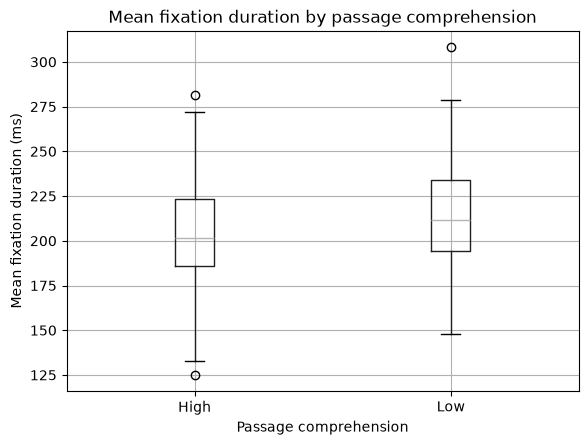

In [61]:
import matplotlib.pyplot as plt

analysis_complete.boxplot(
    column="mean_fix_duration",
    by="comprehension_level"
)

plt.xlabel("Passage comprehension")
plt.ylabel("Mean fixation duration (ms)")
plt.title("Mean fixation duration by passage comprehension")
plt.suptitle("")
plt.show()

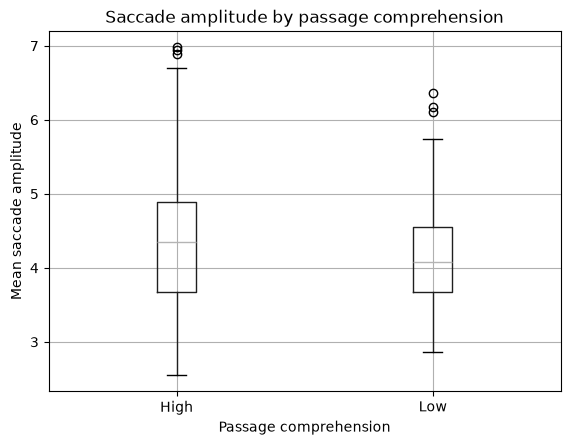

In [56]:
analysis_complete.boxplot(
    column="mean_saccade_amplitude",
    by="comprehension_level"
)

plt.xlabel("Passage comprehension")
plt.ylabel("Mean saccade amplitude")
plt.title("Saccade amplitude by passage comprehension")
plt.suptitle("")
plt.show()

## Initial descriptive results

The descriptive results show the same broad pattern as the original SB-SAT
study for several key reading measures:

* Low passage comprehension was associated with longer mean fixation durations
  (213.83 ms) than high comprehension (204.35 ms).
* Low passage comprehension was associated with smaller mean saccade amplitudes
  (4.16) than high comprehension (4.38).
* Participants made more fixations on passages with low comprehension
  (721.67) than on passages with high comprehension (678.58).
* Reading rate was lower for passages with low comprehension
  (212.71 WPM) than for passages with high comprehension (239.62 WPM).

The additional reading-specific measures showed smaller differences.
Refixation rate was somewhat higher for low-comprehension passages
(0.401) than for high-comprehension passages (0.379), whereas regression rate
was very similar between the groups (0.203 vs. 0.211). Page revisits and mean
pupil size also showed only small descriptive differences.

Overall, lower comprehension was descriptively associated with a slower and
more fixation-intensive reading pattern. However, these group means do not
establish whether the differences are statistically meaningful. Participants
contributed multiple passage observations, and the passages themselves differed
in content and length. These factors are therefore accounted for in the
subsequent mixed-effects analyses.

## Correlations between predictors

Before fitting multivariable statistical and predictive models, correlations
between the passage-level eye-tracking predictors are inspected.

This helps identify predictors that capture strongly overlapping aspects of
reading behaviour and could therefore introduce redundancy or
multicollinearity.

Only the primary version of each construct is included. For example, mean
fixation duration is retained instead of including both mean and median
fixation duration, and reading rate is used as the primary measure of reading
speed rather than including both reading rate and total reading time.

In [64]:
predictors = [
    "mean_fix_duration",
    "n_fixations",
    "mean_saccade_amplitude",
    "mean_pupil_size",
    "reading_rate_wpm",
    "n_page_revisits",
    "regression_rate",
    "refixation_rate"
]

correlations = analysis_complete[predictors].corr()

print(correlations.round(2))

                        mean_fix_duration  n_fixations  \
mean_fix_duration                    1.00         0.16   
n_fixations                          0.16         1.00   
mean_saccade_amplitude              -0.28        -0.53   
mean_pupil_size                     -0.15         0.01   
reading_rate_wpm                    -0.44        -0.78   
n_page_revisits                     -0.02         0.33   
regression_rate                     -0.21        -0.00   
refixation_rate                      0.09         0.69   

                        mean_saccade_amplitude  mean_pupil_size  \
mean_fix_duration                        -0.28            -0.15   
n_fixations                              -0.53             0.01   
mean_saccade_amplitude                    1.00             0.17   
mean_pupil_size                           0.17             1.00   
reading_rate_wpm                          0.63             0.03   
n_page_revisits                           0.16             0.01   
regressi

### Correlations between predictors

Several eye-tracking measures were substantially related, indicating that they
capture overlapping aspects of reading behaviour.

The strongest correlations involved reading rate:

* reading rate and number of fixations: r = -0.78;
* reading rate and refixation rate: r = -0.75;
* reading rate and mean saccade amplitude: r = 0.63.

Number of fixations was also positively related to refixation rate (r = 0.69),
while refixation rate was negatively related to saccade amplitude (r = -0.62).

Together, these relationships suggest a broader reading-speed or reading-
efficiency dimension: faster reading tends to involve fewer fixations, fewer
refixations, and larger forward eye movements.

Other measures showed considerably weaker relationships. In particular, pupil
size, page revisits, and regression rate were relatively distinct from the
general reading-speed pattern.

Because some predictors are strongly correlated, they should not all be
included simultaneously in the same multivariable statistical model.
Individual predictor models can still be examined separately.

In [65]:
multivariable_predictors = [
    "mean_fix_duration",
    "mean_saccade_amplitude",
    "mean_pupil_size",
    "reading_rate_wpm",
    "n_page_revisits",
    "regression_rate"
]

### Why mixed-effects models?

Observations are not independent because each participant reads multiple
passages. Mixed-effects models are commonly used for repeated-measures data
in psycholinguistics and eye-tracking research because they can account for
variation between participants and items/texts.

In the current analysis:
* Participant is included as a random intercept.
* Passage is included as a fixed effect because there are only four passages.
* Eye-tracking measures are included as fixed-effect predictors.

The initial analyses use linear mixed-effects models for exploratory purposes.
However, passage comprehension is based on the number of correct answers out
of five questions (0–5), rather than a truly continuous outcome. Therefore, a
binomial generalized linear mixed-effects model (GLMM) would be preferable for
a final confirmatory analysis.

In [66]:
# Is mean fixation duration associated with passage comprehension, while accounting for repeated observations from the same participant and differences between passages?

# Standardizatoin: 0     = average fixation duration
# +1    = 1 SD longer than average
# -1    = 1 SD shorter than average

# C(book_name): systematic differences per passage
# groups=participant: participants have four observations, thus not independent

analysis_complete["z_fix_duration"] = (
    analysis_complete["mean_fix_duration"]
    - analysis_complete["mean_fix_duration"].mean()
) / analysis_complete["mean_fix_duration"].std()

import statsmodels.formula.api as smf

model_fix = smf.mixedlm(
    "comprehension_score ~ z_fix_duration + C(book_name)",
    data=analysis_complete,
    groups=analysis_complete["RECORDING_SESSION_LABEL"]
)

result_fix = model_fix.fit(reml=False)

print(result_fix.summary())

               Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  comprehension_score
No. Observations:  357      Method:              ML                 
No. Groups:        95       Scale:               0.0452             
Min. group size:   1        Log-Likelihood:      20.5411            
Max. group size:   4        Converged:           Yes                
Mean group size:   3.8                                              
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.580    0.025 23.439 0.000  0.532  0.629
C(book_name)[T.flytrap]   -0.028    0.032 -0.879 0.380 -0.091  0.035
C(book_name)[T.genome]    -0.070    0.032 -2.163 0.031 -0.134 -0.007
C(book_name)[T.northpole]  0.041    0.032  1.270 0.204 -0.022  0.104
z_fix_duration            -0.035    0.015 -2.390 0

C:\Users\Tim\AppData\Local\Temp\ipykernel_16464\1333485859.py:23: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  result_fix = model_fix.fit(reml=False)


### Mixed-effects model: fixation duration

A linear mixed-effects model was used to examine whether mean fixation
duration was associated with passage comprehension. Participant was included
as a random intercept to account for repeated observations, and passage was
included as a fixed effect.

Mean fixation duration was standardized before analysis.

Longer mean fixation duration was significantly associated with lower
passage comprehension (β = -0.035, SE = 0.015, p = .017,
95% CI [-0.063, -0.006]).

Thus, a one-standard-deviation increase in mean fixation duration was
associated with an approximately 0.035 decrease in comprehension score,
after accounting for passage differences and repeated observations within
participants.

The model produced a boundary warning for the random-effect variance,
which should be considered when interpreting the model.

In [67]:
# Is greater mean saccade amplitude associated with passage comprehension, while accounting for repeated observations within participants and differences between passages?

# Standardize mean saccade amplitude
analysis_complete["z_saccade_amplitude"] = (
    analysis_complete["mean_saccade_amplitude"]
    - analysis_complete["mean_saccade_amplitude"].mean()
) / analysis_complete["mean_saccade_amplitude"].std()

# Mixed-effects model
model_saccade = smf.mixedlm(
    "comprehension_score ~ z_saccade_amplitude + C(book_name)",
    data=analysis_complete,
    groups=analysis_complete["RECORDING_SESSION_LABEL"]
)

result_saccade = model_saccade.fit(reml=False)

print(result_saccade.summary())

               Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  comprehension_score
No. Observations:  357      Method:              ML                 
No. Groups:        95       Scale:               0.0454             
Min. group size:   1        Log-Likelihood:      19.0192            
Max. group size:   4        Converged:           Yes                
Mean group size:   3.8                                              
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.586    0.025 23.718 0.000  0.538  0.634
C(book_name)[T.flytrap]   -0.037    0.032 -1.168 0.243 -0.100  0.025
C(book_name)[T.genome]    -0.079    0.032 -2.444 0.015 -0.142 -0.016
C(book_name)[T.northpole]  0.035    0.032  1.086 0.278 -0.028  0.098
z_saccade_amplitude        0.024    0.015  1.597 0

C:\Users\Tim\AppData\Local\Temp\ipykernel_16464\1504307507.py:16: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  result_saccade = model_saccade.fit(reml=False)


### Mixed-effects model: saccade amplitude

A linear mixed-effects model was used to examine whether mean saccade
amplitude was associated with passage comprehension. Participant was included
as a random intercept to account for repeated observations, and passage was
included as a fixed effect.

Mean saccade amplitude was standardized before analysis.

Mean saccade amplitude showed a positive, but non-significant, association
with passage comprehension (β = 0.024, SE = 0.015, p = .110,
95% CI [-0.005, 0.053]).

Thus, larger saccade amplitudes tended to be associated with higher
comprehension, but there was insufficient statistical evidence for this
relationship after accounting for passage differences and repeated
observations within participants.

The direction of the association is consistent with the descriptive results
and with the original SB-SAT study, but the effect was not statistically
significant in the mixed-effects analysis.

In [68]:
# Are more fixations during a passage associated with lower passage comprehension, after accounting for passage differences and repeated observations within participants?

# Standardize fixation count
analysis_complete["z_fixation_count"] = (
    analysis_complete["n_fixations"]
    - analysis_complete["n_fixations"].mean()
) / analysis_complete["n_fixations"].std()

# Mixed-effects model
model_fix_count = smf.mixedlm(
    "comprehension_score ~ z_fixation_count + C(book_name)",
    data=analysis_complete,
    groups=analysis_complete["RECORDING_SESSION_LABEL"]
)

result_fix_count = model_fix_count.fit(reml=False)

print(result_fix_count.summary())

               Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  comprehension_score
No. Observations:  357      Method:              ML                 
No. Groups:        95       Scale:               0.0451             
Min. group size:   1        Log-Likelihood:      17.8678            
Max. group size:   4        Converged:           Yes                
Mean group size:   3.8                                              
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.586    0.025 23.098 0.000  0.536  0.635
C(book_name)[T.flytrap]   -0.032    0.034 -0.926 0.354 -0.098  0.035
C(book_name)[T.genome]    -0.078    0.033 -2.349 0.019 -0.143 -0.013
C(book_name)[T.northpole]  0.029    0.032  0.907 0.364 -0.033  0.091
z_fixation_count          -0.006    0.015 -0.407 0

### Mixed-effects model: fixation count

A linear mixed-effects model was used to examine whether fixation count was
associated with passage comprehension. Participant was included as a random
intercept, and passage was included as a fixed effect.

Fixation count was standardized before analysis.

Fixation count was not significantly associated with passage comprehension
(β = -0.006, SE = 0.015, p = .684, 95% CI [-0.034, 0.023]).

Thus, the number of fixations made while reading a passage did not show a
meaningful relationship with passage comprehension after accounting for passage
differences and repeated observations within participants.

In [69]:
# Is mean pupil size associated with passage comprehension, after accounting for passage differences and repeated observations within participants?

# Standardize pupil size
analysis_complete["z_pupil_size"] = (
    analysis_complete["mean_pupil_size"]
    - analysis_complete["mean_pupil_size"].mean()
) / analysis_complete["mean_pupil_size"].std()

# Mixed-effects model
model_pupil = smf.mixedlm(
    "comprehension_score ~ z_pupil_size + C(book_name)",
    data=analysis_complete,
    groups=analysis_complete["RECORDING_SESSION_LABEL"]
)

result_pupil = model_pupil.fit(reml=False)

print(result_pupil.summary())

               Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  comprehension_score
No. Observations:  357      Method:              ML                 
No. Groups:        95       Scale:               0.0450             
Min. group size:   1        Log-Likelihood:      17.7854            
Max. group size:   4        Converged:           Yes                
Mean group size:   3.8                                              
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.588    0.025 23.626 0.000  0.539  0.636
C(book_name)[T.flytrap]   -0.036    0.032 -1.132 0.258 -0.099  0.026
C(book_name)[T.genome]    -0.081    0.032 -2.518 0.012 -0.144 -0.018
C(book_name)[T.northpole]  0.028    0.032  0.887 0.375 -0.034  0.090
z_pupil_size               0.000    0.015  0.018 0

### Mixed-effects model: pupil size

A linear mixed-effects model was used to examine whether mean pupil size was
associated with passage comprehension. Participant was included as a random
intercept, and passage was included as a fixed effect.

Mean pupil size was standardized before analysis.

Mean pupil size was not associated with passage comprehension
(β = 0.000, SE = 0.015, p = .986, 95% CI [-0.030, 0.030]).

Thus, mean pupil size did not provide evidence of a relationship with passage
comprehension after accounting for passage differences and repeated observations
within participants.

This is consistent with the original SB-SAT study, which also did not find
significant differences in pupil size between comprehension groups.

In [71]:
# Is regression rate associated with passage comprehension,
# after accounting for passage differences and repeated observations within participants?

# Keep fixations that landed on a defined word/interest area
reading_words = reading.dropna(
    subset=["CURRENT_FIX_INTEREST_AREA_ID"]
).copy()

# Previous word/interest area within the same participant, passage, and page
reading_words["previous_ia_id"] = (
    reading_words
    .groupby([
        "RECORDING_SESSION_LABEL",
        "book_name",
        "page"
    ])["CURRENT_FIX_INTEREST_AREA_ID"]
    .shift(1)
)

# A regression occurs when gaze moves back to an earlier interest area
reading_words["is_regression"] = (
    reading_words["CURRENT_FIX_INTEREST_AREA_ID"]
    < reading_words["previous_ia_id"]
)

# Calculate regression features per participant × passage
regression_features = (
    reading_words
    .dropna(subset=["previous_ia_id"])
    .groupby(["RECORDING_SESSION_LABEL", "book_name"])
    .agg(
        n_regressions=("is_regression", "sum"),
        n_transitions=("is_regression", "count")
    )
    .reset_index()
)

# Proportion of word-to-word transitions that are regressions
regression_features["regression_rate"] = (
    regression_features["n_regressions"]
    / regression_features["n_transitions"]
)

print(regression_features.head())

  RECORDING_SESSION_LABEL  book_name  n_regressions  n_transitions  \
0                  msd001    dickens             94            491   
1                  msd001    flytrap            139            632   
2                  msd001     genome             72            488   
3                  msd001  northpole             65            366   
4                  msd002    dickens             98            632   

   regression_rate  
0         0.191446  
1         0.219937  
2         0.147541  
3         0.177596  
4         0.155063  


In [73]:
analysis_complete = analysis_complete.merge(
    regression_features,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="left"
)

print(
    analysis_complete[
        ["n_regressions", "n_transitions", "regression_rate"]
    ].describe()
)

       n_regressions  n_transitions  regression_rate
count     357.000000     357.000000       357.000000
mean      137.081232     657.563025         0.208501
std        55.037134     182.291946         0.056074
min        14.000000      49.000000         0.039720
25%        97.000000     527.000000         0.173112
50%       130.000000     645.000000         0.206349
75%       167.000000     789.000000         0.244074
max       390.000000    1139.000000         0.403712


In [74]:
# Standardize regression rate
analysis_complete["z_regression_rate"] = (
    analysis_complete["regression_rate"]
    - analysis_complete["regression_rate"].mean()
) / analysis_complete["regression_rate"].std()

# Mixed-effects model
model_regression = smf.mixedlm(
    "comprehension_score ~ z_regression_rate + C(book_name)",
    data=analysis_complete,
    groups=analysis_complete["RECORDING_SESSION_LABEL"]
)

result_regression = model_regression.fit(reml=False)

print(result_regression.summary())

               Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  comprehension_score
No. Observations:  357      Method:              ML                 
No. Groups:        95       Scale:               0.0449             
Min. group size:   1        Log-Likelihood:      18.4451            
Max. group size:   4        Converged:           Yes                
Mean group size:   3.8                                              
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.584    0.025 23.407 0.000  0.535  0.633
C(book_name)[T.flytrap]   -0.032    0.032 -0.987 0.323 -0.095  0.031
C(book_name)[T.genome]    -0.076    0.032 -2.346 0.019 -0.139 -0.012
C(book_name)[T.northpole]  0.032    0.032  1.007 0.314 -0.030  0.094
z_regression_rate          0.017    0.015  1.150 0

### Mixed-effects model: regression rate

A linear mixed-effects model was used to examine whether regression rate was
associated with passage comprehension. Participant was included as a random
intercept, and passage was included as a fixed effect.

Regression rate was standardized before analysis.

Regression rate was not significantly associated with passage comprehension
(β = 0.017, SE = 0.015, p = .250, 95% CI [-0.012, 0.046]).

The coefficient was positive, suggesting that a higher regression rate tended
to be associated with slightly higher comprehension, but there was insufficient
statistical evidence for this relationship after accounting for passage
differences and repeated observations within participants.

In [77]:
# Reading rate: valid RT observations only
#The coefficient represents the expected change in passage comprehension score associated with a 1 SD increase in reading rate, controlling for passage and participant-level repeated measurements.
analysis_reading_rate = (
    analysis_complete
    .dropna(subset=["reading_rate_wpm"])
    .copy()
)

# Standardize reading rate
analysis_reading_rate["z_reading_rate"] = (
    analysis_reading_rate["reading_rate_wpm"]
    - analysis_reading_rate["reading_rate_wpm"].mean()
) / analysis_reading_rate["reading_rate_wpm"].std()

# Mixed-effects model
model_reading_rate = smf.mixedlm(
    "comprehension_score ~ z_reading_rate + C(book_name)",
    data=analysis_reading_rate,
    groups=analysis_reading_rate["RECORDING_SESSION_LABEL"]
)

result_reading_rate = model_reading_rate.fit(reml=False)

print(result_reading_rate.summary())

               Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  comprehension_score
No. Observations:  352      Method:              ML                 
No. Groups:        95       Scale:               0.0445             
Min. group size:   1        Log-Likelihood:      20.2040            
Max. group size:   4        Converged:           Yes                
Mean group size:   3.7                                              
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.581    0.026 22.569 0.000  0.531  0.632
C(book_name)[T.flytrap]   -0.029    0.033 -0.899 0.369 -0.093  0.035
C(book_name)[T.genome]    -0.070    0.034 -2.040 0.041 -0.138 -0.003
C(book_name)[T.northpole]  0.028    0.033  0.859 0.390 -0.036  0.093
z_reading_rate             0.021    0.015  1.423 0

C:\Users\Tim\AppData\Local\Temp\ipykernel_16464\1188383575.py:22: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  result_reading_rate = model_reading_rate.fit(reml=False)


### Mixed-effects model: reading rate

A linear mixed-effects model was used to examine whether reading rate was
associated with passage comprehension. Participant was included as a random
intercept, and passage was included as a fixed effect.

Reading rate was standardized before analysis. Observations without a valid
reading-rate value were excluded from this model.

Reading rate was not significantly associated with passage comprehension
(β = 0.021, SE = 0.015, p = .155, 95% CI [-0.008, 0.049]).

The coefficient was positive, suggesting that faster reading tended to be
associated with slightly higher comprehension, but there was insufficient
statistical evidence for this relationship after accounting for passage
differences and repeated observations within participants.

In [78]:
# Standardize number of page revisits
analysis_complete["z_page_revisits"] = (
    analysis_complete["n_page_revisits"]
    - analysis_complete["n_page_revisits"].mean()
) / analysis_complete["n_page_revisits"].std()

# Mixed-effects model
model_page_revisits = smf.mixedlm(
    "comprehension_score ~ z_page_revisits + C(book_name)",
    data=analysis_complete,
    groups=analysis_complete["RECORDING_SESSION_LABEL"]
)

result_page_revisits = model_page_revisits.fit(reml=False)

print(result_page_revisits.summary())

               Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  comprehension_score
No. Observations:  357      Method:              ML                 
No. Groups:        95       Scale:               0.0451             
Min. group size:   1        Log-Likelihood:      17.8135            
Max. group size:   4        Converged:           Yes                
Mean group size:   3.8                                              
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.588    0.025 23.651 0.000  0.539  0.637
C(book_name)[T.flytrap]   -0.036    0.032 -1.137 0.256 -0.099  0.026
C(book_name)[T.genome]    -0.081    0.032 -2.516 0.012 -0.144 -0.018
C(book_name)[T.northpole]  0.028    0.032  0.872 0.383 -0.034  0.090
z_page_revisits            0.003    0.013  0.238 0

### Mixed-effects model: page revisits

A linear mixed-effects model was used to examine whether the number of page
revisits was associated with passage comprehension. Participant was included
as a random intercept, and passage was included as a fixed effect.

The number of page revisits was standardized before analysis.

Page revisits were not significantly associated with passage comprehension
(β = 0.003, SE = 0.013, p = .812, 95% CI [-0.023, 0.029]).

The coefficient was close to zero, providing no evidence that revisiting pages
more frequently was associated with higher or lower passage comprehension after
accounting for passage differences and repeated observations within
participants.

In [79]:
# Standardize refixation rate
analysis_complete["z_refixation_rate"] = (
    analysis_complete["refixation_rate"]
    - analysis_complete["refixation_rate"].mean()
) / analysis_complete["refixation_rate"].std()

# Mixed-effects model
model_refixation = smf.mixedlm(
    "comprehension_score ~ z_refixation_rate + C(book_name)",
    data=analysis_complete,
    groups=analysis_complete["RECORDING_SESSION_LABEL"]
)

result_refixation = model_refixation.fit(reml=False)

print(result_refixation.summary())

               Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  comprehension_score
No. Observations:  357      Method:              ML                 
No. Groups:        95       Scale:               0.0450             
Min. group size:   1        Log-Likelihood:      17.7937            
Max. group size:   4        Converged:           Yes                
Mean group size:   3.8                                              
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.587    0.025 23.041 0.000  0.537  0.637
C(book_name)[T.flytrap]   -0.036    0.032 -1.100 0.271 -0.099  0.028
C(book_name)[T.genome]    -0.079    0.034 -2.328 0.020 -0.146 -0.013
C(book_name)[T.northpole]  0.029    0.032  0.895 0.371 -0.035  0.092
z_refixation_rate         -0.002    0.015 -0.131 0

### Mixed-effects model: refixation rate

A linear mixed-effects model was used to examine whether refixation rate was
associated with passage comprehension. Participant was included as a random
intercept, and passage was included as a fixed effect.

Refixation rate was standardized before analysis.

Refixation rate was not significantly associated with passage comprehension
(β = -0.002, SE = 0.015, p = .896, 95% CI [-0.030, 0.027]).

The coefficient was effectively zero, indicating no evidence that a greater
tendency to fixate words multiple times was associated with passage
comprehension after accounting for passage differences and repeated
observations within participants.

### Follow-up analysis: binomial generalized linear mixed-effects model

The initial analyses used linear mixed-effects models with passage comprehension
score (0.0–1.0) as the outcome.

However, passage comprehension is based on the number of correct answers to
five comprehension questions. The possible scores are therefore discrete
(0, 0.2, 0.4, 0.6, 0.8, and 1.0), rather than truly continuous.

A binomial generalized linear mixed-effects model (GLMM) is therefore used as
a follow-up robustness analysis. Instead of treating the passage-level
comprehension proportion as continuous, the model considers whether each
individual comprehension question was answered correctly or incorrectly.

Across the exploratory linear mixed-effects models, mean fixation duration was
the only eye-tracking measure that showed a statistically significant
association with passage comprehension. The first GLMM therefore focuses on
this measure.

The model examines whether mean fixation duration predicts the probability of
answering a comprehension question correctly while:

* accounting for repeated observations from the same participant using a
  participant random intercept;
* controlling for systematic differences between passages using passage as a
  fixed effect.

The aim is to examine whether the negative relationship between fixation
duration and comprehension remains when the outcome is modelled using a
binomial distribution.

In [80]:
# Keep fixation duration for the complete participant × passage observations
fixation_for_glmm = analysis_complete[
    [
        "RECORDING_SESSION_LABEL",
        "book_name",
        "z_fix_duration"
    ]
].copy()

# Merge passage-level fixation duration with individual comprehension questions
glmm_df = comprehension_questions.merge(
    fixation_for_glmm,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

print(glmm_df.head(10))
print(glmm_df.shape)
print(glmm_df["correct"].value_counts())

  RECORDING_SESSION_LABEL book_name  page  answer  correct_answer  correct  \
0                  msd001   dickens     1       1               1        1   
1                  msd001   dickens     2       3               3        1   
2                  msd001   dickens     3       3               1        0   
3                  msd001   dickens     4       4               4        1   
4                  msd001   dickens     5       2               3        0   
5                  msd001   flytrap     1       1               1        1   
6                  msd001   flytrap     2       3               3        1   
7                  msd001   flytrap     3       4               4        1   
8                  msd001   flytrap     4       2               2        1   
9                  msd001   flytrap     5       4               2        0   

   z_fix_duration  
0       -0.874583  
1       -0.874583  
2       -0.874583  
3       -0.874583  
4       -0.874583  
5       -0.311707  
6

In [81]:
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

# Is mean fixation duration associated with the probability of answering
# a comprehension question correctly?

model_glmm_fix = BinomialBayesMixedGLM.from_formula(
    "correct ~ z_fix_duration + C(book_name)",
    {
        "participant": "0 + C(RECORDING_SESSION_LABEL)"
    },
    glmm_df
)

result_glmm_fix = model_glmm_fix.fit_vb()

print(result_glmm_fix.summary())

                       Binomial Mixed GLM Results
                          Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
------------------------------------------------------------------------
Intercept                    M     0.3395   0.0487                      
C(book_name)[T.flytrap]      M    -0.1189   0.0969                      
C(book_name)[T.genome]       M    -0.2952   0.0975                      
C(book_name)[T.northpole]    M     0.1772   0.0973                      
z_fix_duration               M    -0.1479   0.0490                      
participant                  V    -0.9177   0.0727 0.399   0.345   0.462
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


### Binomial GLMM: fixation duration

Because passage comprehension is based on five individual comprehension
questions, a binomial mixed-effects model was used as a follow-up analysis.

Correct/incorrect responses to individual comprehension questions were used
as the outcome. Mean fixation duration was measured at the participant × passage
level and standardized before analysis.

Participant was included as a random intercept to account for repeated
observations, and passage was included as a fixed effect.

Mean fixation duration showed a negative association with the probability of
answering a comprehension question correctly
(posterior mean = -0.148, posterior SD = 0.049).

Thus, longer mean fixation durations were associated with a lower probability
of answering comprehension questions correctly.

This result is consistent with the earlier linear mixed-effects model:

* **LMM:** longer fixation duration was associated with lower passage
  comprehension (β = -0.035, p = .017).
* **Binomial GLMM:** longer fixation duration was associated with a lower
  probability of answering an individual comprehension question correctly
  (posterior mean = -0.148, posterior SD = 0.049).

The consistency between the two analyses strengthens the evidence that mean
fixation duration is related to comprehension.

#### Participant differences

The estimated standard deviation of the participant random intercept was
approximately 0.399. This indicates variation between participants in their
general probability of answering comprehension questions correctly, supporting
the inclusion of participant as a random effect.

#### Passage differences

Dickens was the reference passage. Relative to Dickens, the estimated passage
effects were:

* Flytrap: -0.119
* Genome: -0.295
* Northpole: 0.177

Genome showed the strongest negative estimated difference relative to Dickens.
These passage effects are included primarily to control for systematic
differences between texts rather than being the main focus of the analysis.

### Next analysis: multivariable GLMM

The previous analyses examined each eye-tracking measure separately.

The next step is to examine whether mean fixation duration remains associated
with comprehension when other characteristics of reading behaviour are included
in the same model.

A multivariable binomial GLMM will include:

* mean fixation duration;
* mean saccade amplitude;
* reading rate;
* regression rate;
* passage as a fixed effect;
* participant as a random intercept.

Reading rate is included because it represents overall reading speed and showed
a clear descriptive difference between high- and low-comprehension passages.
Including it allows examination of whether fixation duration provides information
about comprehension beyond simply reading faster or slower.

Not all available predictors are included simultaneously. Number of fixations
and refixation rate are strongly correlated with reading rate, suggesting that
these measures partly capture the same broader reading-efficiency dimension.
Including all of them would introduce substantial redundancy and make individual
coefficients harder to interpret.

Mean and median fixation duration are also not included together because they
are highly correlated. Page revisits and pupil size are excluded because the
single-predictor analyses provided little evidence that they were associated
with comprehension.

The model therefore aims to balance coverage of distinct aspects of reading
behaviour with interpretability and limited multicollinearity.

In [83]:
multivariable_df = analysis_complete.dropna(
    subset=[
        "mean_fix_duration",
        "mean_saccade_amplitude",
        "reading_rate_wpm",
        "regression_rate"
    ]
).copy()

In [88]:
#Standardize

multivariable_df["z_fix_duration"] = (
    multivariable_df["mean_fix_duration"]
    - multivariable_df["mean_fix_duration"].mean()
) / multivariable_df["mean_fix_duration"].std()

multivariable_df["z_saccade_amplitude"] = (
    multivariable_df["mean_saccade_amplitude"]
    - multivariable_df["mean_saccade_amplitude"].mean()
) / multivariable_df["mean_saccade_amplitude"].std()

multivariable_df["z_reading_rate"] = (
    multivariable_df["reading_rate_wpm"]
    - multivariable_df["reading_rate_wpm"].mean()
) / multivariable_df["reading_rate_wpm"].std()

multivariable_df["z_regression_rate"] = (
    multivariable_df["regression_rate"]
    - multivariable_df["regression_rate"].mean()
) / multivariable_df["regression_rate"].std()

In [87]:
glmm_multi_df = comprehension_questions.merge(
    multivariable_df[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "z_fix_duration",
            "z_saccade_amplitude",
            "z_reading_rate",
            "z_regression_rate"
        ]
    ],
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

print(glmm_multi_df.shape)

(1760, 10)


In [89]:
model_glmm_multi = BinomialBayesMixedGLM.from_formula(
    """
    correct ~
    z_fix_duration +
    z_saccade_amplitude +
    z_reading_rate +
    z_regression_rate +
    C(book_name)
    """,
    {
        "participant":
        "0 + C(RECORDING_SESSION_LABEL)"
    },
    glmm_multi_df
)

result_glmm_multi = model_glmm_multi.fit_vb()

print(result_glmm_multi.summary())

                       Binomial Mixed GLM Results
                          Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
------------------------------------------------------------------------
Intercept                    M     0.3395   0.0491                      
C(book_name)[T.flytrap]      M    -0.1203   0.0970                      
C(book_name)[T.genome]       M    -0.2992   0.0981                      
C(book_name)[T.northpole]    M     0.1480   0.0981                      
z_fix_duration               M    -0.1340   0.0493                      
z_saccade_amplitude          M     0.0334   0.0498                      
z_reading_rate               M     0.0198   0.0497                      
z_regression_rate            M     0.0229   0.0492                      
participant                  V    -0.9321   0.0727 0.394   0.340   0.455
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


### Multivariable binomial GLMM

A multivariable binomial mixed-effects model was used to examine whether mean
fixation duration remained associated with comprehension when other aspects of
reading behaviour were considered simultaneously.

The model included:

* mean fixation duration;
* mean saccade amplitude;
* reading rate;
* regression rate;
* passage as a fixed effect;
* participant as a random intercept.

All eye-tracking predictors were standardized before analysis. The coefficients
therefore represent the change in log odds of answering a comprehension question
correctly associated with a one-standard-deviation increase in the predictor,
while holding the other predictors constant.

Mean fixation duration remained negatively associated with the probability of
answering a comprehension question correctly
(posterior mean = -0.134, posterior SD = 0.049).

The approximate 95% posterior interval was [-0.231, -0.037], remaining below
zero. On the odds scale, this corresponds to an odds ratio of approximately
0.87. Thus, a one-standard-deviation increase in mean fixation duration was
associated with approximately 13% lower odds of answering a comprehension
question correctly, while holding the other eye-tracking measures and passage
constant.

Mean saccade amplitude showed only a small positive estimate
(posterior mean = 0.033, posterior SD = 0.050), with an approximate 95%
posterior interval of [-0.064, 0.131]. This provides little evidence for an
independent association with comprehension.

Reading rate also showed little evidence of an independent association
(posterior mean = 0.020, posterior SD = 0.050; approximate 95% posterior
interval [-0.078, 0.117]). Although faster reading was descriptively associated
with higher comprehension, this relationship largely disappeared after other
reading characteristics were considered simultaneously.

Regression rate similarly showed a small positive estimate
(posterior mean = 0.023, posterior SD = 0.049; approximate 95% posterior
interval [-0.074, 0.119]), providing little evidence for an independent
relationship with comprehension.

Overall, mean fixation duration was the only included eye-tracking measure that
showed a clear independent relationship with comprehension in the multivariable
model.

Is comprehension related to the fact that some students generally have longer fixations than others, or is it related to a student having longer fixations than usual for that particular student on a passage?

Between-person effect asks:
Do students who generally have longer average fixation durations across passages also tend to have lower comprehension overall?

Within-person effect asks:
When the same student has longer fixation durations than their own usual level on a particular passage, is their comprehension on that passage lower?

In [92]:
# Participant's average fixation duration across passages
analysis_complete["person_mean_fix_duration"] = (
    analysis_complete
    .groupby("RECORDING_SESSION_LABEL")["mean_fix_duration"]
    .transform("mean")
)

# Deviation from that participant's own average
analysis_complete["within_fix_duration"] = (
    analysis_complete["mean_fix_duration"]
    - analysis_complete["person_mean_fix_duration"]
)

analysis_complete["z_between_fix_duration"] = (
    analysis_complete["person_mean_fix_duration"]
    - analysis_complete["person_mean_fix_duration"].mean()
) / analysis_complete["person_mean_fix_duration"].std()

analysis_complete["z_within_fix_duration"] = (
    analysis_complete["within_fix_duration"]
    - analysis_complete["within_fix_duration"].mean()
) / analysis_complete["within_fix_duration"].std()

In [93]:
glmm_within_between_df = comprehension_questions.merge(
    analysis_complete[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "z_between_fix_duration",
            "z_within_fix_duration"
        ]
    ],
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

print(glmm_within_between_df.shape)

(1785, 8)


In [94]:
model_glmm_within_between = BinomialBayesMixedGLM.from_formula(
    """
    correct ~
        z_between_fix_duration +
        z_within_fix_duration +
        C(book_name)
    """,
    {
        "participant": "0 + C(RECORDING_SESSION_LABEL)"
    },
    glmm_within_between_df
)

result_glmm_within_between = model_glmm_within_between.fit_vb()

print(result_glmm_within_between.summary())

                       Binomial Mixed GLM Results
                          Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
------------------------------------------------------------------------
Intercept                    M     0.3759   0.0488                      
C(book_name)[T.flytrap]      M    -0.1537   0.0970                      
C(book_name)[T.genome]       M    -0.3457   0.0975                      
C(book_name)[T.northpole]    M     0.1197   0.0974                      
z_between_fix_duration       M    -0.1619   0.0489                      
z_within_fix_duration        M     0.0043   0.0493                      
participant                  V    -0.9185   0.0727 0.399   0.345   0.462
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


### Within-person versus between-person fixation duration

To examine whether the fixation-duration effect reflects differences between
students or changes within the same student across passages, mean fixation
duration was decomposed into:

* **Between-person fixation duration:** a participant's average fixation
  duration across passages.
* **Within-person fixation duration:** the deviation in fixation duration for
  a particular passage from that participant's own average.

A binomial mixed-effects model included both components, passage as a fixed
effect, and participant as a random intercept.

The between-person fixation-duration effect was clearly negative
(posterior mean = -0.162, posterior SD = 0.049; approximate 95% posterior
interval [-0.258, -0.066]).

This corresponds to an odds ratio of approximately 0.85: participants whose
average fixation duration was one standard deviation higher had approximately
15% lower odds of answering a comprehension question correctly.

In contrast, the within-person fixation-duration effect was close to zero
(posterior mean = 0.004, posterior SD = 0.049; approximate 95% posterior
interval [-0.092, 0.101]).

Thus, the previously observed relationship between longer fixation durations
and lower comprehension appears to be primarily a **between-reader effect**.
There was no clear evidence that a student having longer fixations than usual
on a particular passage was associated with lower comprehension on that
passage.

This distinction is relevant for interpreting eye-tracking analytics:
fixation duration may reflect relatively stable differences between readers
more strongly than passage-specific comprehension difficulty.

### Sensitivity analysis

Nine participant × passage observations showed fixation-time coverage below
50%, meaning that less than half of the independently recorded reading time was
represented by identified fixations.

These observations were retained in the main analysis because the 50% threshold
was used as an exploratory quality-control criterion rather than as an
established exclusion rule. Importantly, observations were not excluded simply
because they showed extreme eye-tracking feature values.

As a sensitivity analysis, the key multivariable model was repeated after
excluding all nine low-coverage observations. The purpose was to examine whether
potentially sparse eye-tracking recordings materially influenced the estimated
relationships between the eye-tracking measures and comprehension.

If the coefficients and their interpretation remain similar after excluding
these observations, this provides evidence that the main findings are robust to
potentially incomplete fixation recordings.

In [97]:
# Sensitivity dataset:
# same observations as the multivariable model,
# but exclude low fixation-coverage recordings
multivariable_sensitivity_df = multivariable_df[
    ~multivariable_df["low_fixation_coverage"]
].copy()

print("Main multivariable sample:", len(multivariable_df))
print("Sensitivity sample:", len(multivariable_sensitivity_df))

Main multivariable sample: 352
Sensitivity sample: 343


In [98]:
predictors_sensitivity = multivariable_sensitivity_df[
    [
        "RECORDING_SESSION_LABEL",
        "book_name",
        "z_fix_duration",
        "z_saccade_amplitude",
        "z_reading_rate",
        "z_regression_rate"
    ]
].copy()

glmm_sensitivity_df = comprehension_questions.merge(
    predictors_sensitivity,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

print(glmm_sensitivity_df.shape)

(1715, 10)


In [99]:
model_glmm_sensitivity = BinomialBayesMixedGLM.from_formula(
    """
    correct ~
        z_fix_duration +
        z_saccade_amplitude +
        z_reading_rate +
        z_regression_rate +
        C(book_name)
    """,
    {
        "participant": "0 + C(RECORDING_SESSION_LABEL)"
    },
    glmm_sensitivity_df
)

result_glmm_sensitivity = model_glmm_sensitivity.fit_vb()

print(result_glmm_sensitivity.summary())

                       Binomial Mixed GLM Results
                          Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
------------------------------------------------------------------------
Intercept                    M     0.3360   0.0496                      
C(book_name)[T.flytrap]      M    -0.1431   0.0984                      
C(book_name)[T.genome]       M    -0.2766   0.0992                      
C(book_name)[T.northpole]    M     0.1526   0.0980                      
z_fix_duration               M    -0.1248   0.0514                      
z_saccade_amplitude          M     0.0444   0.0509                      
z_reading_rate               M     0.0174   0.0502                      
z_regression_rate            M     0.0238   0.0500                      
participant                  V    -0.9398   0.0727 0.391   0.338   0.452
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


### Sensitivity analysis

Nine participant × passage observations had fixation-time coverage below 50%,
meaning that less than half of the recorded reading time was represented by
identified fixations. These observations were retained in the main analysis
because the 50% threshold is an exploratory quality-control criterion rather
than an established exclusion rule.

To examine whether these potentially sparse eye-tracking recordings influenced
the findings, the multivariable binomial GLMM was repeated after excluding all
nine low-coverage observations. The model specification and standardized
predictors were otherwise kept unchanged.

The results were very similar to the main model:

* Mean fixation duration:
  * Main model: posterior mean = -0.134
  * Sensitivity model: posterior mean = -0.125, posterior SD = 0.051
* Mean saccade amplitude:
  * Main model: posterior mean = 0.033
  * Sensitivity model: posterior mean = 0.044
* Reading rate:
  * Main model: posterior mean = 0.020
  * Sensitivity model: posterior mean = 0.017
* Regression rate:
  * Main model: posterior mean = 0.023
  * Sensitivity model: posterior mean = 0.024

For mean fixation duration, the approximate 95% posterior interval in the
sensitivity model remained below zero [-0.226, -0.024].

On the odds scale, the sensitivity estimate corresponds to an odds ratio of
approximately 0.88. Thus, a one-standard-deviation increase in mean fixation
duration was associated with approximately 12% lower odds of answering a
comprehension question correctly after excluding the potentially low-quality
recordings.

The estimates for saccade amplitude, reading rate, and regression rate remained
small and their approximate posterior intervals included zero.

Overall, excluding the nine observations with low fixation-time coverage did
not materially change the results. The negative association between mean
fixation duration and comprehension therefore does not appear to be driven by
the potentially sparse eye-tracking recordings.

# Machine-learning analysis

## Aim

The aim of the machine-learning analysis is to examine whether eye-tracking
behaviour can be used to predict passage comprehension.

The statistical analyses above examined associations between eye-tracking
measures and comprehension. The machine-learning analysis extends this by
examining whether multiple characteristics of reading behaviour can jointly
distinguish between low and high passage comprehension.

## Prediction target

The initial prediction target is:

* **Passage comprehension: Low vs High**

This follows the definition used in the original SB-SAT study:

* High comprehension: comprehension score >= median (.60)
* Low comprehension: comprehension score < median (.60)

The unit of analysis remains **participant × passage**, so the eye-tracking
features used to make a prediction correspond to the same passage for which
comprehension was measured.

## Initial features

The feature-based analysis uses interpretable passage-level measures capturing
different aspects of reading behaviour:

* **Mean fixation duration** – average duration of individual fixations;
* **Fixation count** – total number of recorded fixations during the passage;
* **Mean saccade amplitude** – average size of eye movements between fixations;
* **Mean pupil size** – average pupil size during reading;
* **Reading rate (WPM)** – overall speed of reading, adjusted for passage length;
* **Page revisits** – number of additional page presentations during a passage;
* **Regression rate** – proportion of word-to-word transitions moving backwards
  in the text;
* **Refixation rate** – proportion of fixated words receiving more than one
  fixation within a reading trial.

Together, these measures represent reading speed, fixation behaviour, eye-movement
progression, rereading behaviour, and pupil response.

Some predictors are substantially correlated. In particular, reading rate is
strongly related to fixation count and refixation rate. This is less problematic
for prediction than for interpreting regression coefficients, so the full feature
set is initially retained. However, feature-importance estimates should be
interpreted cautiously because correlated predictors can share predictive
information.

Observations without a valid reading-rate value are excluded from models using
this feature. The resulting machine-learning sample therefore contains complete
passage observations with valid values for all selected predictors.

## Models

Several supervised machine-learning approaches are compared based on Mohamed Selim A, Barz M, Bhatti OS, Alam HMT and Sonntag D (2024) A review of machine learning in scanpath analysis for passive gaze-based interaction. Front. Artif. Intell. 7:1391745. doi: 10.3389/frai.2024.1391745:

1. **Logistic regression**
   * Provides an interpretable linear baseline.
   * Tests whether the classes can be separated using a relatively simple
     combination of the eye-tracking features.

2. **Random Forest**
   * Can capture nonlinear relationships and interactions between eye-tracking
     measures.
   * Allows examination of feature importance.

3. **Support Vector Machine (SVM)**
   * Suitable for relatively small tabular datasets.
   * Can model nonlinear decision boundaries through kernel functions.

4. **XGBoost**
   * Uses gradient-boosted decision trees to capture nonlinear relationships
     and feature interactions.
   * Provides an additional tree-based comparison with Random Forest.

A majority-class classifier is included as a baseline.

## Model evaluation

The primary evaluation focuses on generalization to **unseen participants**.

The same participant must not occur in both the training and test sets. This is
important because eye-tracking behaviour contains substantial individual
differences. A random row-level split could allow the model to exploit
participant-specific reading characteristics and therefore overestimate
performance for new students.

**StratifiedGroupKFold cross-validation** is therefore used. This keeps all
observations from the same participant within the same fold while also aiming
to preserve the Low/High class distribution across folds.

Because the Low and High comprehension classes are not perfectly balanced,
accuracy alone is not sufficient. Performance is evaluated using:

* accuracy;
* balanced accuracy;
* F1-score;
* ROC-AUC.

Balanced accuracy and ROC-AUC are particularly useful when comparing models
with the majority-class baseline.

## Important limitation of the feature-based approach

The feature-based analysis aggregates eye movements over the complete passage.
This aligns the predictors with the passage-level comprehension outcome and
produces relatively interpretable indicators of reading behaviour.

However, aggregation removes the temporal structure of the eye-tracking data.
For example, two students could have the same mean fixation duration while
showing very different patterns of eye movements throughout the passage.

A subsequent sequence-based analysis therefore examines whether preserving
temporal information provides additional predictive value.

The two approaches provide complementary perspectives:

**Feature-based ML**  
→ summarizes interpretable characteristics of reading behaviour across a passage

**Sequence-based ML**  
→ examines how eye-tracking behaviour develops throughout the passage

In [100]:
ml_features = [
    "mean_fix_duration",
    "n_fixations",
    "mean_saccade_amplitude",
    "mean_pupil_size",
    "reading_rate_wpm",
    "n_page_revisits",
    "regression_rate",
    "refixation_rate"
]

In [102]:

# Create ML dataframe
ml_df = analysis_complete[
    [
        "RECORDING_SESSION_LABEL",
        "book_name",
        "comprehension_level"
    ] + ml_features
].dropna().copy()

# Encode target:
# Low = 0
# High = 1
ml_df["target"] = (
    ml_df["comprehension_level"] == "High"
).astype(int)

# Predictors, target, and participant groups
X = ml_df[ml_features]
y = ml_df["target"]
groups = ml_df["RECORDING_SESSION_LABEL"]

print("Number of observations:", len(ml_df))
print("Number of participants:", ml_df["RECORDING_SESSION_LABEL"].nunique())

print("\nClass distribution:")
print(ml_df["comprehension_level"].value_counts())

print("\nClass proportions:")
print(ml_df["comprehension_level"].value_counts(normalize=True).round(3))

print("\nFeatures:")
print(X.head())

Number of observations: 352
Number of participants: 95

Class distribution:
comprehension_level
High    215
Low     137
Name: count, dtype: int64

Class proportions:
comprehension_level
High    0.611
Low     0.389
Name: proportion, dtype: float64

Features:
   mean_fix_duration  n_fixations  mean_saccade_amplitude  mean_pupil_size  \
0         182.131373          510                5.353921      1610.600000   
1         198.790373          644                4.832022      1684.288820   
2         205.161677          501                4.912505      1609.059880   
3         184.591146          384                4.548945      1456.223958   
4         234.771053          760                3.406000      1727.018421   

   reading_rate_wpm  n_page_revisits  regression_rate  refixation_rate  
0        347.765411                0         0.191446         0.282051  
1        285.052987                0         0.219937         0.330025  
2        303.951974                0         0.147541 

In [103]:
from sklearn.model_selection import StratifiedGroupKFold

RANDOM_STATE = 88

# Group
#→ keeps all passages from one participant in the same fold --> original SB-SAT study found substantial problems generalizing to new readers

#Stratified
#→ tries to keep the Low/High class distribution reasonably similar across folds

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [104]:
train_idx, test_idx = next(
    cv.split(X, y, groups=groups)
)

train_participants = set(groups.iloc[train_idx])
test_participants = set(groups.iloc[test_idx])

print("Training observations:", len(train_idx))
print("Test observations:", len(test_idx))

print("Training participants:", len(train_participants))
print("Test participants:", len(test_participants))

print(
    "Participants appearing in both:",
    train_participants.intersection(test_participants)
)

Training observations: 281
Test observations: 71
Training participants: 76
Test participants: 19
Participants appearing in both: set()


In [105]:
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate


# Evaluation metrics
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [106]:
# Majority-class baseline
baseline = DummyClassifier(strategy="most_frequent")

baseline_results = cross_validate(
    baseline,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring
)

print("Baseline performance:")

for metric in scoring:
    scores = baseline_results[f"test_{metric}"]
    print(
        f"{metric}: {scores.mean():.3f} "
        f"(SD = {scores.std():.3f})"
    )

Baseline performance:
accuracy: 0.611 (SD = 0.005)
balanced_accuracy: 0.500 (SD = 0.000)
f1: 0.758 (SD = 0.004)
roc_auc: 0.500 (SD = 0.000)


In [107]:
# Logistic regression pipeline
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

logistic_results = cross_validate(
    logistic_model,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring
)

print("\nLogistic regression performance:")

for metric in scoring:
    scores = logistic_results[f"test_{metric}"]
    print(
        f"{metric}: {scores.mean():.3f} "
        f"(SD = {scores.std():.3f})"
    )


Logistic regression performance:
accuracy: 0.597 (SD = 0.024)
balanced_accuracy: 0.519 (SD = 0.025)
f1: 0.725 (SD = 0.019)
roc_auc: 0.546 (SD = 0.049)


In [108]:
comparison = pd.DataFrame({
    "Metric": list(scoring.keys()),
    "Baseline": [
        baseline_results[f"test_{metric}"].mean()
        for metric in scoring
    ],
    "Logistic Regression": [
        logistic_results[f"test_{metric}"].mean()
        for metric in scoring
    ]
})

print(comparison.round(3))

              Metric  Baseline  Logistic Regression
0           accuracy     0.611                0.597
1  balanced_accuracy     0.500                0.519
2                 f1     0.758                0.725
3            roc_auc     0.500                0.546


### Logistic regression baseline

A logistic regression model was evaluated using 5-fold
StratifiedGroupKFold cross-validation, ensuring that participants in the
test folds were not present in the training data.

Performance was compared with a majority-class baseline.

| Metric | Baseline | Logistic regression |
|---|---:|---:|
| Accuracy | 0.611 | 0.597 |
| Balanced accuracy | 0.500 | 0.519 |
| F1-score | 0.758 | 0.725 |
| ROC-AUC | 0.500 | 0.546 |

Logistic regression showed only limited predictive performance.

Although balanced accuracy (0.519) and ROC-AUC (0.546) were slightly above
chance, overall accuracy was lower than the majority-class baseline.

This suggests that the selected aggregated eye-tracking features contain some
information related to comprehension, but are insufficient for reliably
classifying Low versus High passage comprehension for unseen participants.

This also illustrates the distinction between statistical association and
predictive performance: an eye-tracking measure may show a statistically
detectable relationship with comprehension without being sufficiently
informative for accurate individual predictions.

In [109]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__l1_ratio": [0.0, 1.0],
    "classifier__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    logistic_pipeline,
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1
)

grid_search.fit(
    X,
    y,
    groups=groups
)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validated balanced accuracy:")
print(grid_search.best_score_)

Best parameters:
{'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__l1_ratio': 0.0}

Best cross-validated balanced accuracy:
0.5605087419040907


In [112]:
# Logistic regression using the best parameters from grid search

tuned_logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        C=0.01,
        class_weight="balanced",
        l1_ratio = 0.0,
        solver="liblinear",
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

tuned_logistic_results = cross_validate(
    tuned_logistic_model,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring
)

print("Tuned logistic regression performance:")

for metric in scoring:
    scores = tuned_logistic_results[f"test_{metric}"]

    print(f"\n{metric}:")
    print("Fold scores:", scores.round(3))
    print(
        f"Mean = {scores.mean():.3f}, "
        f"SD = {scores.std():.3f}"
    )

Tuned logistic regression performance:

accuracy:
Fold scores: [0.493 0.536 0.58  0.577 0.597]
Mean = 0.557, SD = 0.038

balanced_accuracy:
Fold scores: [0.5   0.573 0.569 0.588 0.573]
Mean = 0.561, SD = 0.031

f1:
Fold scores: [0.526 0.515 0.642 0.615 0.674]
Mean = 0.595, SD = 0.063

roc_auc:
Fold scores: [0.461 0.577 0.615 0.613 0.588]
Mean = 0.571, SD = 0.057


In [113]:
comparison_tuned = pd.DataFrame({
    "Metric": list(scoring.keys()),
    "Baseline": [
        baseline_results[f"test_{metric}"].mean()
        for metric in scoring
    ],
    "Original Logistic": [
        logistic_results[f"test_{metric}"].mean()
        for metric in scoring
    ],
    "Tuned Logistic": [
        tuned_logistic_results[f"test_{metric}"].mean()
        for metric in scoring
    ]
})

print(comparison_tuned.round(3))

              Metric  Baseline  Original Logistic  Tuned Logistic
0           accuracy     0.611              0.597           0.557
1  balanced_accuracy     0.500              0.519           0.561
2                 f1     0.758              0.725           0.595
3            roc_auc     0.500              0.546           0.571


### Tuned logistic regression

Hyperparameters were optimized using participant-grouped cross-validation,
with balanced accuracy as the optimization criterion.

The best parameters were:

* C = 0.01
* L0 regularization
* class_weight = balanced
*  solver= liblinear,

Performance:

| Metric | Baseline | Original Logistic | Tuned Logistic |
|---|---:|---:|---:|
| Accuracy | 0.611 | 0.597 | 0.557 |
| Balanced accuracy | 0.500 | 0.519 | 0.561 |
| F1-score | 0.758 | 0.725 | 0.595 |
| ROC-AUC | 0.500 | 0.546 | 0.571 |

Tuning improved balanced accuracy from 0.519 to 0.561 and ROC-AUC from
0.546 to 0.571.

At the same time, overall accuracy decreased from 0.597 to 0.557 and the
F1-score decreased from 0.725 to 0.595. This is partly explained by the use
of balanced class weights. The untuned model tends to favour the majority
High-comprehension class, whereas the tuned model gives greater importance
to correctly identifying both comprehension classes.

Compared with the majority-class baseline, the tuned model achieves lower
overall accuracy but higher balanced accuracy and ROC-AUC. This illustrates
why accuracy alone is potentially misleading for the current imbalanced
classification problem.

Overall, tuning improved the logistic regression model's ability to
distinguish between Low and High comprehension, although predictive
performance for unseen participants remained modest.

### Random Forest

A Random Forest classifier was used to examine whether nonlinear relationships
and interactions between eye-tracking measures improve prediction of passage
comprehension.

The same five passage-level eye-tracking features were used:

* Mean fixation duration
* Mean saccade amplitude
* Fixation count
* Regression rate
* Mean pupil size
* Reading rate wpm
* Page revisits
* refixation rate


The model was evaluated using the same 5-fold StratifiedGroupKFold procedure,
ensuring that participants in the test fold were not present in the training data.

Unlike logistic regression, Random Forest does not assume a linear relationship
between the predictors and comprehension and can model interactions between
eye-tracking measures.

Because the comprehension classes are imbalanced, balanced class weights are
used initially.

In [114]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

random_forest = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_results = cross_validate(
    random_forest,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring
)

print("Random Forest performance:")

for metric in scoring:
    scores = rf_results[f"test_{metric}"]

    print(f"\n{metric}:")
    print("Fold scores:", scores.round(3))
    print(
        f"Mean = {scores.mean():.3f}, "
        f"SD = {scores.std():.3f}"
    )

Random Forest performance:

accuracy:
Fold scores: [0.521 0.667 0.522 0.648 0.611]
Mean = 0.594, SD = 0.062

balanced_accuracy:
Fold scores: [0.499 0.647 0.501 0.594 0.617]
Mean = 0.572, SD = 0.061

f1:
Fold scores: [0.605 0.729 0.602 0.742 0.65 ]
Mean = 0.666, SD = 0.060

roc_auc:
Fold scores: [0.449 0.676 0.512 0.553 0.677]
Mean = 0.574, SD = 0.090


In [115]:
comparison_rf = pd.DataFrame({
    "Metric": list(scoring.keys()),

    "Baseline": [
        baseline_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Logistic": [
        tuned_logistic_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Random Forest": [
        rf_results[f"test_{metric}"].mean()
        for metric in scoring
    ]
})

print(comparison_rf.round(3))

              Metric  Baseline  Tuned Logistic  Random Forest
0           accuracy     0.611           0.557          0.594
1  balanced_accuracy     0.500           0.561          0.572
2                 f1     0.758           0.595          0.666
3            roc_auc     0.500           0.571          0.574


### Random Forest

A Random Forest classifier was evaluated using the same participant-grouped
cross-validation procedure as the logistic regression models.

Performance:

| Metric | Baseline | Tuned Logistic | Random Forest |
|---|---:|---:|---:|
| Accuracy | 0.611 | 0.557 | 0.594 |
| Balanced accuracy | 0.500 | 0.561 | 0.572 |
| F1-score | 0.758 | 0.595 | 0.666 |
| ROC-AUC | 0.500 | 0.571 | 0.574 |

The Random Forest achieved a balanced accuracy of 0.572 and ROC-AUC of 0.574,
slightly outperforming the tuned logistic regression on both measures.

Its overall accuracy (0.594) and F1-score (0.666) were also higher than those
of the tuned logistic regression, although accuracy remained slightly below the
majority-class baseline.

The improvement over logistic regression suggests that nonlinear relationships
or interactions between the eye-tracking features may provide some additional
predictive information.

However, performance remained modest. The relatively small improvement over
the tuned logistic regression indicates that the available passage-level
eye-tracking features still provide only limited discrimination between Low and
High comprehension for completely unseen participants.

The Random Forest is therefore promising relative to the simpler linear model,
but the current results do not indicate sufficiently strong performance for
reliable comprehension classification.

In [116]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_pipeline = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

param_grid_rf = {
    "max_depth": [None, 3, 5, 8, 12],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(
    X,
    y,
    groups=groups
)

print("Best parameters:")
print(grid_search_rf.best_params_)

print("\nBest cross-validated balanced accuracy:")
print(grid_search_rf.best_score_)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Best parameters:
{'class_weight': 'balanced_subsample', 'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2}

Best cross-validated balanced accuracy:
0.5974179782319318


In [117]:
# Create tuned Random Forest using the best parameters from GridSearchCV

tuned_rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced_subsample',
    max_depth=8,
    max_features='log2',
    min_samples_leaf=4,
    min_samples_split=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Evaluate tuned Random Forest using the same grouped cross-validation
tuned_rf_results = cross_validate(
    tuned_rf,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring
)

print("Tuned Random Forest performance:")

for metric in scoring:
    scores = tuned_rf_results[f"test_{metric}"]

    print(f"\n{metric}:")
    print("Fold scores:", scores.round(3))
    print(
        f"Mean = {scores.mean():.3f}, "
        f"SD = {scores.std():.3f}"
    )

Tuned Random Forest performance:

accuracy:
Fold scores: [0.535 0.667 0.551 0.676 0.681]
Mean = 0.622, SD = 0.065

balanced_accuracy:
Fold scores: [0.517 0.647 0.525 0.631 0.667]
Mean = 0.597, SD = 0.064

f1:
Fold scores: [0.612 0.729 0.635 0.758 0.736]
Mean = 0.694, SD = 0.059

roc_auc:
Fold scores: [0.457 0.687 0.465 0.574 0.653]
Mean = 0.567, SD = 0.094


In [118]:
comparison_all = pd.DataFrame({
    "Metric": list(scoring.keys()),

    "Baseline": [
        baseline_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Logistic": [
        tuned_logistic_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Basic Random Forest": [
        rf_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Random Forest": [
        tuned_rf_results[f"test_{metric}"].mean()
        for metric in scoring
    ]
})

print(comparison_all.round(3))

              Metric  Baseline  Tuned Logistic  Basic Random Forest  \
0           accuracy     0.611           0.557                0.594   
1  balanced_accuracy     0.500           0.561                0.572   
2                 f1     0.758           0.595                0.666   
3            roc_auc     0.500           0.571                0.574   

   Tuned Random Forest  
0                0.622  
1                0.597  
2                0.694  
3                0.567  


### Tuned Random Forest

Random Forest hyperparameters were optimized using participant-grouped
cross-validation, with balanced accuracy as the optimization criterion.

Performance:

| Metric | Baseline | Tuned Logistic | Basic Random Forest | Tuned Random Forest |
|---|---:|---:|---:|---:|
| Accuracy | 0.611 | 0.557 | 0.594 | 0.622 |
| Balanced accuracy | 0.500 | 0.561 | 0.572 | 0.597 |
| F1-score | 0.758 | 0.595 | 0.666 | 0.694 |
| ROC-AUC | 0.500 | 0.571 | 0.574 | 0.567 |

Tuning improved the Random Forest's balanced accuracy from 0.572 to 0.597 and
increased overall accuracy from 0.594 to 0.622. The F1-score also improved from
0.666 to 0.694.

ROC-AUC decreased slightly from 0.574 to 0.567. This is not necessarily
inconsistent with the other improvements, because the hyperparameter search was
optimized specifically for balanced accuracy rather than ROC-AUC.

The tuned Random Forest therefore provided the strongest balanced accuracy of
the models evaluated so far and also exceeded the majority-class baseline in
overall accuracy.

However, predictive performance remained moderate. A balanced accuracy of
approximately 0.60 indicates that passage-level eye-tracking features contain
some information about comprehension, but are not sufficient for highly reliable
classification of completely unseen participants.

Compared with logistic regression, the improvement suggests that nonlinear
relationships and interactions between the eye-tracking measures may contribute
some additional predictive value.

### Support Vector Machine

A Support Vector Machine (SVM) was included as a third supervised
machine-learning approach.

SVMs are suitable for relatively small tabular datasets and can model
nonlinear relationships using a kernel function.

An RBF kernel is used to examine whether a nonlinear decision boundary between
Low and High comprehension improves prediction beyond logistic regression.

The same eye-tracking features, participant-grouped cross-validation procedure,
and evaluation metrics are used to ensure a fair comparison with the previous
models.

In [119]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

svm_results = cross_validate(
    svm_model,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring
)

print("SVM performance:")

for metric in scoring:
    scores = svm_results[f"test_{metric}"]

    print(f"\n{metric}:")
    print("Fold scores:", scores.round(3))
    print(
        f"Mean = {scores.mean():.3f}, "
        f"SD = {scores.std():.3f}"
    )

SVM performance:

accuracy:
Fold scores: [0.521 0.594 0.536 0.592 0.569]
Mean = 0.563, SD = 0.029

balanced_accuracy:
Fold scores: [0.511 0.581 0.533 0.592 0.589]
Mean = 0.561, SD = 0.033

f1:
Fold scores: [0.585 0.659 0.59  0.642 0.587]
Mean = 0.612, SD = 0.031

roc_auc:
Fold scores: [0.487 0.622 0.563 0.506 0.564]
Mean = 0.548, SD = 0.048


In [120]:
comparison_svm = pd.DataFrame({
    "Metric": list(scoring.keys()),

    "Baseline": [
        baseline_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Logistic": [
        tuned_logistic_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Random Forest": [
        tuned_rf_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Basic SVM": [
        svm_results[f"test_{metric}"].mean()
        for metric in scoring
    ]
})

print(comparison_svm.round(3))

              Metric  Baseline  Tuned Logistic  Tuned Random Forest  Basic SVM
0           accuracy     0.611           0.557                0.622      0.563
1  balanced_accuracy     0.500           0.561                0.597      0.561
2                 f1     0.758           0.595                0.694      0.612
3            roc_auc     0.500           0.571                0.567      0.548


### Basic Support Vector Machine

A Support Vector Machine (SVM) with an RBF kernel was evaluated using the same
participant-grouped cross-validation procedure as the other models.

Performance:

| Metric | Baseline | Tuned Logistic | Tuned Random Forest | Basic SVM |
|---|---:|---:|---:|---:|
| Accuracy | 0.611 | 0.557 | 0.622 | 0.563 |
| Balanced accuracy | 0.500 | 0.561 | 0.597 | 0.561 |
| F1-score | 0.758 | 0.595 | 0.694 | 0.612 |
| ROC-AUC | 0.500 | 0.571 | 0.567 | 0.548 |

The basic SVM achieved a balanced accuracy of 0.561, which was similar to the
tuned logistic regression but lower than the tuned Random Forest.

Its ROC-AUC was 0.548, also below both the tuned logistic regression and tuned
Random Forest. Overall accuracy and F1-score were moderate but did not indicate
an improvement over the stronger models.

These results suggest that the nonlinear decision boundary provided by the RBF
kernel did not substantially improve prediction for unseen participants in its
basic configuration.

The tuned Random Forest remained the strongest model so far in terms of balanced
accuracy, while the SVM provided only modest discrimination between Low and High
comprehension.

In [121]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf"
    ))
])

param_grid_svm = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__gamma": ["scale", 0.001, 0.01, 0.1, 1],
    "classifier__class_weight": [None, "balanced"]
}

grid_search_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search_svm.fit(
    X,
    y,
    groups=groups
)

print("Best parameters:")
print(grid_search_svm.best_params_)

print("\nBest cross-validated balanced accuracy:")
print(grid_search_svm.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters:
{'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__gamma': 'scale'}

Best cross-validated balanced accuracy:
0.5760691074644563


In [122]:
# Build tuned SVM using the best parameters from GridSearchCV

tuned_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        C=grid_search_svm.best_params_["classifier__C"],
        gamma=grid_search_svm.best_params_["classifier__gamma"],
        class_weight=grid_search_svm.best_params_["classifier__class_weight"]
    ))
])

# Evaluate tuned SVM using the same participant-grouped cross-validation
tuned_svm_results = cross_validate(
    tuned_svm,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring
)

print("Tuned SVM performance:")

for metric in scoring:
    scores = tuned_svm_results[f"test_{metric}"]

    print(f"\n{metric}:")
    print("Fold scores:", scores.round(3))
    print(
        f"Mean = {scores.mean():.3f}, "
        f"SD = {scores.std():.3f}"
    )

Tuned SVM performance:

accuracy:
Fold scores: [0.493 0.551 0.58  0.549 0.583]
Mean = 0.551, SD = 0.032

balanced_accuracy:
Fold scores: [0.5   0.578 0.608 0.586 0.607]
Mean = 0.576, SD = 0.040

f1:
Fold scores: [0.526 0.551 0.58  0.543 0.595]
Mean = 0.559, SD = 0.025

roc_auc:
Fold scores: [0.448 0.569 0.623 0.589 0.612]
Mean = 0.568, SD = 0.063


In [123]:
comparison_all_models = pd.DataFrame({
    "Metric": list(scoring.keys()),

    "Baseline": [
        baseline_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Logistic": [
        tuned_logistic_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Basic Random Forest": [
        rf_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Random Forest": [
        tuned_rf_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Basic SVM": [
        svm_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned SVM": [
        tuned_svm_results[f"test_{metric}"].mean()
        for metric in scoring
    ]
})

print(comparison_all_models.round(3))

              Metric  Baseline  Tuned Logistic  Basic Random Forest  \
0           accuracy     0.611           0.557                0.594   
1  balanced_accuracy     0.500           0.561                0.572   
2                 f1     0.758           0.595                0.666   
3            roc_auc     0.500           0.571                0.574   

   Tuned Random Forest  Basic SVM  Tuned SVM  
0                0.622      0.563      0.551  
1                0.597      0.561      0.576  
2                0.694      0.612      0.559  
3                0.567      0.548      0.568  


### Tuned Support Vector Machine

SVM hyperparameters were optimized using participant-grouped cross-validation,
with balanced accuracy as the optimization criterion.

Performance:

| Metric | Baseline | Tuned Logistic | Basic Random Forest | Tuned Random Forest | Basic SVM | Tuned SVM |
|---|---:|---:|---:|---:|---:|---:|
| Accuracy | 0.611 | 0.557 | 0.594 | 0.622 | 0.563 | 0.551 |
| Balanced accuracy | 0.500 | 0.561 | 0.572 | 0.597 | 0.561 | 0.576 |
| F1-score | 0.758 | 0.595 | 0.666 | 0.694 | 0.612 | 0.559 |
| ROC-AUC | 0.500 | 0.571 | 0.574 | 0.567 | 0.548 | 0.568 |

Tuning improved the SVM's balanced accuracy from 0.561 to 0.576 and ROC-AUC
from 0.548 to 0.568.

However, overall accuracy decreased from 0.563 to 0.551 and the F1-score
decreased from 0.612 to 0.559. As with the tuned logistic regression, this
reflects a shift away from favouring the majority High-comprehension class and
towards more balanced classification of both comprehension groups.

The tuned SVM performed better than the basic SVM on the primary balanced
classification measures, but it did not outperform the tuned Random Forest,
which remained the strongest model in terms of balanced accuracy.

Overall, tuning improved the SVM's ability to distinguish between Low and High
comprehension, but predictive performance for unseen participants remained
modest.

In [124]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_kernel_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC())
])

param_grid_svm_kernels = [

    # Linear SVM
    {
        "classifier__kernel": ["linear"],
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__class_weight": [None, "balanced"]
    },

    # Polynomial SVM
    {
        "classifier__kernel": ["poly"],
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__degree": [2, 3, 4],
        "classifier__gamma": ["scale", 0.01, 0.1, 1],
        "classifier__coef0": [0, 1],
        "classifier__class_weight": [None, "balanced"]
    }
]

grid_search_svm_kernels = GridSearchCV(
    estimator=svm_kernel_pipeline,
    param_grid=param_grid_svm_kernels,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search_svm_kernels.fit(
    X,
    y,
    groups=groups
)

print("Best parameters:")
print(grid_search_svm_kernels.best_params_)

print("\nBest cross-validated balanced accuracy:")
print(grid_search_svm_kernels.best_score_)

Fitting 5 folds for each of 250 candidates, totalling 1250 fits
Best parameters:
{'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__coef0': 1, 'classifier__degree': 2, 'classifier__gamma': 0.01, 'classifier__kernel': 'poly'}

Best cross-validated balanced accuracy:
0.5796192825262593


In [125]:
best_kernel_svm = grid_search_svm_kernels.best_estimator_

best_kernel_svm_results = cross_validate(
    best_kernel_svm,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring
)

print("Best-kernel SVM performance:")

for metric in scoring:
    scores = best_kernel_svm_results[f"test_{metric}"]

    print(f"\n{metric}:")
    print("Fold scores:", scores.round(3))
    print(
        f"Mean = {scores.mean():.3f}, "
        f"SD = {scores.std():.3f}"
    )

Best-kernel SVM performance:

accuracy:
Fold scores: [0.507 0.522 0.623 0.634 0.444]
Mean = 0.546, SD = 0.072

balanced_accuracy:
Fold scores: [0.562 0.581 0.598 0.619 0.539]
Mean = 0.580, SD = 0.028

f1:
Fold scores: [0.426 0.441 0.698 0.698 0.2  ]
Mean = 0.492, SD = 0.188

roc_auc:
Fold scores: [0.465 0.562 0.651 0.617 0.637]
Mean = 0.586, SD = 0.068


In [126]:
comparison_kernel_svm = pd.DataFrame({
    "Metric": list(scoring.keys()),

    "Baseline": [
        baseline_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Logistic": [
        tuned_logistic_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Random Forest": [
        tuned_rf_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned RBF SVM": [
        tuned_svm_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Best Alternative SVM": [
        best_kernel_svm_results[f"test_{metric}"].mean()
        for metric in scoring
    ]
})

print(comparison_kernel_svm.round(3))

              Metric  Baseline  Tuned Logistic  Tuned Random Forest  \
0           accuracy     0.611           0.557                0.622   
1  balanced_accuracy     0.500           0.561                0.597   
2                 f1     0.758           0.595                0.694   
3            roc_auc     0.500           0.571                0.567   

   Tuned RBF SVM  Best Alternative SVM  
0          0.551                 0.546  
1          0.576                 0.580  
2          0.559                 0.492  
3          0.568                 0.586  


### Alternative SVM kernels

Alternative SVM kernels were evaluated to examine whether a different decision
boundary improved prediction compared with the tuned RBF-kernel SVM.

Performance:

| Metric | Tuned Random Forest | Tuned RBF SVM | Best Alternative SVM |
|---|---:|---:|---:|
| Accuracy | 0.622 | 0.551 | 0.546 |
| Balanced accuracy | 0.597 | 0.576 | 0.580 |
| F1-score | 0.694 | 0.559 | 0.492 |
| ROC-AUC | 0.567 | 0.568 | 0.586 |

The best alternative SVM achieved a slightly higher balanced accuracy than the
tuned RBF SVM (0.580 vs. 0.576) and the highest ROC-AUC of the SVM models
(0.586 vs. 0.568).

However, this improvement came with lower overall accuracy and a substantially
lower F1-score. The alternative SVM therefore provided somewhat better
discrimination between the comprehension classes, but its classification
performance remained modest.

The tuned Random Forest continued to achieve the highest balanced accuracy
(0.597), whereas the alternative SVM achieved the highest ROC-AUC (0.586) of
the models compared here.

Overall, none of the SVM configurations clearly outperformed the tuned Random
Forest. The results suggest that changing the SVM decision boundary provides
only limited additional predictive value for unseen participants.

### XGBoost

XGBoost was evaluated as an additional tree-based boosting approach.

Unlike Random Forest, where many trees are fitted largely independently,
XGBoost builds trees sequentially, with each new tree attempting to correct
errors made by the previous trees.

This allows the model to capture nonlinear relationships and interactions
between eye-tracking features.

The same eye-tracking features, participant-grouped 5-fold cross-validation,
and evaluation metrics were used to allow direct comparison with the previous
models.

In [127]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_results = cross_validate(
    xgb_model,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring
)

print("XGBoost performance:")

for metric in scoring:
    scores = xgb_results[f"test_{metric}"]

    print(f"\n{metric}:")
    print("Fold scores:", scores.round(3))
    print(
        f"Mean = {scores.mean():.3f}, "
        f"SD = {scores.std():.3f}"
    )

XGBoost performance:

accuracy:
Fold scores: [0.521 0.638 0.594 0.648 0.653]
Mean = 0.611, SD = 0.049

balanced_accuracy:
Fold scores: [0.486 0.63  0.561 0.573 0.606]
Mean = 0.571, SD = 0.049

f1:
Fold scores: [0.622 0.691 0.682 0.757 0.742]
Mean = 0.699, SD = 0.048

roc_auc:
Fold scores: [0.463 0.691 0.518 0.6   0.67 ]
Mean = 0.589, SD = 0.087


In [128]:
comparison_xgb = pd.DataFrame({
    "Metric": list(scoring.keys()),

    "Baseline": [
        baseline_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Logistic": [
        tuned_logistic_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Random Forest": [
        tuned_rf_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Best SVM": [
        best_kernel_svm_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Basic XGBoost": [
        xgb_results[f"test_{metric}"].mean()
        for metric in scoring
    ]
})

print(comparison_xgb.round(3))

              Metric  Baseline  Tuned Logistic  Tuned Random Forest  Best SVM  \
0           accuracy     0.611           0.557                0.622     0.546   
1  balanced_accuracy     0.500           0.561                0.597     0.580   
2                 f1     0.758           0.595                0.694     0.492   
3            roc_auc     0.500           0.571                0.567     0.586   

   Basic XGBoost  
0          0.611  
1          0.571  
2          0.699  
3          0.589  


### Basic XGBoost

A basic XGBoost classifier was evaluated using the same participant-grouped
cross-validation procedure as the other feature-based models.

Performance:

| Metric | Baseline | Tuned Logistic | Tuned Random Forest | Best SVM | Basic XGBoost |
|---|---:|---:|---:|---:|---:|
| Accuracy | 0.611 | 0.557 | 0.622 | 0.546 | 0.611 |
| Balanced accuracy | 0.500 | 0.561 | 0.597 | 0.580 | 0.571 |
| F1-score | 0.758 | 0.595 | 0.694 | 0.492 | 0.699 |
| ROC-AUC | 0.500 | 0.571 | 0.567 | 0.586 | 0.589 |

The basic XGBoost model achieved a balanced accuracy of 0.571, indicating
better discrimination between Low and High comprehension than the
majority-class baseline, but slightly lower balanced accuracy than the tuned
Random Forest and best SVM.

Its ROC-AUC was 0.589, which was the highest ROC-AUC among the feature-based
models evaluated so far. This suggests that XGBoost showed relatively good
ability to rank Low- and High-comprehension observations across different
classification thresholds.

Accuracy was 0.611 and the F1-score was 0.699. The relatively high F1-score
should be interpreted cautiously because High comprehension is the majority
class and is treated as the positive class.

Overall, the basic XGBoost model was competitive with the other nonlinear
models. The tuned Random Forest remained strongest in terms of balanced
accuracy, whereas XGBoost achieved the strongest ROC-AUC so far.

Given this performance, hyperparameter tuning of XGBoost is a reasonable next
step.

In [129]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

param_grid_xgb = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(
    X,
    y,
    groups=groups
)

print("Best parameters:")
print(grid_search_xgb.best_params_)

print("\nBest cross-validated balanced accuracy:")
print(grid_search_xgb.best_score_)

Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Best parameters:
{'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.9}

Best cross-validated balanced accuracy:
0.6098949069879304


In [130]:
# Best tuned XGBoost model from GridSearchCV
tuned_xgb = grid_search_xgb.best_estimator_

# Evaluate tuned XGBoost using the same participant-grouped CV
tuned_xgb_results = cross_validate(
    tuned_xgb,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring
)

print("Tuned XGBoost performance:")

for metric in scoring:
    scores = tuned_xgb_results[f"test_{metric}"]

    print(f"\n{metric}:")
    print("Fold scores:", scores.round(3))
    print(
        f"Mean = {scores.mean():.3f}, "
        f"SD = {scores.std():.3f}"
    )

Tuned XGBoost performance:

accuracy:
Fold scores: [0.535 0.696 0.623 0.676 0.708]
Mean = 0.648, SD = 0.063

balanced_accuracy:
Fold scores: [0.492 0.671 0.585 0.596 0.664]
Mean = 0.601, SD = 0.065

f1:
Fold scores: [0.645 0.759 0.711 0.781 0.784]
Mean = 0.736, SD = 0.052

roc_auc:
Fold scores: [0.457 0.683 0.468 0.583 0.69 ]
Mean = 0.576, SD = 0.100


In [131]:
comparison_final = pd.DataFrame({
    "Metric": list(scoring.keys()),

    "Baseline": [
        baseline_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Logistic": [
        tuned_logistic_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Random Forest": [
        tuned_rf_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Best SVM": [
        best_kernel_svm_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Basic XGBoost": [
        xgb_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned XGBoost": [
        tuned_xgb_results[f"test_{metric}"].mean()
        for metric in scoring
    ]
})

print(comparison_final.round(3))

              Metric  Baseline  Tuned Logistic  Tuned Random Forest  Best SVM  \
0           accuracy     0.611           0.557                0.622     0.546   
1  balanced_accuracy     0.500           0.561                0.597     0.580   
2                 f1     0.758           0.595                0.694     0.492   
3            roc_auc     0.500           0.571                0.567     0.586   

   Basic XGBoost  Tuned XGBoost  
0          0.611          0.648  
1          0.571          0.601  
2          0.699          0.736  
3          0.589          0.576  


### Tuned XGBoost

XGBoost hyperparameters were optimized using participant-grouped
cross-validation, with balanced accuracy as the optimization criterion.

Performance:

| Metric | Baseline | Tuned Logistic | Tuned Random Forest | Best SVM | Basic XGBoost | Tuned XGBoost |
|---|---:|---:|---:|---:|---:|---:|
| Accuracy | 0.611 | 0.557 | 0.622 | 0.546 | 0.611 | 0.648 |
| Balanced accuracy | 0.500 | 0.561 | 0.597 | 0.580 | 0.571 | 0.601 |
| F1-score | 0.758 | 0.595 | 0.694 | 0.492 | 0.699 | 0.736 |
| ROC-AUC | 0.500 | 0.571 | 0.567 | 0.586 | 0.589 | 0.576 |

Tuning improved XGBoost substantially in terms of classification performance.
Balanced accuracy increased from 0.571 to 0.601, while accuracy increased from
0.611 to 0.648 and the F1-score increased from 0.699 to 0.736.

The tuned XGBoost achieved the highest balanced accuracy of the feature-based
models evaluated, narrowly outperforming the tuned Random Forest
(0.601 vs. 0.597). It also achieved the highest overall accuracy.

ROC-AUC decreased slightly after tuning, from 0.589 to 0.576. This is not
necessarily inconsistent with the improvements in the other metrics because
hyperparameter optimization targeted balanced accuracy rather than ROC-AUC.
The basic XGBoost therefore retained the highest ROC-AUC among the XGBoost
models.

Overall, XGBoost provided the strongest performance on the primary evaluation
criterion, but the advantage over the tuned Random Forest was small. Predictive
performance for completely unseen participants remained moderate, with a
balanced accuracy of approximately 0.60.

### Random Forest permutation importance

The tuned Random Forest performed similarly to the tuned XGBoost model
(balanced accuracy = 0.597 vs. 0.601) and was therefore retained for
interpretability analysis.

To examine which eye-tracking measures contributed most to its predictions,
permutation importance was calculated.

Permutation importance measures how much model performance decreases when the
values of one predictor are randomly shuffled while the other predictors remain
unchanged.

Importance was calculated on the held-out participants within each
cross-validation fold rather than on the training data. Balanced accuracy was
used as the performance metric.

A larger decrease in balanced accuracy indicates that the model relies more
strongly on that feature for distinguishing Low and High passage comprehension.

Because several predictors are correlated, particularly reading rate, fixation
count, and refixation rate, permutation importance should be interpreted
cautiously. Correlated predictors can share predictive information, causing
the apparent importance of an individual feature to be reduced.

In [132]:
import numpy as np
import pandas as pd

from sklearn.inspection import permutation_importance

# Store permutation importance for each fold
fold_importances = []

for train_idx, test_idx in cv.split(X, y, groups=groups):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Fit tuned Random Forest only on training participants
    tuned_rf.fit(X_train, y_train)

    # Calculate permutation importance on unseen test participants
    importance = permutation_importance(
        tuned_rf,
        X_test,
        y_test,
        scoring="balanced_accuracy",
        n_repeats=30,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    fold_importances.append(importance.importances_mean)

In [133]:
fold_importances = np.array(fold_importances)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean importance": fold_importances.mean(axis=0),
    "SD": fold_importances.std(axis=0)
})

feature_importance = feature_importance.sort_values(
    "Mean importance",
    ascending=False
)

print(feature_importance.round(3))

                  Feature  Mean importance     SD
4        reading_rate_wpm            0.066  0.007
3         mean_pupil_size            0.050  0.029
2  mean_saccade_amplitude            0.048  0.035
1             n_fixations            0.045  0.025
0       mean_fix_duration            0.043  0.010
7         refixation_rate            0.035  0.021
6         regression_rate            0.023  0.020
5         n_page_revisits            0.001  0.010


### Random Forest permutation-importance results

Permutation importance was calculated for the tuned Random Forest using held-out
participants within each cross-validation fold.

Mean decreases in balanced accuracy were:

| Feature | Mean importance | SD |
|---|---:|---:|
| Reading rate | 0.066 | 0.007 |
| Mean pupil size | 0.050 | 0.029 |
| Mean saccade amplitude | 0.048 | 0.035 |
| Number of fixations | 0.045 | 0.025 |
| Mean fixation duration | 0.043 | 0.010 |
| Refixation rate | 0.035 | 0.021 |
| Regression rate | 0.023 | 0.020 |
| Page revisits | 0.001 | 0.010 |

Reading rate produced the largest average decrease in balanced accuracy when
permuted, suggesting that it provided the strongest predictive contribution to
the Random Forest.

Mean pupil size, saccade amplitude, fixation count, and fixation duration also
contributed predictive information. Refixation and regression rates showed
smaller contributions, while page revisits provided virtually no additional
predictive value.

The relatively small standard deviation for reading rate and fixation duration
suggests that their importance was comparatively consistent across
cross-validation folds. In contrast, pupil size and saccade amplitude showed
greater variation across folds.

These results should be interpreted cautiously because several predictors are
correlated. In particular, reading rate, fixation count, refixation rate, and
saccade amplitude partly reflect the same broader reading-efficiency pattern.
Permutation importance can therefore distribute predictive information across
correlated features.

Importantly, predictive importance is not the same as an independent
statistical association. Mean fixation duration was the clearest independent
predictor in the mixed-effects analyses, whereas reading rate contributed most
to the Random Forest's predictive performance. These findings are therefore
complementary rather than contradictory.

In [134]:
# Permutation importance per fold

fold_importance_df = pd.DataFrame(
    fold_importances,
    columns=X.columns
)

# Make fold numbering easier to read
fold_importance_df.index = [
    f"Fold {i+1}" for i in range(len(fold_importance_df))
]

print(fold_importance_df.round(3))

        mean_fix_duration  n_fixations  mean_saccade_amplitude  \
Fold 1              0.037        0.002                   0.052   
Fold 2              0.039        0.067                   0.044   
Fold 3              0.032        0.072                  -0.016   
Fold 4              0.044        0.035                   0.073   
Fold 5              0.062        0.048                   0.085   

        mean_pupil_size  reading_rate_wpm  n_page_revisits  regression_rate  \
Fold 1            0.043             0.063            0.014            0.027   
Fold 2            0.046             0.057            0.005            0.047   
Fold 3            0.002             0.067           -0.002            0.000   
Fold 4            0.089             0.064           -0.016            0.041   
Fold 5            0.068             0.078            0.004           -0.003   

        refixation_rate  
Fold 1            0.062  
Fold 2            0.040  
Fold 3           -0.003  
Fold 4            0.044 

In [135]:
print(fold_importance_df.T.round(3))

                        Fold 1  Fold 2  Fold 3  Fold 4  Fold 5
mean_fix_duration        0.037   0.039   0.032   0.044   0.062
n_fixations              0.002   0.067   0.072   0.035   0.048
mean_saccade_amplitude   0.052   0.044  -0.016   0.073   0.085
mean_pupil_size          0.043   0.046   0.002   0.089   0.068
reading_rate_wpm         0.063   0.057   0.067   0.064   0.078
n_page_revisits          0.014   0.005  -0.002  -0.016   0.004
regression_rate          0.027   0.047   0.000   0.041  -0.003
refixation_rate          0.062   0.040  -0.003   0.044   0.032


In [136]:
importance_stability = pd.DataFrame({
    "Mean": fold_importances.mean(axis=0),
    "SD": fold_importances.std(axis=0),
    "Min": fold_importances.min(axis=0),
    "Max": fold_importances.max(axis=0)
}, index=X.columns)

print(
    importance_stability
    .sort_values("Mean", ascending=False)
    .round(3)
)

                         Mean     SD    Min    Max
reading_rate_wpm        0.066  0.007  0.057  0.078
mean_pupil_size         0.050  0.029  0.002  0.089
mean_saccade_amplitude  0.048  0.035 -0.016  0.085
n_fixations             0.045  0.025  0.002  0.072
mean_fix_duration       0.043  0.010  0.032  0.062
refixation_rate         0.035  0.021 -0.003  0.062
regression_rate         0.023  0.020 -0.003  0.047
n_page_revisits         0.001  0.010 -0.016  0.014


### Stability of Random Forest feature importance

Permutation importance was also inspected separately across the five
participant-grouped cross-validation folds to examine whether the contribution
of each feature was consistent across different groups of unseen participants.

Reading rate showed the highest average importance and was positive in every
fold. Its importance was also highly stable, ranging only from 0.057 to 0.078.
This suggests that reading rate provided the most consistent predictive
information across unseen participant groups.

Mean fixation duration also showed positive importance in every fold
(0.032–0.062) and had relatively little variation across folds. Although its
average importance was lower than reading rate, its contribution to prediction
was consistently positive.

Fixation count was positive in every fold (0.002–0.072), but its magnitude
varied more substantially. Mean pupil size was also positive across all folds
(0.002–0.089), although its relatively large standard deviation indicates that
its predictive contribution depended more strongly on the particular
participants in the test fold.

Mean saccade amplitude showed substantial variation across folds
(-0.016–0.085), including negative importance in one fold. Refixation rate and
regression rate similarly showed small negative values in some folds,
suggesting less consistent predictive contributions.

Page revisits showed virtually no stable predictive value, with importance
ranging from -0.016 to 0.014 and a mean close to zero.

Overall, reading rate and mean fixation duration showed the most consistent
predictive value across unseen participant groups. Fixation count and pupil
size also contributed positively across folds but were less stable, while
saccade amplitude, refixation rate, regression rate, and especially page
revisits were more dependent on the specific test sample.

Mixed-effects analysis
Fixation duration → clearest independent association with comprehension
                   → mainly a between-reader effect

Random Forest
Reading rate       → strongest and most stable predictive contribution
Fixation duration  → smaller but consistently useful across folds
Fixation count     → useful, but less stable across folds
Pupil size         → useful, but more dependent on the test sample
Saccade amplitude  → moderate but less consistent contribution
Page revisits      → virtually no predictive contribution

# Time-series / sequence-based analysis

## Rationale

The feature-based machine-learning analysis summarizes each participant × passage
recording using measures such as mean fixation duration, mean saccade amplitude,
fixation count, regression rate, and mean pupil size.

This provides interpretable predictors, but it removes the **temporal structure**
of the eye-tracking data.

For example, two participants can have the same mean fixation duration while
showing very different reading patterns:

Participant A:
short → short → short → long → long → long

Participant B:
short → long → short → long → short → long

Both sequences may have the same average fixation duration, but the development
of reading behaviour over the passage is different.

Eye-tracking data are inherently sequential. The order and temporal development
of fixations may therefore contain information about comprehension that is lost
when the complete passage is reduced to summary statistics.

## Relation to the original SB-SAT analysis

The original SB-SAT study also treated eye movements as sequences. The authors
divided the fixation data into non-overlapping windows of 21 consecutive
fixations and used:

* x fixation position
* y fixation position
* fixation duration
* pupil size

as sequential input to CNN and RNN models.

However, each 21-fixation window inherited the comprehension label of the whole
passage. This assumes that local reading behaviour reflects comprehension at
the passage level.

For the current analysis, the goal is therefore to explore whether temporal
information can be retained while keeping the interpretation as closely aligned
as possible with the **participant × passage comprehension outcome**.

## Aim

The main question is:

**Does the temporal pattern of eye movements provide additional information for
predicting passage comprehension beyond aggregated eye-tracking features?**

The prediction target remains:

* Low passage comprehension
* High passage comprehension

Evaluation should again be performed on **unseen participants** using
participant-grouped cross-validation.

## Possible sequence representations

The analysis can begin with relatively simple sequences before moving to more
complex multivariate representations.

### 1. Fixation-duration sequence

For each participant × passage:

fixation 1 → fixation 2 → fixation 3 → ... → fixation N

Each fixation is represented by its duration.

This provides the simplest way to examine whether the temporal pattern of
processing duration contains information about comprehension.

### 2. Multivariate fixation sequence

A richer representation could contain several variables for every fixation:

[x position, y position, fixation duration, pupil size, saccade amplitude]

This retains considerably more information about how reading behaviour develops
over time.

## Candidate methods

Possible sequence-based approaches include:

### k-NN with Dynamic Time Warping (DTW)

DTW measures similarity between sequences even when they have different lengths
or when similar patterns occur at slightly different temporal positions.

This is attractive because participants naturally produce different numbers of
fixations while reading the same passage.

## Future research candidate models

### 1D Convolutional Neural Network

A 1D-CNN can detect local temporal patterns in fixation sequences.

### Recurrent models

Models such as LSTM or GRU can explicitly model dependencies across consecutive
fixations.

These approaches are more complex and may be limited by the relatively small
number of participant × passage observations, so simpler sequence-based methods
should be explored first.

## Evaluation

Sequence-based models should use the same evaluation principles as the
feature-based analysis:

* participant-grouped cross-validation
* no participant appearing in both training and test data
* balanced accuracy as a primary metric
* ROC-AUC as an additional discrimination metric
* comparison with the feature-based Random Forest

The key comparison becomes:

Feature-based Random Forest
→ aggregated reading behaviour
→ balanced accuracy ≈ 0.61

versus

Sequence-based model
→ temporal reading behaviour
→ does preserving sequence information improve prediction?

## Interpretation

The purpose is not only to maximize prediction accuracy.

If sequence-based models outperform the aggregated feature models, this would
suggest that **when eye-movement behaviour occurs during reading matters in
addition to the overall amount or average level of that behaviour**.

If they do not outperform the feature-based models, this would suggest that
relatively simple passage-level summaries may already capture much of the useful
signal in this dataset.

The univerate temporal only uses fixation duration

In [142]:
# Keep only participant × passage combinations included in the main analysis
valid_pairs = analysis_complete[
    ["RECORDING_SESSION_LABEL", "book_name"]
].drop_duplicates()

# Preserve original fixation order before merging
reading_sequence = (
    reading
    .reset_index()
    .rename(columns={"index": "original_order"})
)

reading_sequence = reading_sequence.merge(
    valid_pairs,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

# Remove missing fixation durations
reading_sequence = reading_sequence.dropna(
    subset=["CURRENT_FIX_DURATION"]
)

# Restore chronological fixation order
reading_sequence = reading_sequence.sort_values(
    [
        "RECORDING_SESSION_LABEL",
        "book_name",
        "TRIAL_INDEX",
        "original_order"
    ]
)

In [144]:
sequence_df = (
    reading_sequence
    .groupby(
        ["RECORDING_SESSION_LABEL", "book_name"],
        sort=False
    )["CURRENT_FIX_DURATION"]
    .apply(lambda x: x.to_numpy(dtype=float))
    .reset_index(name="fixation_sequence")
)

sequence_df = sequence_df.merge(
    analysis_complete[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "comprehension_level"
        ]
    ],
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

sequence_df["target"] = (
    sequence_df["comprehension_level"] == "High"
).astype(int)

print(sequence_df.head())
print(sequence_df.shape)

  RECORDING_SESSION_LABEL  book_name  \
0                  msd001    dickens   
1                  msd001    flytrap   
2                  msd001     genome   
3                  msd001  northpole   
4                  msd002    dickens   

                                   fixation_sequence comprehension_level  \
0  [22.0, 26.0, 216.0, 125.0, 486.0, 371.0, 158.0...                High   
1  [307.0, 94.0, 122.0, 242.0, 102.0, 243.0, 157....                High   
2  [197.0, 115.0, 154.0, 185.0, 43.0, 254.0, 238....                High   
3  [182.0, 175.0, 159.0, 148.0, 122.0, 33.0, 173....                High   
4  [193.0, 137.0, 144.0, 329.0, 91.0, 428.0, 163....                High   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  
(357, 5)


### Sequence length

Each participant × passage sequence can contain a different number of fixations.

For example, one participant may produce 500 fixations while reading a passage,
whereas another may produce 800 fixations.

This is one reason Dynamic Time Warping (DTW) is attractive for the current
analysis. DTW can compare sequences of different lengths by aligning similar
patterns in the sequences even when they occur at slightly different positions
or speeds.

Before applying DTW, the distribution of sequence lengths is therefore checked:

* overall sequence length;
* minimum and maximum number of fixations;
* sequence-length differences between passages.

This also serves as a data-quality check, because extremely short sequences may
represent incomplete or unusually sparse eye-tracking recordings.

In [145]:
sequence_df["sequence_length"] = (
    sequence_df["fixation_sequence"].apply(len)
)

print(
    sequence_df["sequence_length"]
    .describe()
)

print(
    sequence_df
    .groupby("book_name")["sequence_length"]
    .describe()
)

count     357.000000
mean      695.235294
std       187.088577
min        56.000000
25%       569.000000
50%       695.000000
75%       829.000000
max      1188.000000
Name: sequence_length, dtype: float64
           count        mean         std    min     25%    50%    75%     max
book_name                                                                    
dickens     89.0  629.516854  182.609625   56.0  523.00  625.0  740.0  1102.0
flytrap     89.0  774.359551  189.434280  329.0  644.00  784.0  915.0  1188.0
genome      87.0  727.977011  167.750575  220.0  612.50  741.0  850.5  1041.0
northpole   92.0  651.304348  173.392633  371.0  515.75  619.0  765.0  1158.0


In [146]:
sequence_df = sequence_df.merge(
    analysis_complete[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "n_fixations"
        ]
    ],
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="left"
)

print(
    (
        sequence_df["sequence_length"]
        == sequence_df["n_fixations"]
    ).value_counts()
)

True    357
Name: count, dtype: int64


In [141]:
import numpy as np

X_seq = sequence_df["fixation_sequence"].tolist()
y_seq = sequence_df["target"].to_numpy()
groups_seq = sequence_df["RECORDING_SESSION_LABEL"].to_numpy()

print("Sequences:", len(X_seq))
print("Example sequence length:", len(X_seq[0]))
print("First 10 fixation durations:", X_seq[0][:10])

Sequences: 357
Example sequence length: 510
First 10 fixation durations: [ 22.  26. 216. 125. 486. 371. 158. 139. 194. 210.]


### DTW classification using fixation-duration sequences

The first sequence-based analysis uses the complete sequence of fixation
durations for each participant × passage.

Dynamic Time Warping (DTW) is used to compare two fixation sequences. Unlike
standard Euclidean distance, DTW can align similar patterns even when the
sequences have different lengths or when similar events occur at somewhat
different positions in the sequence.

A k-nearest-neighbour (k-NN) classifier is used with DTW as the distance
measure.

The initial analysis uses the raw fixation-duration sequences. This retains
both:

* differences in absolute fixation duration;
* differences in how fixation duration develops over the course of reading.

Evaluation again uses participant-grouped cross-validation, so fixation
sequences from a participant in the test fold are never present in the
training data.

A later analysis can normalize each sequence separately to investigate whether
the temporal pattern itself contains predictive information beyond differences
in overall fixation duration.

Fixation duration was selected as the initial univariate sequence because it
showed the clearest independent association with passage comprehension in the
mixed-effects analyses. It is also a naturally time-varying measure available
at each fixation, making it suitable for sequence-based analysis with DTW.

This choice is consistent with the original SB-SAT study, which also reported
shorter fixation durations for higher passage comprehension.

The univariate DTW analysis therefore provides an interpretable starting point
for testing whether the temporal pattern of fixation duration contains
predictive information beyond passage-level summary statistics. A subsequent
multivariate DTW analysis examines whether adding other fixation-level signals,
such as saccade amplitude and pupil size, improves prediction.

In [147]:
from tslearn.neighbors import KNeighborsTimeSeriesClassifier
from tslearn.utils import to_time_series_dataset

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)

import numpy as np

In [148]:
# tslearn pads variable-length sequences internally
X_dtw = to_time_series_dataset(
    [seq.reshape(-1, 1) for seq in X_seq]
)

print(X_dtw.shape)

(357, 1188, 1)


In [149]:
dtw_results = {
    "accuracy": [],
    "balanced_accuracy": [],
    "f1": [],
    "roc_auc": []
}

for fold, (train_idx, test_idx) in enumerate(
    cv.split(
        np.zeros(len(y_seq)),
        y_seq,
        groups=groups_seq
    ),
    start=1
):

    X_train = X_dtw[train_idx]
    X_test = X_dtw[test_idx]

    y_train = y_seq[train_idx]
    y_test = y_seq[test_idx]

    model_dtw = KNeighborsTimeSeriesClassifier(
        n_neighbors=3,
        metric="dtw"
    )

    model_dtw.fit(X_train, y_train)

    y_pred = model_dtw.predict(X_test)
    y_prob = model_dtw.predict_proba(X_test)[:, 1]

    dtw_results["accuracy"].append(
        accuracy_score(y_test, y_pred)
    )

    dtw_results["balanced_accuracy"].append(
        balanced_accuracy_score(y_test, y_pred)
    )

    dtw_results["f1"].append(
        f1_score(y_test, y_pred)
    )

    dtw_results["roc_auc"].append(
        roc_auc_score(y_test, y_prob)
    )

    print(
        f"Fold {fold}: "
        f"balanced accuracy = "
        f"{dtw_results['balanced_accuracy'][-1]:.3f}"
    )

Fold 1: balanced accuracy = 0.550
Fold 2: balanced accuracy = 0.557
Fold 3: balanced accuracy = 0.520
Fold 4: balanced accuracy = 0.459
Fold 5: balanced accuracy = 0.459


In [150]:
print("\nDTW + k-NN performance:")

for metric, scores in dtw_results.items():

    scores = np.array(scores)

    print(
        f"{metric}: "
        f"{scores.mean():.3f} "
        f"(SD = {scores.std():.3f})"
    )


DTW + k-NN performance:
accuracy: 0.569 (SD = 0.040)
balanced_accuracy: 0.509 (SD = 0.042)
f1: 0.687 (SD = 0.032)
roc_auc: 0.500 (SD = 0.051)


### DTW + k-NN using raw fixation-duration sequences

The complete sequence of fixation durations for each participant × passage
was classified using k-nearest neighbours with Dynamic Time Warping (DTW).

Evaluation used the same participant-grouped cross-validation procedure.

Performance:

* Accuracy = 0.569
* Balanced accuracy = 0.509
* F1-score = 0.687
* ROC-AUC = 0.500

Performance was essentially at chance level. In particular, balanced accuracy
was close to 0.50 and ROC-AUC was exactly 0.50.

This suggests that similarity between the raw fixation-duration sequences,
as measured using DTW, does not provide useful information for distinguishing
Low versus High passage comprehension in unseen participants.

### Normalized fixation-duration sequences

The initial DTW analysis used raw fixation durations and performed at
approximately chance level.

Raw sequences contain both:
* differences in a participant's overall fixation duration;
* temporal fluctuations in fixation duration during reading.

To examine whether the temporal pattern itself contains information about
comprehension, each participant × passage sequence is standardized separately.

After normalization, every sequence has approximately:
* mean = 0
* standard deviation = 1

This removes differences in the overall level of fixation duration and allows
DTW to focus on the relative pattern of shorter and longer fixations over the
course of reading.

The same participant-grouped cross-validation is retained, so performance still
reflects generalization to unseen participants.

In [152]:
# Normalize each fixation-duration sequence independently

def normalize_sequence(seq):
    seq = np.asarray(seq, dtype=float)

    mean = seq.mean()
    std = seq.std()

    if std == 0:
        return seq - mean

    return (seq - mean) / std


X_seq_normalized = [
    normalize_sequence(seq)
    for seq in X_seq
]

# Convert to tslearn format
X_dtw_normalized = to_time_series_dataset(
    [seq.reshape(-1, 1) for seq in X_seq_normalized]
)

In [153]:
dtw_normalized_results = {
    "accuracy": [],
    "balanced_accuracy": [],
    "f1": [],
    "roc_auc": []
}

for fold, (train_idx, test_idx) in enumerate(
    cv.split(
        np.zeros(len(y_seq)),
        y_seq,
        groups=groups_seq
    ),
    start=1
):

    X_train = X_dtw_normalized[train_idx]
    X_test = X_dtw_normalized[test_idx]

    y_train = y_seq[train_idx]
    y_test = y_seq[test_idx]

    model_dtw_normalized = KNeighborsTimeSeriesClassifier(
        n_neighbors=3,
        metric="dtw"
    )

    model_dtw_normalized.fit(X_train, y_train)

    y_pred = model_dtw_normalized.predict(X_test)
    y_prob = model_dtw_normalized.predict_proba(X_test)[:, 1]

    dtw_normalized_results["accuracy"].append(
        accuracy_score(y_test, y_pred)
    )

    dtw_normalized_results["balanced_accuracy"].append(
        balanced_accuracy_score(y_test, y_pred)
    )

    dtw_normalized_results["f1"].append(
        f1_score(y_test, y_pred)
    )

    dtw_normalized_results["roc_auc"].append(
        roc_auc_score(y_test, y_prob)
    )

    print(
        f"Fold {fold}: "
        f"balanced accuracy = "
        f"{dtw_normalized_results['balanced_accuracy'][-1]:.3f}"
    )

Fold 1: balanced accuracy = 0.506
Fold 2: balanced accuracy = 0.470
Fold 3: balanced accuracy = 0.463
Fold 4: balanced accuracy = 0.459
Fold 5: balanced accuracy = 0.437


In [154]:
print("\nNormalized DTW + k-NN performance:")

for metric, scores in dtw_normalized_results.items():

    scores = np.array(scores)

    print(
        f"{metric}: "
        f"{scores.mean():.3f} "
        f"(SD = {scores.std():.3f})"
    )


Normalized DTW + k-NN performance:
accuracy: 0.527 (SD = 0.024)
balanced_accuracy: 0.467 (SD = 0.023)
f1: 0.654 (SD = 0.022)
roc_auc: 0.504 (SD = 0.047)


### Normalized DTW + k-NN

To examine whether the temporal pattern of fixation duration contains predictive
information independent of overall fixation duration, each participant × passage
sequence was standardized separately before applying DTW.

Performance:

* Accuracy = 0.527
* Balanced accuracy = 0.467
* F1-score = 0.654
* ROC-AUC = 0.504

The normalized fixation-duration sequences did not provide useful predictive
information. Balanced accuracy was below 0.50 and ROC-AUC was approximately
chance level.

Normalization therefore did not improve the DTW classifier. This suggests that
the relative temporal pattern of shorter and longer fixations alone does not
distinguish Low versus High passage comprehension in unseen participants.

Together with the earlier within-person/between-person analysis, this may indicate
that absolute differences in reading behaviour between readers contain more
information than passage-specific temporal fluctuations in fixation duration.

### Number of neighbours in DTW + k-NN

The initial DTW classifier used k = 3 nearest neighbours.

Because the choice of k influences how local or smooth the classification
decision is, several values of k are compared using the same
participant-grouped cross-validation procedure.

Small values of k make predictions depend strongly on the most similar
individual sequences, whereas larger values produce a smoother decision based
on a broader set of neighbouring sequences.

Values of k = 1, 2, 3, 5, and 7 are explored.

In [155]:
import time

k_values = [1, 2, 3, 5, 7]

knn_dtw_comparison = []

total_start = time.time()

for k_number, k in enumerate(k_values, start=1):

    print(
        f"\n{'=' * 50}\n"
        f"k = {k} ({k_number}/{len(k_values)})\n"
        f"{'=' * 50}",
        flush=True
    )

    balanced_scores = []
    auc_scores = []

    fold_splits = list(
        cv.split(
            np.zeros(len(y_seq)),
            y_seq,
            groups=groups_seq
        )
    )

    for fold, (train_idx, test_idx) in enumerate(
        fold_splits,
        start=1
    ):

        fold_start = time.time()

        print(
            f"  Fold {fold}/{len(fold_splits)}: starting...",
            flush=True
        )

        X_train = X_dtw_normalized[train_idx]
        X_test = X_dtw_normalized[test_idx]

        y_train = y_seq[train_idx]
        y_test = y_seq[test_idx]

        model = KNeighborsTimeSeriesClassifier(
            n_neighbors=k,
            metric="dtw"
        )

        model.fit(X_train, y_train)

        print(
            f"  Fold {fold}/{len(fold_splits)}: model fitted, calculating DTW distances...",
            flush=True
        )

        # Only calculate predictions once
        y_proba = model.predict_proba(X_test)

        # Convert probabilities to predicted class
        y_pred = model.classes_[
            np.argmax(y_proba, axis=1)
        ]

        # Probability of the High-comprehension class (1)
        positive_class_index = np.where(
            model.classes_ == 1
        )[0][0]

        y_prob = y_proba[:, positive_class_index]

        balanced_acc = balanced_accuracy_score(
            y_test,
            y_pred
        )

        auc = roc_auc_score(
            y_test,
            y_prob
        )

        balanced_scores.append(balanced_acc)
        auc_scores.append(auc)

        fold_time = time.time() - fold_start

        print(
            f"  Fold {fold}/{len(fold_splits)}: finished "
            f"| BA = {balanced_acc:.3f} "
            f"| AUC = {auc:.3f} "
            f"| time = {fold_time:.1f} sec",
            flush=True
        )

    knn_dtw_comparison.append({
        "k": k,
        "balanced_accuracy": np.mean(balanced_scores),
        "balanced_accuracy_sd": np.std(balanced_scores),
        "roc_auc": np.mean(auc_scores),
        "roc_auc_sd": np.std(auc_scores)
    })

    print(
        f"\nk = {k} complete "
        f"| mean BA = {np.mean(balanced_scores):.3f} "
        f"| mean AUC = {np.mean(auc_scores):.3f}",
        flush=True
    )

total_time = time.time() - total_start

knn_dtw_comparison = pd.DataFrame(
    knn_dtw_comparison
)

print("\nFinal results:")
print(knn_dtw_comparison.round(3))

print(
    f"\nTotal runtime: {total_time / 60:.1f} minutes"
)


k = 1 (1/5)
  Fold 1/5: starting...
  Fold 1/5: model fitted, calculating DTW distances...
  Fold 1/5: finished | BA = 0.469 | AUC = 0.469 | time = 87.5 sec
  Fold 2/5: starting...
  Fold 2/5: model fitted, calculating DTW distances...
  Fold 2/5: finished | BA = 0.550 | AUC = 0.550 | time = 88.5 sec
  Fold 3/5: starting...
  Fold 3/5: model fitted, calculating DTW distances...
  Fold 3/5: finished | BA = 0.481 | AUC = 0.481 | time = 86.0 sec
  Fold 4/5: starting...
  Fold 4/5: model fitted, calculating DTW distances...
  Fold 4/5: finished | BA = 0.443 | AUC = 0.443 | time = 89.4 sec
  Fold 5/5: starting...
  Fold 5/5: model fitted, calculating DTW distances...
  Fold 5/5: finished | BA = 0.489 | AUC = 0.489 | time = 86.0 sec

k = 1 complete | mean BA = 0.486 | mean AUC = 0.486

k = 2 (2/5)
  Fold 1/5: starting...
  Fold 1/5: model fitted, calculating DTW distances...
  Fold 1/5: finished | BA = 0.480 | AUC = 0.491 | time = 87.8 sec
  Fold 2/5: starting...
  Fold 2/5: model fitted, c

### Univariate DTW + k-NN: number of neighbours

The number of nearest neighbours used by the DTW classifier was varied to
examine whether the weak sequence-based performance depended on the initial
choice of `k`.

Performance:

| k | Balanced accuracy | SD | ROC-AUC | SD |
|---:|---:|---:|---:|---:|
| 1 | 0.486 | 0.035 | 0.486 | 0.035 |
| 2 | 0.501 | 0.015 | 0.490 | 0.024 |
| 3 | 0.467 | 0.023 | 0.504 | 0.047 |
| 5 | 0.518 | 0.049 | 0.533 | 0.054 |
| 7 | 0.505 | 0.036 | 0.542 | 0.039 |

Changing the number of neighbours did not substantially improve prediction.

The highest balanced accuracy was obtained with `k = 5` (0.518), while the
highest ROC-AUC was obtained with `k = 7` (0.542). Both values remain close to
chance-level performance.

This suggests that the poor performance of the univariate fixation-duration
DTW model is not simply caused by an unsuitable choice of the number of nearest
neighbours.

Overall, temporal similarity in fixation-duration sequences alone provided
little information for predicting passage comprehension in completely unseen
participants.

### Multivariate sequence representation

The univariate DTW analysis considers only the temporal pattern of fixation
duration. However, reading behaviour is multidimensional.

The multivariate analysis therefore represents every fixation using three
time-varying eye-tracking measures:

* fixation duration;
* preceding saccade amplitude;
* pupil size.

These variables are available at the fixation level and preserve their temporal
ordering throughout the passage.

Passage-level measures such as reading rate, fixation count, regression rate,
refixation rate, and page revisits are not included in the DTW sequence because
they are summary measures rather than values observed at each fixation.

The multivariate DTW analysis therefore asks whether the joint temporal pattern
of fixation duration, eye-movement amplitude, and pupil response contains
additional information about comprehension beyond fixation-duration sequences
alone.

In [156]:
import numpy as np
import pandas as pd

sequence_features = [
    "CURRENT_FIX_DURATION",
    "PREVIOUS_SAC_AMPLITUDE",
    "CURRENT_FIX_PUPIL"
]

# Keep only observations from the participant × passage combinations
# in analysis_complete
valid_pairs = analysis_complete[
    ["RECORDING_SESSION_LABEL", "book_name"]
].drop_duplicates()

reading_multi = reading.merge(
    valid_pairs,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
).copy()

# Preserve original order
reading_multi["original_order"] = range(len(reading_multi))

reading_multi = reading_multi.sort_values(
    [
        "RECORDING_SESSION_LABEL",
        "book_name",
        "TRIAL_INDEX",
        "original_order"
    ]
)

# Remove fixation rows where one of the three sequence features is missing
reading_multi = reading_multi.dropna(
    subset=sequence_features
)

In [157]:
multivariate_sequence_df = (
    reading_multi
    .groupby(
        ["RECORDING_SESSION_LABEL", "book_name"],
        sort=False
    )
    .apply(
        lambda g: g[sequence_features].to_numpy(dtype=float),
        include_groups=False
    )
    .reset_index(name="sequence")
)

# Add comprehension label
multivariate_sequence_df = multivariate_sequence_df.merge(
    analysis_complete[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "comprehension_level"
        ]
    ],
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

multivariate_sequence_df["target"] = (
    multivariate_sequence_df["comprehension_level"] == "High"
).astype(int)

print(multivariate_sequence_df.head())
print(multivariate_sequence_df.shape)

print(
    multivariate_sequence_df["sequence"]
    .apply(lambda x: x.shape)
    .head()
)

  RECORDING_SESSION_LABEL  book_name  \
0                  msd001    dickens   
1                  msd001    flytrap   
2                  msd001     genome   
3                  msd001  northpole   
4                  msd002    dickens   

                                            sequence comprehension_level  \
0  [[26.0, 8.47, 1375.0], [216.0, 10.68, 1365.0],...                High   
1  [[94.0, 4.18, 1514.0], [122.0, 5.02, 1552.0], ...                High   
2  [[115.0, 6.6, 2015.0], [154.0, 1.8, 2045.0], [...                High   
3  [[175.0, 3.19, 1774.0], [159.0, 5.7, 1731.0], ...                High   
4  [[137.0, 17.35, 2344.0], [144.0, 12.56, 2317.0...                High   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  
(357, 5)
0    (505, 3)
1    (638, 3)
2    (495, 3)
3    (379, 3)
4    (755, 3)
Name: sequence, dtype: object


In [158]:
X_multi = multivariate_sequence_df["sequence"].tolist()
y_multi = multivariate_sequence_df["target"].to_numpy()

groups_multi = (
    multivariate_sequence_df["RECORDING_SESSION_LABEL"]
    .to_numpy()
)

In [159]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)

from tslearn.neighbors import KNeighborsTimeSeriesClassifier
from tslearn.utils import to_time_series_dataset


multi_dtw_results = {
    "accuracy": [],
    "balanced_accuracy": [],
    "f1": [],
    "roc_auc": []
}

for fold, (train_idx, test_idx) in enumerate(
    cv.split(
        np.zeros(len(y_multi)),
        y_multi,
        groups=groups_multi
    ),
    start=1
):

    # Original variable-length sequences
    X_train_raw = [X_multi[i] for i in train_idx]
    X_test_raw = [X_multi[i] for i in test_idx]

    y_train = y_multi[train_idx]
    y_test = y_multi[test_idx]

    # -----------------------------------------
    # Fit scaler ONLY on training participants
    # -----------------------------------------

    scaler = StandardScaler()

    # Combine all training fixations temporarily
    # to estimate mean and SD for each feature
    training_fixations = np.vstack(X_train_raw)

    scaler.fit(training_fixations)

    # Apply same scaling to every train/test sequence
    X_train_scaled = [
        scaler.transform(seq)
        for seq in X_train_raw
    ]

    X_test_scaled = [
        scaler.transform(seq)
        for seq in X_test_raw
    ]

    # Convert variable-length sequences to tslearn format
    X_train_dtw = to_time_series_dataset(X_train_scaled)
    X_test_dtw = to_time_series_dataset(X_test_scaled)

    # DTW + kNN
    model = KNeighborsTimeSeriesClassifier(
        n_neighbors=3,
        metric="dtw"
    )

    model.fit(X_train_dtw, y_train)

    y_pred = model.predict(X_test_dtw)
    y_prob = model.predict_proba(X_test_dtw)[:, 1]

    multi_dtw_results["accuracy"].append(
        accuracy_score(y_test, y_pred)
    )

    multi_dtw_results["balanced_accuracy"].append(
        balanced_accuracy_score(y_test, y_pred)
    )

    multi_dtw_results["f1"].append(
        f1_score(y_test, y_pred)
    )

    multi_dtw_results["roc_auc"].append(
        roc_auc_score(y_test, y_prob)
    )

    print(
        f"Fold {fold}: "
        f"balanced accuracy = "
        f"{multi_dtw_results['balanced_accuracy'][-1]:.3f}"
    )

Fold 1: balanced accuracy = 0.520
Fold 2: balanced accuracy = 0.465
Fold 3: balanced accuracy = 0.527
Fold 4: balanced accuracy = 0.547
Fold 5: balanced accuracy = 0.541


In [160]:
print("\nMultivariate DTW + k-NN performance:")

for metric, scores in multi_dtw_results.items():

    scores = np.array(scores)

    print(
        f"{metric}: "
        f"{scores.mean():.3f} "
        f"(SD = {scores.std():.3f})"
    )


Multivariate DTW + k-NN performance:
accuracy: 0.588 (SD = 0.032)
balanced_accuracy: 0.520 (SD = 0.029)
f1: 0.709 (SD = 0.029)
roc_auc: 0.528 (SD = 0.017)


### Multivariate DTW results

Adding saccade amplitude and pupil size to the fixation-duration sequence
produced a small improvement over the univariate DTW models.

Performance:

* Accuracy = 0.588
* Balanced accuracy = 0.520
* F1-score = 0.709
* ROC-AUC = 0.528

Although multivariate sequences performed somewhat better than normalized
fixation-duration sequences alone, discrimination remained weak. The sequence-
based DTW models therefore did not outperform the aggregated feature-based
models for generalization to unseen readers.

Testing several numbers of neighbours for the normalized univariate model also
showed that the poor performance was not specific to the initial choice of
k = 3.

### Potential extension: spatial gaze information

Fixation x- and y-coordinates were not included in the current multivariate
analysis.

Spatial gaze information could be particularly informative when comparing
students reading the same passage or page, because it may reveal whether
readers skip regions, revisit earlier text, or focus on different parts of the
passage.

However, raw x/y coordinates are strongly dependent on page and text layout.
The same screen coordinate does not necessarily represent the same meaningful
location across different passages.

A more appropriate extension would therefore align gaze position with the
passage structure, for example through word-level interest areas, relative
text position, or scanpath features.

Given the exploratory scope of the current analysis, spatial gaze modelling is
therefore treated as a potential next step rather than included in the current
DTW model.

## Known-reader / unseen-passage evaluation

The previous machine-learning analyses used participant-grouped cross-validation.
This represents a difficult generalization setting because the model is asked to
predict comprehension for a participant whose eye-tracking behaviour has never
been observed during training.

The original SB-SAT study also evaluated a different scenario: predicting
comprehension for an **unseen passage from a reader who was already represented
in the training data**. For each participant, the authors used a 2/1/1
passage-level split:

* 2 passages for training
* 1 passage for validation
* 1 unseen passage for testing

This evaluation asks a different question:

**If the system has already observed how a particular student reads, can that
reader-specific information help predict comprehension on a new passage?**

This distinction is relevant because eye-tracking behaviour can differ
substantially between individuals. A model may therefore perform poorly for a
completely unseen reader, while performing better once it has access to previous
reading behaviour from that same person.

The two evaluation settings can therefore be interpreted as:

### Unseen-reader generalization
The test participant is completely new to the model.

This reflects a system that must make predictions immediately for a new student
without any previous eye-tracking data from that student.

### Known-reader / unseen-passage generalization
The model has already observed eye-tracking behaviour from the same participant
on other passages, but must predict comprehension for a new passage.

This reflects a more personalized scenario in which the system has had an
opportunity to learn characteristics of an individual reader.

Comparing these two settings can therefore indicate whether eye-tracking-based
comprehension prediction benefits from **reader-specific information**.

This also provides a direct comparison with the original SB-SAT study, which
reported substantially better generalization to unseen passages from known
readers than to completely unseen readers.

For EYE-TEACH, this distinction is important because it may indicate whether
useful comprehension analytics require an initial period of personalization or
calibration for each student.

### Known-reader / unseen-passage evaluation

The previous analyses evaluated whether comprehension could be predicted for
completely unseen participants.

A second evaluation examines a more personalized setting: whether eye-tracking
behaviour from previous passages read by the same student can help predict
comprehension on another passage.

Because each participant read only four passages, a 3–1 design is used:

* three passages from the participant are available for training;
* the remaining passage is treated as unseen test data.

A separate validation passage is not used because this would leave only two
passages per participant for training. Model settings are fixed based on the
preceding analyses rather than tuned using the test passage.

The procedure is repeated four times, with each passage serving as the held-out
test passage once.

This provides a direct comparison between:

* **unseen-reader prediction:** no previous data from the test participant;
* **known-reader / unseen-passage prediction:** previous eye-tracking data from
  the same participant are available, but the test passage itself is unseen.

In [163]:
participant_passage_counts = (
    sequence_known_reader
    .groupby("RECORDING_SESSION_LABEL")["book_name"]
    .nunique()
)

complete_known_readers = participant_passage_counts[
    participant_passage_counts == 4
].index

known_reader_df = sequence_known_reader[
    sequence_known_reader["RECORDING_SESSION_LABEL"].isin(
        complete_known_readers
    )
].copy()

print(
    "Participants with all four passages:",
    known_reader_df["RECORDING_SESSION_LABEL"].nunique()
)

Participants with all four passages: 78


In [164]:
passages = known_reader_df["book_name"].unique()

known_reader_results = []

for test_passage in passages:

    train_df = known_reader_df[
        known_reader_df["book_name"] != test_passage
    ].copy()

    test_df = known_reader_df[
        known_reader_df["book_name"] == test_passage
    ].copy()

    print(
        f"\nTest passage: {test_passage}"
        f"\nTraining observations: {len(train_df)}"
        f"\nTest observations: {len(test_df)}"
    )


Test passage: dickens
Training observations: 234
Test observations: 78

Test passage: flytrap
Training observations: 234
Test observations: 78

Test passage: genome
Training observations: 234
Test observations: 78

Test passage: northpole
Training observations: 234
Test observations: 78


In [165]:
passages = sorted(
    sequence_known_reader["book_name"].unique()
)

print(passages)

['dickens', 'flytrap', 'genome', 'northpole']


In [168]:
from tslearn.utils import to_time_series_dataset

known_reader_results = []

for test_passage in passages:

    print(f"\n{'=' * 50}")
    print(f"Test passage: {test_passage}")
    print(f"{'=' * 50}")

    # Three passages per participant for training
    train_df = sequence_known_reader[
        sequence_known_reader["book_name"] != test_passage
    ].copy()

    # Fourth passage per participant for testing
    test_df = sequence_known_reader[
        sequence_known_reader["book_name"] == test_passage
    ].copy()

    print("Training observations:", len(train_df))
    print("Test observations:", len(test_df))

    print(
        "Training participants:",
        train_df["RECORDING_SESSION_LABEL"].nunique()
    )

    print(
        "Test participants:",
        test_df["RECORDING_SESSION_LABEL"].nunique()
    )

    X_train_dtw = to_time_series_dataset(
        [
            seq.reshape(-1, 1)
            for seq in train_df["fixation_sequence"]
        ]
    )

    X_test_dtw = to_time_series_dataset(
        [
            seq.reshape(-1, 1)
            for seq in test_df["fixation_sequence"]
        ]
    )

    y_train_dtw = train_df["target"].to_numpy()
    y_test_dtw = test_df["target"].to_numpy()


Test passage: dickens
Training observations: 234
Test observations: 78
Training participants: 78
Test participants: 78

Test passage: flytrap
Training observations: 234
Test observations: 78
Training participants: 78
Test participants: 78

Test passage: genome
Training observations: 234
Test observations: 78
Training participants: 78
Test participants: 78

Test passage: northpole
Training observations: 234
Test observations: 78
Training participants: 78
Test participants: 78


### Selection of the number of DTW neighbours

The known-reader analysis uses three passages for training and one unseen
passage for testing.

A separate permanent validation passage is not used because this would leave
only two passages per participant for training.

Instead, the number of nearest neighbours (`k`) is selected within the three
training passages. Each of these passages is temporarily used as a validation
passage once, while the other two are used for training.

The value of `k` with the highest average validation balanced accuracy is then
selected. The model is subsequently refitted using all three available training
passages and evaluated on the fourth, completely held-out passage.

This ensures that the test passage is not used for model selection while still
allowing all three available passages to contribute to the final training model.

In [170]:
import numpy as np
import pandas as pd

from tslearn.utils import to_time_series_dataset
from tslearn.neighbors import KNeighborsTimeSeriesClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)


# ------------------------------------------------------------
# 1. Keep only participants with all four passages
# ------------------------------------------------------------

participant_passage_counts = (
    sequence_known_reader
    .groupby("RECORDING_SESSION_LABEL")["book_name"]
    .nunique()
)

complete_participants = participant_passage_counts[
    participant_passage_counts == 4
].index

known_reader_df = sequence_known_reader[
    sequence_known_reader["RECORDING_SESSION_LABEL"].isin(
        complete_participants
    )
].copy()

passages = sorted(
    known_reader_df["book_name"].unique()
)

print(
    "Participants with all four passages:",
    known_reader_df["RECORDING_SESSION_LABEL"].nunique()
)

print("Passages:", passages)


# ------------------------------------------------------------
# 2. Settings
# ------------------------------------------------------------

k_values = [1, 3, 5, 7]

known_reader_results = []


# ------------------------------------------------------------
# 3. Outer loop:
#    hold out one entire passage for testing
# ------------------------------------------------------------

for test_passage in passages:

    print("\n" + "=" * 60)
    print("OUTER TEST PASSAGE:", test_passage)
    print("=" * 60)

    # Three passages available for training
    train_df = known_reader_df[
        known_reader_df["book_name"] != test_passage
    ].copy()

    # Fourth passage completely held out
    test_df = known_reader_df[
        known_reader_df["book_name"] == test_passage
    ].copy()

    print("Training observations:", len(train_df))
    print("Test observations:", len(test_df))


    # --------------------------------------------------------
    # 4. Inner validation:
    #    choose k using only the three training passages
    # --------------------------------------------------------

    inner_passages = sorted(
        train_df["book_name"].unique()
    )

    k_scores = {
        k: []
        for k in k_values
    }

    for validation_passage in inner_passages:

        # Two passages for inner training
        inner_train_df = train_df[
            train_df["book_name"] != validation_passage
        ].copy()

        # One passage for validation
        inner_validation_df = train_df[
            train_df["book_name"] == validation_passage
        ].copy()


        # Convert fixation-duration sequences
        X_inner_train = to_time_series_dataset(
            [
                seq.reshape(-1, 1)
                for seq in inner_train_df["fixation_sequence"]
            ]
        )

        X_inner_validation = to_time_series_dataset(
            [
                seq.reshape(-1, 1)
                for seq in inner_validation_df["fixation_sequence"]
            ]
        )

        y_inner_train = (
            inner_train_df["target"].to_numpy()
        )

        y_inner_validation = (
            inner_validation_df["target"].to_numpy()
        )


        # Test all candidate values of k
        for k in k_values:

            model = KNeighborsTimeSeriesClassifier(
                n_neighbors=k,
                metric="dtw"
            )

            model.fit(
                X_inner_train,
                y_inner_train
            )

            y_validation_pred = model.predict(
                X_inner_validation
            )

            balanced_acc = balanced_accuracy_score(
                y_inner_validation,
                y_validation_pred
            )

            k_scores[k].append(
                balanced_acc
            )


    # --------------------------------------------------------
    # 5. Select best k based on mean inner validation BA
    # --------------------------------------------------------

    mean_k_scores = {
        k: np.mean(scores)
        for k, scores in k_scores.items()
    }

    print(
        "\nInner validation scores:",
        {
            k: round(score, 3)
            for k, score in mean_k_scores.items()
        }
    )

    best_k = max(
        mean_k_scores,
        key=mean_k_scores.get
    )

    print("Selected k:", best_k)


    # --------------------------------------------------------
    # 6. Refit using all three training passages
    # --------------------------------------------------------

    X_train_dtw = to_time_series_dataset(
        [
            seq.reshape(-1, 1)
            for seq in train_df["fixation_sequence"]
        ]
    )

    X_test_dtw = to_time_series_dataset(
        [
            seq.reshape(-1, 1)
            for seq in test_df["fixation_sequence"]
        ]
    )

    y_train_dtw = (
        train_df["target"].to_numpy()
    )

    y_test_dtw = (
        test_df["target"].to_numpy()
    )


    model = KNeighborsTimeSeriesClassifier(
        n_neighbors=best_k,
        metric="dtw"
    )

    model.fit(
        X_train_dtw,
        y_train_dtw
    )


    # --------------------------------------------------------
    # 7. Predict the completely held-out passage
    # --------------------------------------------------------

    y_test_pred = model.predict(
        X_test_dtw
    )

    y_test_proba = model.predict_proba(
        X_test_dtw
    )

    positive_class_index = np.where(
        model.classes_ == 1
    )[0][0]

    y_test_prob = y_test_proba[
        :,
        positive_class_index
    ]


    # --------------------------------------------------------
    # 8. Evaluate this outer fold
    # --------------------------------------------------------

    fold_results = {
        "test_passage": test_passage,
        "best_k": best_k,

        "accuracy": accuracy_score(
            y_test_dtw,
            y_test_pred
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_test_dtw,
            y_test_pred
        ),

        "f1": f1_score(
            y_test_dtw,
            y_test_pred
        ),

        "roc_auc": roc_auc_score(
            y_test_dtw,
            y_test_prob
        )
    }

    known_reader_results.append(
        fold_results
    )

    print("\nTest performance:")
    print(
        f"Accuracy: "
        f"{fold_results['accuracy']:.3f}"
    )
    print(
        f"Balanced accuracy: "
        f"{fold_results['balanced_accuracy']:.3f}"
    )
    print(
        f"F1: "
        f"{fold_results['f1']:.3f}"
    )
    print(
        f"ROC-AUC: "
        f"{fold_results['roc_auc']:.3f}"
    )


# ------------------------------------------------------------
# 9. Results across all four held-out passages
# ------------------------------------------------------------

known_reader_results = pd.DataFrame(
    known_reader_results
)

print("\n" + "=" * 60)
print("RESULTS BY HELD-OUT PASSAGE")
print("=" * 60)

print(
    known_reader_results.round(3)
)


# ------------------------------------------------------------
# 10. Mean performance across the four outer folds
# ------------------------------------------------------------

print("\nMean known-reader / unseen-passage DTW performance:")

for metric in [
    "accuracy",
    "balanced_accuracy",
    "f1",
    "roc_auc"
]:

    mean_value = (
        known_reader_results[metric].mean()
    )

    sd_value = (
        known_reader_results[metric].std()
    )

    print(
        f"{metric}: "
        f"{mean_value:.3f} "
        f"(SD = {sd_value:.3f})"
    )

Participants with all four passages: 78
Passages: ['dickens', 'flytrap', 'genome', 'northpole']

OUTER TEST PASSAGE: dickens
Training observations: 234
Test observations: 78

Inner validation scores: {1: np.float64(0.512), 3: np.float64(0.491), 5: np.float64(0.483), 7: np.float64(0.509)}
Selected k: 1

Test performance:
Accuracy: 0.551
Balanced accuracy: 0.494
F1: 0.667
ROC-AUC: 0.494

OUTER TEST PASSAGE: flytrap
Training observations: 234
Test observations: 78

Inner validation scores: {1: np.float64(0.446), 3: np.float64(0.455), 5: np.float64(0.437), 7: np.float64(0.474)}
Selected k: 7

Test performance:
Accuracy: 0.641
Balanced accuracy: 0.558
F1: 0.759
ROC-AUC: 0.625

OUTER TEST PASSAGE: genome
Training observations: 234
Test observations: 78

Inner validation scores: {1: np.float64(0.489), 3: np.float64(0.521), 5: np.float64(0.511), 7: np.float64(0.518)}
Selected k: 3

Test performance:
Accuracy: 0.513
Balanced accuracy: 0.513
F1: 0.642
ROC-AUC: 0.384

OUTER TEST PASSAGE: northpol

Check this in markdown :)

OUTER LOOP
3 passages → training
1 passage → final test
        │
        └── INNER LOOP
            2 passages → train
            1 passage → validation
            rotate 3 times
            → choose best k

then:

all 3 passages → refit model
4th passage    → final prediction

### Known-reader / unseen-passage DTW results

The known-reader analysis evaluated whether fixation-duration sequences from three
previous passages read by the same participant could be used to predict
comprehension on a fourth, unseen passage.

For each outer fold, the number of nearest neighbours (`k`) was selected using
only the three training passages. The selected model was then refitted on all
three training passages and evaluated on the held-out fourth passage.

Performance differed considerably across passages:

| Held-out passage | Best k | Accuracy | Balanced accuracy | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Dickens | 1 | 0.551 | 0.494 | 0.667 | 0.494 |
| Flytrap | 7 | 0.641 | 0.558 | 0.759 | 0.625 |
| Genome | 3 | 0.513 | 0.513 | 0.642 | 0.384 |
| Northpole | 7 | 0.628 | 0.458 | 0.768 | 0.445 |

Across the four held-out passages, mean performance was:

* Accuracy: **0.583** (SD = 0.061)
* Balanced accuracy: **0.506** (SD = 0.042)
* F1: **0.709** (SD = 0.064)
* ROC-AUC: **0.487** (SD = 0.103)

Overall, performance was close to chance when evaluated using balanced accuracy
and ROC-AUC. Although accuracy and F1 were higher, these metrics are influenced
by the class imbalance and therefore provide a less informative picture of
discrimination between low- and high-comprehension cases.

The Flytrap passage showed the strongest performance, with a balanced accuracy
of 0.558 and ROC-AUC of 0.625, but this improvement did not generalize across
the other passages.

These results suggest that having previous fixation-duration sequences from the
same reader does not substantially improve DTW-based comprehension prediction.
The temporal pattern of fixation duration alone therefore appears to provide
limited information for distinguishing comprehension levels, even in a
personalized known-reader setting.

### Comparison with the original SB-SAT study

Ahn et al. (2020) also examined a known-reader / unseen-passage setting, using
previous passages from the same reader to predict an unseen passage.

However, the modelling approach and input representation differed substantially
from the present analysis. Ahn et al. divided the eye-tracking data into
non-overlapping windows of 21 consecutive fixations. Each fixation was
represented by four normalized variables: x-position, y-position, fixation
duration, and pupil size. Each 21-fixation window inherited the comprehension
label of the passage from which it originated. CNN and RNN models were then
trained on these local windows.

In contrast, the present DTW analysis uses the complete fixation-duration
sequence of each participant × passage as a single observation. It therefore
does not divide the reading process into fixed local windows and, in the
univariate analysis, uses fixation duration only.

The original results also depended strongly on the outcome being predicted.
For **overall comprehension**, CNN and RNN models achieved approximately 64%
accuracy in the known-reader / unseen-passage setting, substantially above the
null model. However, prediction of **passage comprehension** was poor: CNN and
RNN achieved accuracies of 0.56 and 0.53, respectively, compared with a null
accuracy of 0.61.

The present analysis predicts passage comprehension rather than overall
comprehension. The DTW model similarly showed little predictive ability
(mean accuracy = 0.583, balanced accuracy = 0.506, ROC-AUC = 0.487).

Because the models, input representations, and evaluation procedures differ,
the numerical results should not be compared directly. Nevertheless, the
overall pattern is similar: predicting whether a reader comprehends a
particular passage appears considerably more difficult than predicting a more
stable reader-level comprehension characteristic.

Fixation duration was selected as the initial univariate sequence because it
showed the clearest independent association with passage comprehension in the
mixed-effects analyses. It is also a naturally time-varying measure available
at each fixation, making it suitable for sequence-based analysis with DTW.

This choice is consistent with the original SB-SAT study, which also reported
shorter fixation durations for higher passage comprehension.

The univariate DTW analysis therefore provides an interpretable starting point
for testing whether the temporal pattern of fixation duration contains
predictive information beyond passage-level summary statistics. A subsequent
multivariate DTW analysis examines whether adding other fixation-level signals,
such as saccade amplitude and pupil size, improves prediction.

### Random Forest: known reader / unseen passage

The feature-based Random Forest showed similar performance to the best
feature-based model when generalizing to completely unseen readers and was
retained because it also allows examination of feature importance.

The Random Forest is now evaluated in the same known-reader / unseen-passage
setting as the DTW analysis.

For each outer fold:

* 3 passages from each participant are available for training;
* the remaining passage is held out for testing;
* within the 3 training passages, an inner validation procedure is used for
  model selection;
* the selected model is then refitted using all 3 training passages and
  evaluated on the held-out fourth passage.

The procedure is repeated four times so that each passage serves as the unseen
test passage once. The same outer passage splits are used for the Random Forest
and DTW analyses, allowing their performance to be compared on the same test
cases.

The model uses the same aggregated eye-tracking features as in the unseen-reader
analysis:

* mean fixation duration;
* number of fixations;
* mean saccade amplitude;
* mean pupil size;
* reading rate;
* number of page revisits;
* regression rate;
* refixation rate.

Participant identity is not explicitly provided to the model. However, in this
setting the training data contain eye-tracking observations from the same
readers whose fourth passage is being predicted. Stable reader-specific patterns
in these features may therefore provide information that is unavailable when
predicting completely unseen readers.

This analysis asks whether feature-based prediction benefits from having prior
reading behaviour available for the same reader, and whether this advantage is
greater than for the sequence-based DTW approach.

In [172]:
# Keep only participant × passage combinations that were also
# available in the known-reader DTW analysis
valid_known_reader_pairs = known_reader_df[
    ["RECORDING_SESSION_LABEL", "book_name"]
].drop_duplicates()

rf_known_reader = ml_df.merge(
    valid_known_reader_pairs,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

# Because the Random Forest uses reading rate, some passage rows may
# be unavailable. Keep only participants with all four usable passages.
rf_passage_counts = (
    rf_known_reader
    .groupby("RECORDING_SESSION_LABEL")["book_name"]
    .nunique()
)

rf_complete_participants = rf_passage_counts[
    rf_passage_counts == 4
].index

rf_known_reader = rf_known_reader[
    rf_known_reader["RECORDING_SESSION_LABEL"].isin(
        rf_complete_participants
    )
].copy()

print(
    "Participants with all four passages:",
    rf_known_reader["RECORDING_SESSION_LABEL"].nunique()
)

print(
    "Total observations:",
    len(rf_known_reader)
)

print("\nTarget distribution:")
print(
    rf_known_reader["target"]
    .value_counts()
)

print("\nTarget distribution by passage:")
print(
    rf_known_reader
    .groupby("book_name")["target"]
    .value_counts()
    .unstack(fill_value=0)
)

Participants with all four passages: 75
Total observations: 300

Target distribution:
target
1    188
0    112
Name: count, dtype: int64

Target distribution by passage:
target      0   1
book_name        
dickens    21  54
flytrap    29  46
genome     39  36
northpole  23  52


In [173]:
for test_passage in passages:

    train_df = rf_known_reader[
        rf_known_reader["book_name"] != test_passage
    ].copy()

    test_df = rf_known_reader[
        rf_known_reader["book_name"] == test_passage
    ].copy()

In [174]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)

rf_known_reader_results = []

for test_passage in passages:

    print("\n" + "=" * 60)
    print("OUTER TEST PASSAGE:", test_passage)
    print("=" * 60)

    # Three passages available for training
    train_df = rf_known_reader[
        rf_known_reader["book_name"] != test_passage
    ].copy()

    # Fourth passage held out for testing
    test_df = rf_known_reader[
        rf_known_reader["book_name"] == test_passage
    ].copy()

    X_train = train_df[ml_features]
    y_train = train_df["target"]

    X_test = test_df[ml_features]
    y_test = test_df["target"]

    print("Training observations:", len(train_df))
    print("Test observations:", len(test_df))

    print("\nTraining target distribution:")
    print(y_train.value_counts())

    print("\nTest target distribution:")
    print(y_test.value_counts())


OUTER TEST PASSAGE: dickens
Training observations: 225
Test observations: 75

Training target distribution:
target
1    134
0     91
Name: count, dtype: int64

Test target distribution:
target
1    54
0    21
Name: count, dtype: int64

OUTER TEST PASSAGE: flytrap
Training observations: 225
Test observations: 75

Training target distribution:
target
1    142
0     83
Name: count, dtype: int64

Test target distribution:
target
1    46
0    29
Name: count, dtype: int64

OUTER TEST PASSAGE: genome
Training observations: 225
Test observations: 75

Training target distribution:
target
1    152
0     73
Name: count, dtype: int64

Test target distribution:
target
0    39
1    36
Name: count, dtype: int64

OUTER TEST PASSAGE: northpole
Training observations: 225
Test observations: 75

Training target distribution:
target
1    136
0     89
Name: count, dtype: int64

Test target distribution:
target
1    52
0    23
Name: count, dtype: int64


In [176]:
# Nested validation
# outer loop: 3 passages train → 1 passage test
# inner loop: within those 3, 2 train → 1 validation for model selection

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    balanced_accuracy_score,
    roc_auc_score
)

rf_basic_validation_results = []

for test_passage in passages:

    print("\n" + "=" * 60)
    print("OUTER TEST PASSAGE:", test_passage)
    print("=" * 60)

    # --------------------------------------------------------
    # Outer split
    # 3 passages available for training
    # 1 passage held out for final testing
    # --------------------------------------------------------

    train_df = rf_known_reader[
        rf_known_reader["book_name"] != test_passage
    ].copy()

    test_df = rf_known_reader[
        rf_known_reader["book_name"] == test_passage
    ].copy()

    # --------------------------------------------------------
    # Inner validation
    # Rotate through the 3 available training passages
    # --------------------------------------------------------

    inner_passages = sorted(
        train_df["book_name"].unique()
    )

    fold_balanced_accuracy = []
    fold_auc = []

    for validation_passage in inner_passages:

        inner_train_df = train_df[
            train_df["book_name"] != validation_passage
        ].copy()

        inner_validation_df = train_df[
            train_df["book_name"] == validation_passage
        ].copy()

        X_inner_train = inner_train_df[ml_features]
        y_inner_train = inner_train_df["target"]

        X_inner_validation = inner_validation_df[ml_features]
        y_inner_validation = inner_validation_df["target"]

        # Basic Random Forest
        rf_known = RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        rf_known.fit(
            X_inner_train,
            y_inner_train
        )

        y_validation_pred = rf_known.predict(
            X_inner_validation
        )

        y_validation_prob = rf_known.predict_proba(
            X_inner_validation
        )[:, 1]

        balanced_acc = balanced_accuracy_score(
            y_inner_validation,
            y_validation_pred
        )

        auc = roc_auc_score(
            y_inner_validation,
            y_validation_prob
        )

        fold_balanced_accuracy.append(
            balanced_acc
        )

        fold_auc.append(
            auc
        )

        print(
            f"Validation passage: {validation_passage} | "
            f"BA = {balanced_acc:.3f} | "
            f"AUC = {auc:.3f}"
        )

    # Mean inner-validation performance for this outer fold
    mean_ba = np.mean(
        fold_balanced_accuracy
    )

    mean_auc = np.mean(
        fold_auc
    )

    print(
        f"\nMean inner validation BA: {mean_ba:.3f}"
    )

    print(
        f"Mean inner validation AUC: {mean_auc:.3f}"
    )

    rf_basic_validation_results.append({
        "test_passage": test_passage,
        "validation_balanced_accuracy": mean_ba,
        "validation_roc_auc": mean_auc
    })


rf_basic_validation_results = pd.DataFrame(
    rf_basic_validation_results
)

print("\nValidation summary:")
print(
    rf_basic_validation_results.round(3)
)


OUTER TEST PASSAGE: dickens
Validation passage: flytrap | BA = 0.634 | AUC = 0.681
Validation passage: genome | BA = 0.552 | AUC = 0.577
Validation passage: northpole | BA = 0.549 | AUC = 0.574

Mean inner validation BA: 0.578
Mean inner validation AUC: 0.611

OUTER TEST PASSAGE: flytrap
Validation passage: dickens | BA = 0.386 | AUC = 0.335
Validation passage: genome | BA = 0.462 | AUC = 0.408
Validation passage: northpole | BA = 0.569 | AUC = 0.515

Mean inner validation BA: 0.472
Mean inner validation AUC: 0.419

OUTER TEST PASSAGE: genome
Validation passage: dickens | BA = 0.493 | AUC = 0.515
Validation passage: flytrap | BA = 0.527 | AUC = 0.545
Validation passage: northpole | BA = 0.544 | AUC = 0.555

Mean inner validation BA: 0.521
Mean inner validation AUC: 0.538

OUTER TEST PASSAGE: northpole
Validation passage: dickens | BA = 0.470 | AUC = 0.432
Validation passage: flytrap | BA = 0.665 | AUC = 0.713
Validation passage: genome | BA = 0.527 | AUC = 0.522

Mean inner validation

The Random Forest is evaluated using a fixed model specification rather than
tuning hyperparameters specifically for the known-reader setting. The purpose
of this analysis is exploratory: to examine whether having previous
eye-tracking observations from the same reader improves prediction of
comprehension on an unseen passage.

For each evaluation fold, three passages are used for training and the fourth
passage is held out for testing. The procedure is repeated so that each of the
four passages serves as the unseen test passage once.

In [178]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)

rf_known_reader_results = []

passages = sorted(
    rf_known_reader["book_name"].unique()
)

for test_passage in passages:

    print("\n" + "=" * 60)
    print("TEST PASSAGE:", test_passage)
    print("=" * 60)

    # 3 passages for training
    train_df = rf_known_reader[
        rf_known_reader["book_name"] != test_passage
    ].copy()

    # 1 unseen passage for testing
    test_df = rf_known_reader[
        rf_known_reader["book_name"] == test_passage
    ].copy()

    X_train = train_df[ml_features]
    y_train = train_df["target"]

    X_test = test_df[ml_features]
    y_test = test_df["target"]

    print("Training observations:", len(train_df))
    print("Test observations:", len(test_df))

    # Basic Random Forest
    rf_known = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    rf_known.fit(
        X_train,
        y_train
    )

    # Predictions
    y_test_pred = rf_known.predict(
        X_test
    )

    y_test_prob = rf_known.predict_proba(
        X_test
    )[:, 1]

    # Store results
    fold_results = {
        "test_passage": test_passage,

        "accuracy": accuracy_score(
            y_test,
            y_test_pred
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_test,
            y_test_pred
        ),

        "f1": f1_score(
            y_test,
            y_test_pred
        ),

        "roc_auc": roc_auc_score(
            y_test,
            y_test_prob
        )
    }

    rf_known_reader_results.append(
        fold_results
    )

    print(
        f"Accuracy: "
        f"{fold_results['accuracy']:.3f}"
    )

    print(
        f"Balanced accuracy: "
        f"{fold_results['balanced_accuracy']:.3f}"
    )

    print(
        f"F1: "
        f"{fold_results['f1']:.3f}"
    )

    print(
        f"ROC-AUC: "
        f"{fold_results['roc_auc']:.3f}"
    )


# Results across all four held-out passages
rf_known_reader_results = pd.DataFrame(
    rf_known_reader_results
)

print("\nResults by held-out passage:")
print(
    rf_known_reader_results.round(3)
)

print("\nMean known-reader / unseen-passage RF performance:")

for metric in [
    "accuracy",
    "balanced_accuracy",
    "f1",
    "roc_auc"
]:

    print(
        f"{metric}: "
        f"{rf_known_reader_results[metric].mean():.3f} "
        f"(SD = {rf_known_reader_results[metric].std():.3f})"
    )


TEST PASSAGE: dickens
Training observations: 225
Test observations: 75
Accuracy: 0.587
Balanced accuracy: 0.451
F1: 0.726
ROC-AUC: 0.424

TEST PASSAGE: flytrap
Training observations: 225
Test observations: 75
Accuracy: 0.627
Balanced accuracy: 0.638
F1: 0.659
ROC-AUC: 0.699

TEST PASSAGE: genome
Training observations: 225
Test observations: 75
Accuracy: 0.480
Balanced accuracy: 0.486
F1: 0.541
ROC-AUC: 0.538

TEST PASSAGE: northpole
Training observations: 225
Test observations: 75
Accuracy: 0.653
Balanced accuracy: 0.592
F1: 0.750
ROC-AUC: 0.557

Results by held-out passage:
  test_passage  accuracy  balanced_accuracy     f1  roc_auc
0      dickens     0.587              0.451  0.726    0.424
1      flytrap     0.627              0.638  0.659    0.699
2       genome     0.480              0.486  0.541    0.538
3    northpole     0.653              0.592  0.750    0.557

Mean known-reader / unseen-passage RF performance:
accuracy: 0.587 (SD = 0.076)
balanced_accuracy: 0.542 (SD = 0.088

### Known-reader / unseen-passage Random Forest results

The Random Forest was also evaluated for unseen passages from readers who were
already represented in the training data. Three passages were used for training
and the remaining passage for testing, with each of the four passages serving as
the held-out passage once.

Performance varied across the held-out passages:

| Held-out passage | Accuracy | Balanced accuracy | F1 | ROC-AUC |
|---|---:|---:|---:|---:|
| Dickens | 0.587 | 0.451 | 0.726 | 0.424 |
| Flytrap | 0.627 | 0.638 | 0.659 | 0.699 |
| Genome | 0.480 | 0.486 | 0.541 | 0.538 |
| Northpole | 0.653 | 0.592 | 0.750 | 0.557 |

Across the four held-out passages, mean performance was:

* Accuracy = **0.587** (SD = 0.076)
* Balanced accuracy = **0.542** (SD = 0.088)
* F1-score = **0.669** (SD = 0.093)
* ROC-AUC = **0.555** (SD = 0.113)

Performance did not improve compared with the same feature-based Random Forest
evaluated on completely unseen readers. In the unseen-reader analysis, balanced
accuracy was 0.572 and ROC-AUC was 0.574, compared with 0.542 and 0.555,
respectively, in the known-reader setting. Accuracy was also very similar
(0.594 versus 0.587).

The results therefore provide no clear evidence that simply including previous
passages from the same reader improves passage-comprehension prediction with
these aggregated eye-tracking features.

Performance also varied considerably by passage. Prediction was strongest for
Flytrap (balanced accuracy = 0.638; ROC-AUC = 0.699), whereas performance for
Dickens was below chance on both balanced accuracy and ROC-AUC. This suggests
that passage-specific characteristics may have a substantial influence on
prediction performance.

Compared with the fixation-duration DTW analysis in the same known-reader
setting, the Random Forest performed somewhat better in balanced accuracy
(0.542 versus 0.506) and ROC-AUC (0.555 versus 0.487). This suggests that the
aggregated characteristics of reading behaviour currently contain more useful
predictive information than similarity between complete fixation-duration
sequences.

Overall, however, both approaches show limited and passage-dependent predictive
performance. The known-reader results therefore do not support strong
individual-level predictions of passage comprehension from the current
eye-tracking measures.


### Continue with tuning RF

Outer fold
3 passages → available training data
1 passage  → untouched test data

Within the 3 training passages:
2 passages → train
1 passage  → validation
rotate 3 times
→ select RF hyperparameters

Then:
all 3 passages → refit tuned RF
4th passage    → test

In [180]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)


# ------------------------------------------------------------
# Hyperparameter grid
# ------------------------------------------------------------

rf_param_grid = {
    "max_depth": [3, 5, 8, 12, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5, None],
    "class_weight": [None, "balanced", "balanced_subsample"]
}


# ------------------------------------------------------------
# Outer evaluation:
# 3 passages training, 1 passage testing
# ------------------------------------------------------------

passages = sorted(
    rf_known_reader["book_name"].unique()
)

tuned_rf_results = []


for test_passage in passages:

    print("\n" + "=" * 60)
    print("OUTER TEST PASSAGE:", test_passage)
    print("=" * 60)

    # --------------------------------------------------------
    # Outer train/test split
    # --------------------------------------------------------

    train_df = rf_known_reader[
        rf_known_reader["book_name"] != test_passage
    ].copy()

    test_df = rf_known_reader[
        rf_known_reader["book_name"] == test_passage
    ].copy()

    X_train = train_df[ml_features]
    y_train = train_df["target"]

    X_test = test_df[ml_features]
    y_test = test_df["target"]

    print("Training observations:", len(train_df))
    print("Test observations:", len(test_df))


    # --------------------------------------------------------
    # Inner passage-level validation
    #
    # Each of the 3 training passages becomes the validation
    # passage once.
    # --------------------------------------------------------

    inner_passages = sorted(
        train_df["book_name"].unique()
    )

    passage_to_fold = {
        passage: fold
        for fold, passage in enumerate(inner_passages)
    }

    test_fold = (
        train_df["book_name"]
        .map(passage_to_fold)
        .to_numpy()
    )

    inner_cv = PredefinedSplit(
        test_fold=test_fold
    )


    # --------------------------------------------------------
    # Random Forest
    #
    # n_jobs=1 here because GridSearchCV itself is parallelized
    # --------------------------------------------------------

    rf = RandomForestClassifier(
        n_estimators=500,
        random_state=RANDOM_STATE,
        n_jobs=1
    )


    # --------------------------------------------------------
    # Grid search using only the 3 outer-training passages
    # --------------------------------------------------------

    rf_grid = GridSearchCV(
        estimator=rf,
        param_grid=rf_param_grid,
        scoring="balanced_accuracy",
        cv=inner_cv,
        n_jobs=-1,
        refit=True,
        verbose=0
    )

    rf_grid.fit(
        X_train,
        y_train
    )

    print(
        "\nBest inner-validation balanced accuracy:",
        round(rf_grid.best_score_, 3)
    )

    print(
        "Best parameters:",
        rf_grid.best_params_
    )


    # --------------------------------------------------------
    # GridSearchCV automatically refits the best model on
    # all 3 training passages because refit=True
    # --------------------------------------------------------

    best_rf = rf_grid.best_estimator_


    # --------------------------------------------------------
    # Evaluate on completely held-out fourth passage
    # --------------------------------------------------------

    y_test_pred = best_rf.predict(
        X_test
    )

    y_test_prob = best_rf.predict_proba(
        X_test
    )[:, 1]


    fold_results = {
        "test_passage": test_passage,

        "accuracy": accuracy_score(
            y_test,
            y_test_pred
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_test,
            y_test_pred
        ),

        "f1": f1_score(
            y_test,
            y_test_pred
        ),

        "roc_auc": roc_auc_score(
            y_test,
            y_test_prob
        ),

        "inner_balanced_accuracy": rf_grid.best_score_,

        "best_params": rf_grid.best_params_
    }

    tuned_rf_results.append(
        fold_results
    )

    print("\nTest performance:")
    print(
        f"Accuracy: "
        f"{fold_results['accuracy']:.3f}"
    )
    print(
        f"Balanced accuracy: "
        f"{fold_results['balanced_accuracy']:.3f}"
    )
    print(
        f"F1: "
        f"{fold_results['f1']:.3f}"
    )
    print(
        f"ROC-AUC: "
        f"{fold_results['roc_auc']:.3f}"
    )


# ------------------------------------------------------------
# Results across the four outer test passages
# ------------------------------------------------------------

tuned_rf_results = pd.DataFrame(
    tuned_rf_results
)

print("\n" + "=" * 60)
print("TUNED RESULTS BY HELD-OUT PASSAGE")
print("=" * 60)

print(
    tuned_rf_results[
        [
            "test_passage",
            "accuracy",
            "balanced_accuracy",
            "f1",
            "roc_auc",
            "inner_balanced_accuracy"
        ]
    ].round(3)
)


# ------------------------------------------------------------
# Mean performance
# ------------------------------------------------------------

print(
    "\nTuned known-reader / unseen-passage "
    "Random Forest:"
)

for metric in [
    "accuracy",
    "balanced_accuracy",
    "f1",
    "roc_auc"
]:

    print(
        f"{metric}: "
        f"{tuned_rf_results[metric].mean():.3f} "
        f"(SD = {tuned_rf_results[metric].std():.3f})"
    )


# ------------------------------------------------------------
# Show selected parameter sets
# ------------------------------------------------------------

print("\nSelected parameters by held-out passage:")

for _, row in tuned_rf_results.iterrows():

    print(
        f"\n{row['test_passage']}:"
    )

    print(
        row["best_params"]
    )


OUTER TEST PASSAGE: dickens
Training observations: 225
Test observations: 75

Best inner-validation balanced accuracy: 0.614
Best parameters: {'class_weight': 'balanced', 'max_depth': 8, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 5}

Test performance:
Accuracy: 0.587
Balanced accuracy: 0.480
F1: 0.716
ROC-AUC: 0.427

OUTER TEST PASSAGE: flytrap
Training observations: 225
Test observations: 75

Best inner-validation balanced accuracy: 0.493
Best parameters: {'class_weight': None, 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10}

Test performance:
Accuracy: 0.707
Balanced accuracy: 0.691
F1: 0.761
ROC-AUC: 0.715

OUTER TEST PASSAGE: genome
Training observations: 225
Test observations: 75

Best inner-validation balanced accuracy: 0.565
Best parameters: {'class_weight': None, 'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2}

Test performance:
Accuracy: 0.467
Balanced accuracy: 0.480
F1: 0

### Tuned known-reader / unseen-passage Random Forest results

The Random Forest was subsequently tuned within the three training passages,
while keeping the fourth passage completely held out for testing. Hyperparameters
were selected using passage-level validation within the training data, after
which the best model was refitted on all three available passages.

Across the four held-out passages, mean performance was:

* Accuracy = **0.590** (SD = 0.098)
* Balanced accuracy = **0.551** (SD = 0.099)
* F1-score = **0.692** (SD = 0.072)
* ROC-AUC = **0.552** (SD = 0.120)

Tuning resulted in only a small improvement over the basic Random Forest.
Balanced accuracy increased from **0.542 to 0.551**, while accuracy remained
almost unchanged (0.587 vs. 0.590). F1-score increased from 0.669 to 0.692,
whereas ROC-AUC remained essentially unchanged and slightly decreased from
0.555 to 0.552.

The relatively large standard deviations, particularly for balanced accuracy
and ROC-AUC, indicate that performance varied considerably depending on which
passage was held out.

Overall, hyperparameter tuning did not substantially improve prediction in the
known-reader / unseen-passage setting. This strengthens the conclusion that the
limited performance is unlikely to be explained simply by the choice of Random
Forest settings. Having previous aggregated eye-tracking behaviour from the same
reader therefore provided little additional benefit for predicting
passage-level comprehension.

### Lets reduce feature set to see if this is of importance

In [181]:
# ------------------------------------------------------------
# Reduced feature set
# ------------------------------------------------------------

reduced_features = [
    "mean_fix_duration",
    "mean_saccade_amplitude",
    "n_fixations",
    "regression_rate",
    "mean_pupil_size"
]

print("Reduced features:")
print(reduced_features)

Reduced features:
['mean_fix_duration', 'mean_saccade_amplitude', 'n_fixations', 'regression_rate', 'mean_pupil_size']


In [182]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)


# ------------------------------------------------------------
# Same hyperparameter grid as expanded-feature analysis
# ------------------------------------------------------------

rf_param_grid = {
    "max_depth": [3, 5, 8, 12, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5, None],
    "class_weight": [None, "balanced", "balanced_subsample"]
}


# ------------------------------------------------------------
# Same four outer held-out passage folds
# ------------------------------------------------------------

passages = sorted(
    rf_known_reader["book_name"].unique()
)

tuned_rf_reduced_results = []


for test_passage in passages:

    print("\n" + "=" * 60)
    print("OUTER TEST PASSAGE:", test_passage)
    print("=" * 60)

    # --------------------------------------------------------
    # Outer split: 3 passages train, 1 passage test
    # --------------------------------------------------------

    train_df = rf_known_reader[
        rf_known_reader["book_name"] != test_passage
    ].copy()

    test_df = rf_known_reader[
        rf_known_reader["book_name"] == test_passage
    ].copy()

    X_train = train_df[reduced_features]
    y_train = train_df["target"]

    X_test = test_df[reduced_features]
    y_test = test_df["target"]

    print("Training observations:", len(train_df))
    print("Test observations:", len(test_df))


    # --------------------------------------------------------
    # Inner passage-level validation
    # --------------------------------------------------------

    inner_passages = sorted(
        train_df["book_name"].unique()
    )

    passage_to_fold = {
        passage: fold
        for fold, passage in enumerate(inner_passages)
    }

    test_fold = (
        train_df["book_name"]
        .map(passage_to_fold)
        .to_numpy()
    )

    inner_cv = PredefinedSplit(
        test_fold=test_fold
    )


    # --------------------------------------------------------
    # Random Forest
    # --------------------------------------------------------

    rf = RandomForestClassifier(
        n_estimators=500,
        random_state=RANDOM_STATE,
        n_jobs=1
    )


    # --------------------------------------------------------
    # Tune using only the 3 outer-training passages
    # --------------------------------------------------------

    rf_grid_reduced = GridSearchCV(
        estimator=rf,
        param_grid=rf_param_grid,
        scoring="balanced_accuracy",
        cv=inner_cv,
        n_jobs=-1,
        refit=True,
        verbose=0
    )

    rf_grid_reduced.fit(
        X_train,
        y_train
    )

    print(
        "\nBest inner-validation balanced accuracy:",
        round(rf_grid_reduced.best_score_, 3)
    )

    print(
        "Best parameters:",
        rf_grid_reduced.best_params_
    )


    # --------------------------------------------------------
    # Best model is automatically refitted on all 3 passages
    # --------------------------------------------------------

    best_rf = rf_grid_reduced.best_estimator_


    # --------------------------------------------------------
    # Predict held-out fourth passage
    # --------------------------------------------------------

    y_test_pred = best_rf.predict(
        X_test
    )

    y_test_prob = best_rf.predict_proba(
        X_test
    )[:, 1]


    # --------------------------------------------------------
    # Evaluate
    # --------------------------------------------------------

    fold_results = {
        "test_passage": test_passage,

        "accuracy": accuracy_score(
            y_test,
            y_test_pred
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_test,
            y_test_pred
        ),

        "f1": f1_score(
            y_test,
            y_test_pred
        ),

        "roc_auc": roc_auc_score(
            y_test,
            y_test_prob
        ),

        "inner_balanced_accuracy":
            rf_grid_reduced.best_score_,

        "best_params":
            rf_grid_reduced.best_params_
    }

    tuned_rf_reduced_results.append(
        fold_results
    )

    print("\nTest performance:")
    print(
        f"Accuracy: "
        f"{fold_results['accuracy']:.3f}"
    )
    print(
        f"Balanced accuracy: "
        f"{fold_results['balanced_accuracy']:.3f}"
    )
    print(
        f"F1: "
        f"{fold_results['f1']:.3f}"
    )
    print(
        f"ROC-AUC: "
        f"{fold_results['roc_auc']:.3f}"
    )


# ------------------------------------------------------------
# Results across all four held-out passages
# ------------------------------------------------------------

tuned_rf_reduced_results = pd.DataFrame(
    tuned_rf_reduced_results
)

print("\n" + "=" * 60)
print("REDUCED-FEATURE RESULTS BY HELD-OUT PASSAGE")
print("=" * 60)

print(
    tuned_rf_reduced_results[
        [
            "test_passage",
            "accuracy",
            "balanced_accuracy",
            "f1",
            "roc_auc",
            "inner_balanced_accuracy"
        ]
    ].round(3)
)


# ------------------------------------------------------------
# Mean performance
# ------------------------------------------------------------

print(
    "\nTuned reduced-feature known-reader / "
    "unseen-passage Random Forest:"
)

for metric in [
    "accuracy",
    "balanced_accuracy",
    "f1",
    "roc_auc"
]:

    print(
        f"{metric}: "
        f"{tuned_rf_reduced_results[metric].mean():.3f} "
        f"(SD = "
        f"{tuned_rf_reduced_results[metric].std():.3f})"
    )


# ------------------------------------------------------------
# Selected parameters
# ------------------------------------------------------------

print("\nSelected parameters by held-out passage:")

for _, row in tuned_rf_reduced_results.iterrows():

    print(
        f"\n{row['test_passage']}:"
    )

    print(
        row["best_params"]
    )


OUTER TEST PASSAGE: dickens
Training observations: 225
Test observations: 75

Best inner-validation balanced accuracy: 0.646
Best parameters: {'class_weight': 'balanced_subsample', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 10}

Test performance:
Accuracy: 0.613
Balanced accuracy: 0.484
F1: 0.743
ROC-AUC: 0.422

OUTER TEST PASSAGE: flytrap
Training observations: 225
Test observations: 75

Best inner-validation balanced accuracy: 0.504
Best parameters: {'class_weight': 'balanced_subsample', 'max_depth': 8, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 10}

Test performance:
Accuracy: 0.680
Balanced accuracy: 0.675
F1: 0.727
ROC-AUC: 0.693

OUTER TEST PASSAGE: genome
Training observations: 225
Test observations: 75

Best inner-validation balanced accuracy: 0.567
Best parameters: {'class_weight': 'balanced_subsample', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}

Test performance:
Accurac

### Reduced-feature Random Forest results

To examine whether the additional eye-tracking features improved prediction,
the tuned known-reader / unseen-passage Random Forest was repeated using only
the  five aggregated features:

* mean fixation duration;
* mean saccade amplitude;
* number of fixations;
* regression rate;
* mean pupil size.

The same participants, 3–1 passage splits, hyperparameter grid, and nested
tuning procedure were used as in the expanded-feature analysis.

Across the four held-out passages, mean performance was:

* Accuracy = **0.617** (SD = 0.055)
* Balanced accuracy = **0.568** (SD = 0.079)
* F1-score = **0.699** (SD = 0.070)
* ROC-AUC = **0.551** (SD = 0.112)

The reduced feature set performed slightly better than the expanded feature set
in accuracy (**0.617 vs. 0.590**) and balanced accuracy (**0.568 vs. 0.551**).
F1-score was also slightly higher (**0.699 vs. 0.692**), whereas ROC-AUC was
essentially unchanged (**0.551 vs. 0.552**).

Thus, adding reading rate, refixation rate, and page revisits did not improve
generalization in the known-reader / unseen-passage setting. Although reading
rate was an important predictor in the earlier unseen-reader Random Forest,
combining all available features did not necessarily produce a better model.

This illustrates that additional eye-tracking measures are not automatically
informative when combined in a predictive model. Redundant or noisy features
may provide little additional information and can potentially reduce
generalization.

Nevertheless, the difference between the reduced and expanded feature sets is
modest, and overall predictive performance remains moderate and variable across
held-out passages.

# Exploratory clustering of reading behaviour

The previous analyses examined whether eye-tracking measures could explain or
predict passage comprehension. Clustering takes a different, unsupervised
approach: instead of using comprehension as an outcome, it explores whether
participants' reading behaviour naturally forms distinguishable patterns.

The aim is to identify potentially interpretable reading profiles based on
combinations of eye-tracking characteristics. Such profiles could be useful for
a teacher-facing dashboard because they may summarize complex eye-tracking data
into broader patterns of reading behaviour rather than presenting individual
measures in isolation.

The clustering procedure will:

1. standardize the selected eye-tracking features so that variables measured on
   different scales contribute comparably;
2. apply several clustering methods, including K-means, agglomerative
   clustering, and Gaussian mixture modelling;
3. compare candidate solutions using silhouette scores;
4. describe the resulting clusters using the original eye-tracking measures;
5. compare comprehension levels between clusters after clustering has been
   completed.

Comprehension is therefore **not used to construct the clusters**. It is examined
afterwards only to determine whether the identified reading patterns also differ
in passage comprehension.

The clustering analysis is exploratory. The goal is not to claim that fixed
"reader types" exist, but to examine whether meaningful and potentially useful
patterns of reading behaviour can be identified in the data.

### Feature selection for clustering

Clustering variables were selected to represent distinct aspects of reading
behaviour while limiting redundant information.

Selection was informed by three criteria:

1. predictive importance in the unseen-reader Random Forest;
2. correlations between the aggregated eye-tracking measures;
3. interpretability as distinct aspects of reading behaviour.

Five variables were retained:

* **reading rate**, which showed the highest Random Forest permutation importance
  and represents overall reading speed;
* **mean fixation duration**, which showed the clearest independent association
  with passage comprehension and represents fixation-level processing time;
* **mean saccade amplitude**, representing the size of forward and backward eye
  movements through the text;
* **mean pupil size**, representing a relatively distinct physiological
  eye-tracking signal;
* **regression rate**, representing the frequency of backward transitions
  through the text.

Fixation count and refixation rate were excluded because they were strongly
correlated with reading rate, while page revisits were excluded because they
showed virtually no predictive contribution in the Random Forest.

The selected variables therefore aim to capture complementary dimensions of
reading behaviour rather than including all available eye-tracking measures.

### Clustering algorithms

| Method                     | What it looks for                   | Why useful here                                                                            |
| -------------------------- | ----------------------------------- | ------------------------------------------------------------------------------------------ |
| **K-means**                | Groups around centroids             | Simple, interpretable profiles from standardized continuous eye-tracking measures          |
| **Agglomerative / Ward**   | Hierarchically similar observations | Does not start from predefined centroids and is commonly used for reading-profile analyses |
| **Gaussian Mixture Model** | Overlapping probabilistic groups    | Useful when reading behaviour may be continuous rather than cleanly separated              |


K-means, hierarchical clustering, and Gaussian mixture modelling were selected because they represent commonly used but conceptually different approaches to identifying patterns in eye-tracking and reading data.


In [183]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

import pandas as pd
import numpy as np

In [184]:
from sklearn.preprocessing import StandardScaler

cluster_features = [
    "reading_rate_wpm",
    "mean_fix_duration",
    "mean_saccade_amplitude",
    "mean_pupil_size",
    "regression_rate"
]

cluster_df = analysis_complete[
    [
        "RECORDING_SESSION_LABEL",
        "book_name",
        "comprehension_score",
        "comprehension_level"
    ] + cluster_features
].dropna().copy()

scaler = StandardScaler()

X_cluster = scaler.fit_transform(
    cluster_df[cluster_features]
)

print("Clustering observations:", len(cluster_df))
print("Clustering features:", cluster_features)
print("Shape:", cluster_df.shape)

Clustering observations: 352
Clustering features: ['reading_rate_wpm', 'mean_fix_duration', 'mean_saccade_amplitude', 'mean_pupil_size', 'regression_rate']
Shape: (352, 9)


In [192]:
import pandas as pd

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

k_range = range(2, 7)

clustering_results = []


# ============================================================
# 1. K-MEANS
# ============================================================

for k in k_range:

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=50
    )

    labels = model.fit_predict(X_cluster)

    clustering_results.append({
        "model": "K-means",
        "n_clusters": k,
        "variant": "-",
        "silhouette": silhouette_score(
            X_cluster,
            labels
        ),
        "bic": None
    })


# ============================================================
# 2. AGGLOMERATIVE CLUSTERING
# ============================================================

linkages = [
    "ward",
    "complete",
    "average"
]

for linkage in linkages:

    for k in k_range:

        model = AgglomerativeClustering(
            n_clusters=k,
            linkage=linkage
        )

        labels = model.fit_predict(X_cluster)

        clustering_results.append({
            "model": "Agglomerative",
            "n_clusters": k,
            "variant": linkage,
            "silhouette": silhouette_score(
                X_cluster,
                labels
            ),
            "bic": None
        })


# ============================================================
# 3. GAUSSIAN MIXTURE MODEL
# ============================================================

covariance_types = [
    "full",
    "tied",
    "diag",
    "spherical"
]

for covariance_type in covariance_types:

    for k in k_range:

        model = GaussianMixture(
            n_components=k,
            covariance_type=covariance_type,
            random_state=RANDOM_STATE,
            n_init=20
        )

        model.fit(X_cluster)

        labels = model.predict(X_cluster)

        clustering_results.append({
            "model": "Gaussian Mixture",
            "n_clusters": k,
            "variant": covariance_type,
            "silhouette": silhouette_score(
                X_cluster,
                labels
            ),
            "bic": model.bic(X_cluster)
        })


# ============================================================
# RESULTS
# ============================================================

clustering_results = pd.DataFrame(
    clustering_results
)

print("All clustering results:")
display(
    clustering_results
    .sort_values(
        "silhouette",
        ascending=False
    )
    .round(3)
)

All clustering results:


,model,n_clusters,variant,silhouette,bic
15,Agglomerative,2,average,0.397,NaN
16,Agglomerative,3,average,0.355,NaN
17,Agglomerative,4,average,0.319,NaN
25,Gaussian Mixture,2,tied,0.242,4709.308
0,K-means,2,-,0.240,NaN
10,Agglomerative,2,complete,0.238,NaN
35,Gaussian Mixture,2,spherical,0.230,4852.558
30,Gaussian Mixture,2,diag,0.230,4781.397
36,Gaussian Mixture,3,spherical,0.229,4789.370
1,K-means,3,-,0.224,NaN


In [193]:
# ------------------------------------------------------------
# Best solution by silhouette for each clustering method
# ------------------------------------------------------------

best_by_silhouette = (
    clustering_results
    .loc[
        clustering_results
        .groupby("model")["silhouette"]
        .idxmax()
    ]
    .sort_values(
        "silhouette",
        ascending=False
    )
)

print("Best solution per method based on silhouette:")
display(
    best_by_silhouette.round(3)
)

Best solution per method based on silhouette:


,model,n_clusters,variant,silhouette,bic
15,Agglomerative,2,average,0.397,NaN
25,Gaussian Mixture,2,tied,0.242,4709.308
0,K-means,2,-,0.240,NaN


In [195]:
# ------------------------------------------------------------
# Best Gaussian Mixture Model based on BIC
# ------------------------------------------------------------

best_gmm_bic = (
    gmm_results
    .sort_values("bic")
    .head(1)
    .copy()
)

display(
    best_gmm_bic[
        [
            "n_clusters",
            "variant",
            "silhouette",
            "bic"
        ]
    ].round({
        "silhouette": 3,
        "bic": 3
    })
)

,n_clusters,variant,silhouette,bic
28,5,tied,0.146,4618.069


In [196]:
display(
    gmm_results[
        [
            "n_clusters",
            "variant",
            "silhouette",
            "bic"
        ]
    ]
    .sort_values("bic")
    .round(3)
)

,n_clusters,variant,silhouette,bic
28,5,tied,0.146,4618.069
29,6,tied,0.143,4619.133
27,4,tied,0.189,4623.345
20,2,full,0.196,4625.060
26,3,tied,0.193,4652.413
21,3,full,0.163,4666.669
22,4,full,0.131,4682.472
31,3,diag,0.189,4706.051
25,2,tied,0.242,4709.308
32,4,diag,0.174,4716.280


In [197]:
from sklearn.cluster import AgglomerativeClustering

best_cluster_model = AgglomerativeClustering(
    n_clusters=2,
    linkage="average"
)

cluster_df["cluster"] = best_cluster_model.fit_predict(
    X_cluster
)

print(
    cluster_df["cluster"]
    .value_counts()
    .sort_index()
)

cluster
0    349
1      3
Name: count, dtype: int64


Silhouette should not be used as the sole model-selection criterion.

In [198]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score


k_range = range(2, 7)

clustering_results = []


def add_result(model, k, variant, labels, silhouette, bic=None):
    
    counts = pd.Series(labels).value_counts()
    
    clustering_results.append({
        "model": model,
        "n_clusters": k,
        "variant": variant,
        "silhouette": silhouette,
        "bic": bic,
        "smallest_cluster": counts.min(),
        "largest_cluster": counts.max(),
        "smallest_cluster_share": counts.min() / len(labels)
    })


# ============================================================
# K-MEANS
# ============================================================

for k in k_range:

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=50
    )

    labels = model.fit_predict(X_cluster)

    add_result(
        model="K-means",
        k=k,
        variant="-",
        labels=labels,
        silhouette=silhouette_score(X_cluster, labels)
    )


# ============================================================
# AGGLOMERATIVE
# ============================================================

for linkage in ["ward", "complete", "average"]:

    for k in k_range:

        model = AgglomerativeClustering(
            n_clusters=k,
            linkage=linkage
        )

        labels = model.fit_predict(X_cluster)

        add_result(
            model="Agglomerative",
            k=k,
            variant=linkage,
            labels=labels,
            silhouette=silhouette_score(X_cluster, labels)
        )


# ============================================================
# GAUSSIAN MIXTURE
# ============================================================

for covariance_type in [
    "full",
    "tied",
    "diag",
    "spherical"
]:

    for k in k_range:

        model = GaussianMixture(
            n_components=k,
            covariance_type=covariance_type,
            random_state=RANDOM_STATE,
            n_init=20
        )

        model.fit(X_cluster)

        labels = model.predict(X_cluster)

        add_result(
            model="Gaussian Mixture",
            k=k,
            variant=covariance_type,
            labels=labels,
            silhouette=silhouette_score(
                X_cluster,
                labels
            ),
            bic=model.bic(X_cluster)
        )


clustering_results = pd.DataFrame(
    clustering_results
)

In [199]:
# Require every cluster to contain at least 10% of observations

acceptable_clusters = clustering_results[
    clustering_results["smallest_cluster_share"] >= 0.10
].copy()

display(
    acceptable_clusters[
        [
            "model",
            "n_clusters",
            "variant",
            "silhouette",
            "smallest_cluster",
            "largest_cluster",
            "smallest_cluster_share",
            "bic"
        ]
    ]
    .sort_values(
        "silhouette",
        ascending=False
    )
    .round(3)
)

,model,n_clusters,variant,silhouette,smallest_cluster,largest_cluster,smallest_cluster_share,bic
25,Gaussian Mixture,2,tied,0.242,125,227,0.355,4709.308
0,K-means,2,-,0.240,174,178,0.494,NaN
10,Agglomerative,2,complete,0.238,47,305,0.134,NaN
35,Gaussian Mixture,2,spherical,0.230,151,201,0.429,4852.558
30,Gaussian Mixture,2,diag,0.230,163,189,0.463,4781.397
36,Gaussian Mixture,3,spherical,0.229,44,197,0.125,4789.370
1,K-means,3,-,0.224,78,141,0.222,NaN
2,K-means,4,-,0.217,51,126,0.145,NaN
5,Agglomerative,2,ward,0.217,115,237,0.327,NaN
6,Agglomerative,3,ward,0.212,57,180,0.162,NaN


In [200]:
clustering_results = []

# K-means
kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20
)

kmeans_labels = kmeans.fit_predict(
    X_cluster
)

clustering_results.append({
    "model": "K-means",
    "silhouette": silhouette_score(
        X_cluster,
        kmeans_labels
    )
})


# Gaussian Mixture Model
gmm = GaussianMixture(
    n_components=best_k,
    random_state=RANDOM_STATE
)

gmm_labels = gmm.fit_predict(
    X_cluster
)

clustering_results.append({
    "model": "Gaussian Mixture",
    "silhouette": silhouette_score(
        X_cluster,
        gmm_labels
    )
})


# Agglomerative clustering
agg = AgglomerativeClustering(
    n_clusters=best_k
)

agg_labels = agg.fit_predict(
    X_cluster
)

clustering_results.append({
    "model": "Agglomerative",
    "silhouette": silhouette_score(
        X_cluster,
        agg_labels
    )
})

clustering_results = pd.DataFrame(
    clustering_results
)

print(
    clustering_results
    .sort_values(
        "silhouette",
        ascending=False
    )
    .round(3)
)

              model  silhouette
0           K-means       0.240
2     Agglomerative       0.217
1  Gaussian Mixture       0.196


In [201]:
cluster_df["cluster"] = kmeans_labels

In [202]:
cluster_profiles = (
    cluster_df
    .groupby("cluster")
    .agg(
        n=("cluster", "size"),
        reading_rate_wpm=("reading_rate_wpm", "mean"),
        mean_fix_duration=("mean_fix_duration", "mean"),
        mean_saccade_amplitude=("mean_saccade_amplitude", "mean"),
        mean_pupil_size=("mean_pupil_size", "mean"),
        regression_rate=("regression_rate", "mean"),
        comprehension_score=("comprehension_score", "mean")
    )
)

print(cluster_profiles.round(3))

           n  reading_rate_wpm  mean_fix_duration  mean_saccade_amplitude  \
cluster                                                                     
0        178           187.708            223.397                   3.741   
1        174           271.542            191.981                   4.856   

         mean_pupil_size  regression_rate  comprehension_score  
cluster                                                         
0               1407.265            0.188                0.531  
1               1750.646            0.229                0.598  


In [203]:
cluster_comprehension = pd.crosstab(
    cluster_df["cluster"],
    cluster_df["comprehension_level"],
    normalize="index"
)

print(
    cluster_comprehension.round(3)
)

comprehension_level   High    Low
cluster                          
0                    0.534  0.466
1                    0.690  0.310


In [204]:
standardized_df = pd.DataFrame(
    X_cluster,
    columns=cluster_features
)

standardized_df["cluster"] = kmeans_labels

standardized_profiles = (
    standardized_df
    .groupby("cluster")
    .mean()
)

print(
    standardized_profiles.round(2)
)

         reading_rate_wpm  mean_fix_duration  mean_saccade_amplitude  \
cluster                                                                
0                   -0.58               0.52                   -0.67   
1                    0.59              -0.54                    0.68   

         mean_pupil_size  regression_rate  
cluster                                    
0                  -0.39            -0.37  
1                   0.39             0.37  


#### Translating cluster profiles into interpretable descriptions

To characterize each cluster, the standardized feature values were averaged
across all observations assigned to that cluster. These values indicate how the
cluster differs from the overall sample.

For example, a cluster mean of -0.58 for reading rate indicates that observations
within that cluster are, on average, 0.58 standard deviations below the overall
mean reading rate.

These standardized cluster means can subsequently be translated into a concise,
teacher-friendly description. The example below uses simple rule-based
interpretation to demonstrate the type of information that could later be
provided to a constrained LLM.

In [208]:
def summarize_clusters(
    cluster_df,
    X_cluster,
    cluster_features
):
    """
    Summarize each cluster using:

    1. Mean standardized eye-tracking values
    2. Mean comprehension score
    3. Proportion of High-comprehension observations

    Comprehension is NOT used to form the clusters.
    It is added afterwards only to help interpret them.
    """

    # Standardized eye-tracking profiles
    standardized_df = pd.DataFrame(
        X_cluster,
        columns=cluster_features
    )

    standardized_df["cluster"] = (
        cluster_df["cluster"]
        .to_numpy()
    )

    standardized_profiles = (
        standardized_df
        .groupby("cluster")[cluster_features]
        .mean()
    )

    # Comprehension outcomes per cluster
    comprehension_summary = (
        cluster_df
        .groupby("cluster")
        .agg(
            n=("cluster", "size"),
            mean_comprehension=(
                "comprehension_score",
                "mean"
            ),
            high_comprehension_share=(
                "comprehension_level",
                lambda x: (x == "High").mean()
            )
        )
    )

    # Combine both summaries
    cluster_summary = (
        standardized_profiles
        .join(comprehension_summary)
    )

    return cluster_summary


cluster_summary = summarize_clusters(
    cluster_df,
    X_cluster,
    cluster_features
)

display(
    cluster_summary.round(3)
)

,reading_rate_wpm,mean_fix_duration,mean_saccade_amplitude,mean_pupil_size,regression_rate,n,mean_comprehension,high_comprehension_share
cluster,,,,,,,,
0,-0.577,0.523,-0.668,-0.386,-0.365,178,0.531,0.534
1,0.590,-0.535,0.684,0.395,0.374,174,0.598,0.690


In [210]:
def interpret_cluster_profile(profile):
    """
    Translate the mean standardized characteristics of a cluster
    and its observed comprehension outcomes into a concise,
    teacher-friendly description.

    Comprehension is descriptive only and was NOT used to
    construct the clusters.
    """

    descriptions = []

    # --------------------------------------------------------
    # Reading behaviour
    # --------------------------------------------------------

    if profile["reading_rate_wpm"] > 0.3:
        descriptions.append("reads relatively quickly")
    elif profile["reading_rate_wpm"] < -0.3:
        descriptions.append("reads relatively slowly")

    if profile["mean_fix_duration"] > 0.3:
        descriptions.append("shows longer-than-average fixations")
    elif profile["mean_fix_duration"] < -0.3:
        descriptions.append("shows shorter-than-average fixations")

    if profile["mean_saccade_amplitude"] > 0.3:
        descriptions.append(
            "makes relatively larger eye movements through the text"
        )
    elif profile["mean_saccade_amplitude"] < -0.3:
        descriptions.append(
            "makes relatively smaller eye movements through the text"
        )

    if profile["mean_pupil_size"] > 0.3:
        descriptions.append("shows larger-than-average pupil size")
    elif profile["mean_pupil_size"] < -0.3:
        descriptions.append("shows smaller-than-average pupil size")

    if profile["regression_rate"] > 0.3:
        descriptions.append(
            "returns to earlier parts of the text relatively often"
        )
    elif profile["regression_rate"] < -0.3:
        descriptions.append(
            "shows relatively few backward movements through the text"
        )


    # --------------------------------------------------------
    # Construct behavioural description
    # --------------------------------------------------------

    if descriptions:
        behavioural_description = (
            "This reading profile "
            + ", ".join(descriptions[:-1])
            + (" and " if len(descriptions) > 1 else "")
            + descriptions[-1]
            + "."
        )
    else:
        behavioural_description = (
            "Reading behaviour is close to the overall average."
        )


    # --------------------------------------------------------
    # Add comprehension as an external descriptive outcome
    # --------------------------------------------------------

    comprehension_description = (
        f" In this dataset, observations in this profile had a mean "
        f"comprehension score of {profile['mean_comprehension']:.3f}, "
        f"and {profile['high_comprehension_share']:.1%} were classified "
        f"as High comprehension. These comprehension outcomes were not "
        f"used to construct the cluster."
    )

    return behavioural_description + comprehension_description

In [211]:
for cluster, profile in cluster_summary.iterrows():

    print(f"\nCluster {cluster} (n = {int(profile['n'])})")

    print("\nMean standardized eye-tracking values:")
    print(
        profile[cluster_features]
        .round(2)
        .to_string()
    )

    print("\nComprehension:")
    print(
        f"Mean comprehension score: "
        f"{profile['mean_comprehension']:.3f}"
    )
    print(
        f"High comprehension: "
        f"{profile['high_comprehension_share']:.1%}"
    )

    print("\nTeacher-friendly interpretation:")
    print(
        interpret_cluster_profile(profile)
    )


Cluster 0 (n = 178)

Mean standardized eye-tracking values:
reading_rate_wpm         -0.58
mean_fix_duration         0.52
mean_saccade_amplitude   -0.67
mean_pupil_size          -0.39
regression_rate          -0.37

Comprehension:
Mean comprehension score: 0.531
High comprehension: 53.4%

Teacher-friendly interpretation:
This reading profile reads relatively slowly, shows longer-than-average fixations, makes relatively smaller eye movements through the text, shows smaller-than-average pupil size and shows relatively few backward movements through the text. In this dataset, observations in this profile had a mean comprehension score of 0.531, and 53.4% were classified as High comprehension. These comprehension outcomes were not used to construct the cluster.

Cluster 1 (n = 174)

Mean standardized eye-tracking values:
reading_rate_wpm          0.59
mean_fix_duration        -0.54
mean_saccade_amplitude    0.68
mean_pupil_size           0.39
regression_rate           0.37

Comprehension:

In [212]:
# ------------------------------------------------------------
# Student × passage cluster assignments
# ------------------------------------------------------------

cluster_labels = {
    0: "Slower / longer-fixation profile",
    1: "Faster / shorter-fixation profile"
}

cluster_assignments = (
    cluster_df[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "cluster",
            "comprehension_score",
            "comprehension_level"
        ]
    ]
    .copy()
)

cluster_assignments["reading_profile"] = (
    cluster_assignments["cluster"]
    .map(cluster_labels)
)

cluster_assignments = (
    cluster_assignments
    .sort_values(
        [
            "RECORDING_SESSION_LABEL",
            "book_name"
        ]
    )
)

display(
    cluster_assignments.rename(
        columns={
            "RECORDING_SESSION_LABEL": "student",
            "book_name": "passage"
        }
    )
)

,student,passage,cluster,comprehension_score,comprehension_level,reading_profile
0,msd001,dickens,1,0.6,High,Faster / shorter-fixation profile
1,msd001,flytrap,1,0.8,High,Faster / shorter-fixation profile
2,msd001,genome,1,0.8,High,Faster / shorter-fixation profile
3,msd001,northpole,1,0.8,High,Faster / shorter-fixation profile
4,msd002,dickens,0,0.6,High,Slower / longer-fixation profile
...,...,...,...,...,...,...
352,msd106,northpole,0,0.6,High,Slower / longer-fixation profile
353,msd107,dickens,0,0.6,High,Slower / longer-fixation profile
354,msd107,flytrap,0,0.8,High,Slower / longer-fixation profile
355,msd107,genome,0,0.4,Low,Slower / longer-fixation profile


In [213]:
# ------------------------------------------------------------
# Do students occur in both reading-behaviour clusters?
# ------------------------------------------------------------

student_cluster_summary = (
    cluster_df
    .groupby("RECORDING_SESSION_LABEL")
    .agg(
        n_passages=("book_name", "nunique"),
        n_clusters=("cluster", "nunique"),
        passages_cluster_0=("cluster", lambda x: (x == 0).sum()),
        passages_cluster_1=("cluster", lambda x: (x == 1).sum())
    )
    .reset_index()
)

student_cluster_summary["switches_profile"] = (
    student_cluster_summary["n_clusters"] > 1
)

print("Number of students:", len(student_cluster_summary))

print(
    "Students occurring in both clusters:",
    student_cluster_summary["switches_profile"].sum()
)

print(
    "Percentage occurring in both clusters:",
    f"{student_cluster_summary['switches_profile'].mean():.1%}"
)

display(
    student_cluster_summary
    .sort_values(
        [
            "switches_profile",
            "RECORDING_SESSION_LABEL"
        ],
        ascending=[False, True]
    )
)

Number of students: 95
Students occurring in both clusters: 27
Percentage occurring in both clusters: 28.4%


,RECORDING_SESSION_LABEL,n_passages,n_clusters,passages_cluster_0,passages_cluster_1,switches_profile
2,msd003,3,2,2,1,True
4,msd005,4,2,3,1,True
6,msd008,3,2,2,1,True
7,msd009,4,2,3,1,True
11,msd015,4,2,3,1,True
...,...,...,...,...,...,...
89,msd101,4,1,4,0,False
91,msd103,3,1,0,3,False
92,msd105,4,1,4,0,False
93,msd106,3,1,3,0,False


In [214]:
# ------------------------------------------------------------
# Stable versus changing profile
# ------------------------------------------------------------

profile_stability = (
    student_cluster_summary["switches_profile"]
    .value_counts()
    .rename(index={
        False: "Same cluster across passages",
        True: "Both clusters across passages"
    })
)

display(
    profile_stability.to_frame("n_students")
)

,n_students
switches_profile,
Same cluster across passages,68
Both clusters across passages,27


In [215]:
# ------------------------------------------------------------
# Students who occur in both clusters
# ------------------------------------------------------------

students_in_both_clusters = (
    student_cluster_summary[
        student_cluster_summary["switches_profile"]
    ]
    .copy()
)

display(
    students_in_both_clusters
)

,RECORDING_SESSION_LABEL,n_passages,n_clusters,passages_cluster_0,passages_cluster_1,switches_profile
2,msd003,3,2,2,1,True
4,msd005,4,2,3,1,True
6,msd008,3,2,2,1,True
7,msd009,4,2,3,1,True
11,msd015,4,2,3,1,True
23,msd028,4,2,2,2,True
26,msd032,4,2,1,3,True
32,msd038,4,2,3,1,True
36,msd043,3,2,1,2,True
40,msd047,4,2,2,2,True


#### Consistency of reading profiles across passages

Because clustering was performed at the student-by-passage level, the same
student could potentially be assigned to different reading-behaviour profiles
for different passages. Cluster consistency was therefore examined across the
available passages for each student.

Of the 95 students, **68 (71.6%) remained in the same cluster across all of
their available passages**, whereas **27 (28.4%) appeared in both clusters**.

This suggests that the identified reading profiles capture a reasonably stable
component of individual reading behaviour, as the majority of students showed
the same profile across passages. However, the fact that almost one-third of
students changed profile also indicates that reading behaviour is partly
dependent on the passage or reading situation.

The clusters should therefore not be interpreted as fixed reader types, but as
behavioural profiles that may show some consistency within students while still
allowing for variation across texts.

## Mock LLM 

In [206]:
def build_llm_prompt(cluster, profile):
    return f"""
You are translating validated eye-tracking analytics into a concise
description for a teacher.

The values below are standardized differences from the overall sample mean.
Positive values indicate above-average behaviour and negative values indicate
below-average behaviour.

Cluster {cluster}:
- Reading rate: {profile['reading_rate_wpm']:.2f} SD
- Fixation duration: {profile['mean_fix_duration']:.2f} SD
- Saccade amplitude: {profile['mean_saccade_amplitude']:.2f} SD
- Pupil size: {profile['mean_pupil_size']:.2f} SD
- Regression rate: {profile['regression_rate']:.2f} SD

Describe the reading pattern in 2-3 sentences for a teacher.

Constraints:
- Describe only patterns supported by these values.
- Do not diagnose a learning difficulty.
- Do not infer comprehension or learning unless explicitly provided.
- Do not label the student as a fixed reader type.
- Use cautious language such as "relatively" and "may".
""".strip()


print(
    build_llm_prompt(
        0,
        standardized_profiles.loc[0]
    )
)

You are translating validated eye-tracking analytics into a concise
description for a teacher.

The values below are standardized differences from the overall sample mean.
Positive values indicate above-average behaviour and negative values indicate
below-average behaviour.

Cluster 0:
- Reading rate: -0.58 SD
- Fixation duration: 0.52 SD
- Saccade amplitude: -0.67 SD
- Pupil size: -0.39 SD
- Regression rate: -0.37 SD

Describe the reading pattern in 2-3 sentences for a teacher.

Constraints:
- Describe only patterns supported by these values.
- Do not diagnose a learning difficulty.
- Do not infer comprehension or learning unless explicitly provided.
- Do not label the student as a fixed reader type.
- Use cautious language such as "relatively" and "may".


### Exploratory clustering of reading-behaviour profiles

The supervised analyses examined whether aggregated eye-tracking measures could
explain or predict passage comprehension. Clustering was added as a complementary,
unsupervised analysis to examine a different question: whether combinations of
eye-tracking characteristics naturally form interpretable patterns of reading
behaviour.

For this first analysis, each observation represented a **student reading a
particular passage**. The purpose was therefore not to identify fixed "reader
types", but to explore whether individual reading episodes could be summarized
into broader behavioural profiles that may ultimately be easier to communicate
in a teacher-facing dashboard.

Importantly, comprehension was **not used to construct the clusters**. It was
examined only afterwards to determine whether the resulting behavioural profiles
also differed in comprehension.

#### Feature selection

Rather than including all available eye-tracking measures, clustering variables
were selected based on three considerations:

1. their predictive relevance in the unseen-reader Random Forest;
2. correlations between features, to avoid strongly redundant measures;
3. their interpretability as different aspects of reading behaviour.

The following five features were retained:

* **reading rate**, representing overall reading speed;
* **mean fixation duration**, representing the average duration of visual
  processing during individual fixations;
* **mean saccade amplitude**, representing the size of eye movements through the
  text;
* **mean pupil size**, providing a relatively distinct physiological measure;
* **regression rate**, representing the frequency of backward movements through
  the text.

Number of fixations and refixation rate were excluded because both were strongly
related to reading rate, while page revisits showed almost no predictive
importance in the Random Forest. This reduced the risk that several highly
related variables would give disproportionate weight to the same underlying
aspect of reading behaviour.

All selected variables were standardized before clustering so that differences
in measurement scale, for example milliseconds versus words per minute, would
not determine the resulting clusters.

#### Comparison of clustering approaches

Three conceptually different clustering approaches were explored:

* **K-means**, which identifies groups around cluster centroids and provides
  relatively simple and interpretable profiles;
* **Agglomerative clustering**, which groups observations hierarchically based on
  their similarity;
* **Gaussian Mixture Models (GMM)**, which model clusters probabilistically and
  can represent overlapping groups.

Multiple specifications were tested rather than fixing the number of clusters in
advance.

For K-means, solutions with **2–6 clusters** were compared using the silhouette
score. For agglomerative clustering, **2–6 clusters** were evaluated using Ward,
complete, and average linkage. For GMM, **2–6 components** were examined using
full, tied, diagonal, and spherical covariance structures. GMM solutions were
evaluated using both silhouette scores and the Bayesian Information Criterion
(BIC).

Initially, the highest silhouette score was obtained by agglomerative clustering
with average linkage and two clusters (**0.397**). Inspection of the resulting
cluster sizes, however, showed that this solution separated only **3
observations** from the remaining **349 observations**. The relatively high
silhouette therefore reflected the isolation of a very small group of unusual
observations rather than two broadly meaningful reading-behaviour profiles.

For this reason, clustering solutions were not evaluated using silhouette alone.
Cluster separation, cluster size, and interpretability were considered together.
Solutions in which the smallest cluster contained less than approximately 10% of
the observations were treated as unsuitable for the present exploratory purpose.

Among the remaining solutions, the strongest results were:

* **Gaussian Mixture Model, 2 components, tied covariance:** silhouette = **0.242**,
  cluster sizes = **125 and 227**;
* **K-means, 2 clusters:** silhouette = **0.240**, cluster sizes = **174 and 178**;
* **Agglomerative, complete linkage, 2 clusters:** silhouette = **0.238**, cluster
  sizes = **47 and 305**;
* **Gaussian Mixture Model, 2 components, spherical covariance:** silhouette =
  **0.230**, cluster sizes = **151 and 201**;
* **Gaussian Mixture Model, 2 components, diagonal covariance:** silhouette =
  **0.230**, cluster sizes = **163 and 189**.

The GMM with tied covariance produced the numerically highest silhouette among
these acceptable solutions, but its advantage over K-means was negligible
(**0.242 vs. 0.240**). K-means produced almost perfectly balanced clusters
(**n = 174 and n = 178**) and resulted in straightforward behavioural profiles
that were easy to interpret.

The two-cluster K-means solution was therefore retained for further analysis.
This choice was based not on silhouette alone, but on the combination of
competitive cluster separation, balanced group sizes, simplicity, and
interpretability.

It should nevertheless be noted that the silhouette score of **0.240** is
relatively low. This suggests substantial overlap between observations and does
not support the interpretation of two sharply separated reader types. The
clusters are therefore interpreted as broad reading-behaviour profiles rather
than discrete categories.

#### Resulting reading-behaviour profiles

The two K-means clusters were approximately equally sized and showed opposing
patterns across the selected eye-tracking measures.

**Cluster 0 (n = 178)** was characterized by relatively slower and more
fixation-intensive reading:

* Mean reading rate = **187.7 words/minute**
* Mean fixation duration = **223.4 ms**
* Mean saccade amplitude = **3.74**
* Mean pupil size = **1407.3**
* Regression rate = **0.188**
* Mean comprehension score = **0.531**
* **53.4%** of observations were classified as High comprehension

In standardized terms, this cluster showed below-average reading rate
(-0.58 SD), above-average fixation duration (+0.52 SD), and below-average
saccade amplitude (-0.67 SD), pupil size (-0.39 SD), and regression rate
(-0.37 SD).

**Cluster 1 (n = 174)** showed the opposite pattern and could be described as
relatively faster and more fluent reading:

* Mean reading rate = **271.5 words/minute**
* Mean fixation duration = **192.0 ms**
* Mean saccade amplitude = **4.86**
* Mean pupil size = **1750.6**
* Regression rate = **0.229**
* Mean comprehension score = **0.598**
* **69.0%** of observations were classified as High comprehension

In standardized terms, this cluster showed above-average reading rate
(+0.59 SD), below-average fixation duration (-0.54 SD), and above-average
saccade amplitude (+0.68 SD), pupil size (+0.39 SD), and regression rate
(+0.37 SD).

The second profile therefore showed somewhat higher comprehension on average and
contained a larger proportion of high-comprehension observations. This is broadly
consistent with the earlier descriptive analyses, in which higher comprehension
was associated with faster reading and shorter fixation durations.

However, comprehension was not used to generate these clusters. The observed
difference in comprehension should therefore be treated as a descriptive
association with the identified behavioural profiles rather than as evidence
that one profile causes better comprehension.

#### Consistency of profiles across passages

Because clustering was performed at the student-by-passage level, the same
student could be assigned to different profiles when reading different
passages. Cluster membership was therefore compared across the available
passages for each student.

Of the **95 students**, **68 (71.6%) remained in the same cluster across all of
their available passages**, whereas **27 (28.4%) appeared in both clusters**.

The majority of students therefore showed a consistent reading-behaviour
profile across passages. This suggests that the clustering captures at least
some relatively stable between-student differences in reading behaviour rather
than only passage-specific variation.

At the same time, almost one-third of students changed profile across passages.
The profiles should therefore not be interpreted as fixed characteristics of
students. Reading behaviour appears to reflect both relatively stable individual
differences and variation associated with the particular passage or reading
situation.

This distinction is also relevant for a teacher-facing dashboard. A profile
could describe how a student approached a particular text, while repeated
observations across passages could indicate whether that pattern is relatively
consistent for the student.

#### From passage-level to student-level profiles

The consistency analysis raises a related question: what happens when
passage-specific variation is deliberately reduced?

As a final exploratory analysis, the selected eye-tracking measures can therefore
be averaged across all available passages for each student. Clustering these
student-level means changes the unit of analysis from **student × passage** to
**student**.

This provides a complementary view of the data. The passage-level analysis
captures variation in how students read individual texts, whereas the
student-level analysis examines whether broader and more stable individual
reading-behaviour profiles emerge when behaviour is summarized across passages.

In [216]:
# ------------------------------------------------------------
# Student-level means across passages
# ------------------------------------------------------------

student_features = [
    "reading_rate_wpm",
    "mean_fix_duration",
    "mean_saccade_amplitude",
    "mean_pupil_size",
    "regression_rate"
]

student_df = (
    cluster_df
    .groupby("RECORDING_SESSION_LABEL")
    .agg(
        n_passages=("book_name", "nunique"),

        reading_rate_wpm=("reading_rate_wpm", "mean"),
        mean_fix_duration=("mean_fix_duration", "mean"),
        mean_saccade_amplitude=("mean_saccade_amplitude", "mean"),
        mean_pupil_size=("mean_pupil_size", "mean"),
        regression_rate=("regression_rate", "mean"),

        mean_comprehension=("comprehension_score", "mean"),
        high_comprehension_share=(
            "comprehension_level",
            lambda x: (x == "High").mean()
        )
    )
    .reset_index()
)

print("Number of students:", len(student_df))

display(
    student_df.head()
)

Number of students: 95


,RECORDING_SESSION_LABEL,n_passages,reading_rate_wpm,mean_fix_duration,mean_saccade_amplitude,mean_pupil_size,regression_rate,mean_comprehension,high_comprehension_share
0,msd001,4,325.970039,192.668642,4.911848,1590.043165,0.184130,0.750000,1.00
1,msd002,4,170.180707,242.289672,3.545276,1472.045271,0.145385,0.450000,0.75
2,msd003,3,228.168934,248.012499,4.450612,2030.890950,0.214451,0.733333,1.00
3,msd004,4,385.191858,175.097702,6.325405,1441.681598,0.269341,0.600000,0.75
4,msd005,4,213.747651,191.291761,4.426315,1066.671716,0.192562,0.750000,1.00


In [217]:
from sklearn.preprocessing import StandardScaler

student_scaler = StandardScaler()

X_student = student_scaler.fit_transform(
    student_df[student_features]
)

print("Shape:", X_student.shape)

Shape: (95, 5)


In [219]:
import numpy as np
import pandas as pd

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering
)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score


k_range = range(2, 7)

student_clustering_results = []


def add_student_result(
    model,
    k,
    variant,
    labels,
    silhouette,
    bic=None
):
    counts = pd.Series(labels).value_counts()

    student_clustering_results.append({
        "model": model,
        "n_clusters": k,
        "variant": variant,
        "silhouette": silhouette,
        "bic": bic,
        "smallest_cluster": counts.min(),
        "largest_cluster": counts.max(),
        "smallest_cluster_share": (
            counts.min() / len(labels)
        )
    })

for k in k_range:

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=50
    )

    labels = model.fit_predict(
        X_student
    )

    add_student_result(
        model="K-means",
        k=k,
        variant="-",
        labels=labels,
        silhouette=silhouette_score(
            X_student,
            labels
        )
    )

for linkage in [
    "ward",
    "complete",
    "average"
]:

    for k in k_range:

        model = AgglomerativeClustering(
            n_clusters=k,
            linkage=linkage
        )

        labels = model.fit_predict(
            X_student
        )

        add_student_result(
            model="Agglomerative",
            k=k,
            variant=linkage,
            labels=labels,
            silhouette=silhouette_score(
                X_student,
                labels
            )
        )

for covariance_type in [
    "full",
    "tied",
    "diag",
    "spherical"
]:

    for k in k_range:

        model = GaussianMixture(
            n_components=k,
            covariance_type=covariance_type,
            random_state=RANDOM_STATE,
            n_init=20
        )

        model.fit(
            X_student
        )

        labels = model.predict(
            X_student
        )

        add_student_result(
            model="Gaussian Mixture",
            k=k,
            variant=covariance_type,
            labels=labels,
            silhouette=silhouette_score(
                X_student,
                labels
            ),
            bic=model.bic(
                X_student
            )
        )

In [220]:
student_clustering_results = pd.DataFrame(
    student_clustering_results
)

acceptable_student_clusters = (
    student_clustering_results[
        student_clustering_results[
            "smallest_cluster_share"
        ] >= 0.10
    ]
    .copy()
)

display(
    acceptable_student_clusters[
        [
            "model",
            "n_clusters",
            "variant",
            "silhouette",
            "smallest_cluster",
            "largest_cluster",
            "smallest_cluster_share",
            "bic"
        ]
    ]
    .sort_values(
        "silhouette",
        ascending=False
    )
    .round(3)
)

,model,n_clusters,variant,silhouette,smallest_cluster,largest_cluster,smallest_cluster_share,bic
0,K-means,2,-,0.267,39,56,0.411,NaN
6,Agglomerative,3,ward,0.254,13,49,0.137,NaN
35,Gaussian Mixture,2,spherical,0.250,35,60,0.368,1338.650
5,Agglomerative,2,ward,0.245,46,49,0.484,NaN
30,Gaussian Mixture,2,diag,0.245,45,50,0.474,1340.153
36,Gaussian Mixture,3,spherical,0.243,12,49,0.126,1338.752
1,K-means,3,-,0.238,23,36,0.242,NaN
2,K-means,4,-,0.230,13,33,0.137,NaN
3,K-means,5,-,0.211,10,24,0.105,NaN
20,Gaussian Mixture,2,full,0.208,24,71,0.253,1313.379


In [221]:
student_kmeans = KMeans(
    n_clusters=2,
    random_state=RANDOM_STATE,
    n_init=50
)

student_df["cluster"] = (
    student_kmeans.fit_predict(
        X_student
    )
)

print(
    student_df["cluster"]
    .value_counts()
    .sort_index()
)

cluster
0    56
1    39
Name: count, dtype: int64


In [222]:
student_standardized_df = pd.DataFrame(
    X_student,
    columns=student_features
)

student_standardized_df["cluster"] = (
    student_df["cluster"].to_numpy()
)

student_standardized_profiles = (
    student_standardized_df
    .groupby("cluster")[student_features]
    .mean()
)

display(
    student_standardized_profiles.round(2)
)

,reading_rate_wpm,mean_fix_duration,mean_saccade_amplitude,mean_pupil_size,regression_rate
cluster,,,,,
0,-0.60,0.45,-0.58,-0.32,-0.20
1,0.86,-0.65,0.84,0.45,0.29


In [223]:
student_cluster_profiles = (
    student_df
    .groupby("cluster")
    .agg(
        n_students=(
            "RECORDING_SESSION_LABEL",
            "size"
        ),

        reading_rate_wpm=(
            "reading_rate_wpm",
            "mean"
        ),

        mean_fix_duration=(
            "mean_fix_duration",
            "mean"
        ),

        mean_saccade_amplitude=(
            "mean_saccade_amplitude",
            "mean"
        ),

        mean_pupil_size=(
            "mean_pupil_size",
            "mean"
        ),

        regression_rate=(
            "regression_rate",
            "mean"
        ),

        mean_comprehension=(
            "mean_comprehension",
            "mean"
        ),

        high_comprehension_share=(
            "high_comprehension_share",
            "mean"
        )
    )
)

display(
    student_cluster_profiles.round(3)
)

,n_students,reading_rate_wpm,mean_fix_duration,mean_saccade_amplitude,mean_pupil_size,regression_rate,mean_comprehension,high_comprehension_share
cluster,,,,,,,,
0,56,190.062,222.077,3.807,1438.858,0.197,0.529,0.537
1,39,276.293,190.750,4.925,1773.703,0.223,0.611,0.707


## Mock LLM

In [224]:
def build_student_profile_prompt(cluster, profile):
    """
    Create the information that would be sent to an LLM.

    The values describe mean behaviour across passages for students
    assigned to this cluster.
    """

    return f"""
You are translating aggregated eye-tracking analytics into a concise
description for a teacher.

The following values describe a group of students based on their
average reading behaviour across multiple passages.

Cluster {cluster}

Number of students:
{int(profile['n_students'])}

Average reading behaviour:
- Reading rate: {profile['reading_rate_wpm']:.1f} words per minute
- Fixation duration: {profile['mean_fix_duration']:.1f} ms
- Saccade amplitude: {profile['mean_saccade_amplitude']:.2f}
- Regression rate: {profile['regression_rate']:.1%}
- Mean pupil size: {profile['mean_pupil_size']:.1f}

Observed comprehension:
- Mean comprehension score: {profile['mean_comprehension']:.1%}
- High-comprehension observations: {profile['high_comprehension_share']:.1%}

Generate:
1. A short neutral name for the reading-behaviour profile.
2. A 2-3 sentence description of the reading behaviour.
3. A short description of the observed comprehension pattern.
4. One teacher-facing interpretation.

Important constraints:
- Describe associations, not causes.
- Do not diagnose reading or learning difficulties.
- Do not describe the profile as a fixed student type.
- Do not infer cognitive load directly from pupil size.
- Make clear that these are average patterns across passages.
""".strip()

In [225]:
def mock_llm_student_profile(cluster, profile):
    """
    Mock LLM output for demonstration purposes.

    In a real implementation, build_student_profile_prompt()
    would be sent to an LLM. Here we generate an example
    teacher-facing interpretation locally.
    """

    reading_rate = profile["reading_rate_wpm"]
    fixation = profile["mean_fix_duration"]
    saccade = profile["mean_saccade_amplitude"]
    regression = profile["regression_rate"]
    pupil = profile["mean_pupil_size"]

    comprehension = profile["mean_comprehension"]
    high_share = profile["high_comprehension_share"]


    # --------------------------------------------------------
    # Profile name
    # --------------------------------------------------------

    if reading_rate < 230 and fixation > 205:
        profile_name = "Slower, longer-fixation reading profile"
    elif reading_rate > 230 and fixation < 205:
        profile_name = "Faster, shorter-fixation reading profile"
    else:
        profile_name = "Mixed reading-behaviour profile"


    # --------------------------------------------------------
    # Behaviour description
    # --------------------------------------------------------

    behaviour = (
        f"Students in this profile read at approximately "
        f"{reading_rate:.0f} words per minute and had an average "
        f"fixation duration of {fixation:.0f} ms. "
        f"They made eye movements with an average saccade amplitude "
        f"of {saccade:.2f} and approximately {regression:.1%} of "
        f"transitions were regressions. "
        f"The average pupil-size measure was {pupil:.0f}."
    )


    # --------------------------------------------------------
    # Comprehension description
    # --------------------------------------------------------

    comprehension_text = (
        f"Across the passages included in the analysis, students in this "
        f"profile had a mean comprehension score of {comprehension:.1%}. "
        f"Approximately {high_share:.1%} of their passage observations "
        f"were classified as high comprehension."
    )


    # --------------------------------------------------------
    # Teacher-facing interpretation
    # --------------------------------------------------------

    if reading_rate < 230 and fixation > 205:

        teacher_interpretation = (
            "This pattern reflects relatively slower reading with more "
            "time spent on individual fixations. In this dataset, this "
            "profile was also associated with somewhat lower comprehension. "
            "This should be treated as a descriptive signal rather than "
            "evidence that a student is experiencing a reading difficulty."
        )

    elif reading_rate > 230 and fixation < 205:

        teacher_interpretation = (
            "This pattern reflects relatively faster reading with shorter "
            "fixations and larger movements through the text. In this "
            "dataset, this profile was associated with higher comprehension "
            "on average. The pattern should still be interpreted in "
            "combination with the student's performance and the specific "
            "reading context."
        )

    else:

        teacher_interpretation = (
            "This profile shows a mixed pattern of reading behaviour. "
            "The eye-tracking indicators should be considered together "
            "with comprehension and contextual information before drawing "
            "educational conclusions."
        )


    return {
        "profile_name": profile_name,
        "reading_behaviour": behaviour,
        "comprehension": comprehension_text,
        "teacher_interpretation": teacher_interpretation
    }

In [226]:
for cluster, profile in student_cluster_profiles.iterrows():

    result = mock_llm_student_profile(
        cluster,
        profile
    )

    print("\n" + "=" * 70)
    print(f"CLUSTER {cluster}")
    print("=" * 70)

    print("\nProfile:")
    print(result["profile_name"])

    print("\nReading behaviour:")
    print(result["reading_behaviour"])

    print("\nObserved comprehension:")
    print(result["comprehension"])

    print("\nTeacher-facing interpretation:")
    print(result["teacher_interpretation"])


CLUSTER 0

Profile:
Slower, longer-fixation reading profile

Reading behaviour:
Students in this profile read at approximately 190 words per minute and had an average fixation duration of 222 ms. They made eye movements with an average saccade amplitude of 3.81 and approximately 19.7% of transitions were regressions. The average pupil-size measure was 1439.

Observed comprehension:
Across the passages included in the analysis, students in this profile had a mean comprehension score of 52.9%. Approximately 53.7% of their passage observations were classified as high comprehension.

Teacher-facing interpretation:
This pattern reflects relatively slower reading with more time spent on individual fixations. In this dataset, this profile was also associated with somewhat lower comprehension. This should be treated as a descriptive signal rather than evidence that a student is experiencing a reading difficulty.

CLUSTER 1

Profile:
Faster, shorter-fixation reading profile

Reading behaviour:

### Overall clustering results

The clustering analyses explored whether combinations of eye-tracking measures
could be summarized into interpretable reading-behaviour profiles. Unlike the
supervised analyses, comprehension was not used to construct the clusters.
Instead, comprehension was examined afterwards as an external outcome to assess
whether the identified behavioural profiles also differed educationally.

Five features were selected for clustering based on their predictive relevance,
correlations with other measures, and interpretability:

* reading rate;
* mean fixation duration;
* mean saccade amplitude;
* mean pupil size;
* regression rate.

All features were standardized before clustering.

#### Passage-level reading profiles

The first analysis was conducted at the **student × passage level**, resulting
in 352 observations. K-means, agglomerative clustering, and Gaussian Mixture
Models were compared across multiple numbers of clusters and model
specifications.

The numerically highest silhouette score was obtained with two-cluster
agglomerative clustering using average linkage (**0.397**). However, this
solution produced clusters of **349 and 3 observations**, indicating that the
second cluster primarily isolated a very small number of unusual observations.

Cluster separation was therefore considered together with cluster size and
interpretability rather than selecting a solution based on silhouette alone.

Among solutions without very small clusters, the strongest results included:

* **GMM, 2 components, tied covariance:** silhouette = **0.242**,
  n = **125 / 227**
* **K-means, 2 clusters:** silhouette = **0.240**,
  n = **178 / 174**
* **Agglomerative, complete linkage, 2 clusters:** silhouette = **0.238**,
  n = **305 / 47**

Because the difference between the GMM and K-means silhouette scores was
negligible, while K-means produced two almost equally sized and readily
interpretable groups, the **two-cluster K-means solution was retained**.

The relatively low silhouette score (**0.240**) nevertheless indicates
considerable overlap. The clusters should therefore be interpreted as broad
reading-behaviour profiles rather than clearly separated reader types.

The resulting profiles were:

**Profile 0: slower, longer-fixation reading (n = 178)**

* Reading rate = **187.7 words/minute**
* Mean fixation duration = **223.4 ms**
* Mean saccade amplitude = **3.74**
* Mean pupil size = **1407.3**
* Regression rate = **0.188**
* Mean comprehension = **0.531**
* High-comprehension observations = **53.4%**

**Profile 1: faster, shorter-fixation reading (n = 174)**

* Reading rate = **271.5 words/minute**
* Mean fixation duration = **192.0 ms**
* Mean saccade amplitude = **4.86**
* Mean pupil size = **1750.6**
* Regression rate = **0.229**
* Mean comprehension = **0.598**
* High-comprehension observations = **69.0%**

The faster profile therefore showed higher comprehension on average. This is
broadly consistent with the earlier descriptive analyses, in which higher
comprehension was associated with faster reading and shorter fixation
durations. However, this remains an association: comprehension was not used to
generate the clusters.

#### Consistency across passages

Because the passage-level analysis allows the same student to belong to
different clusters for different texts, cluster membership was compared across
passages.

Of the **95 students**:

* **68 students (71.6%)** remained in the same cluster across all available
  passages;
* **27 students (28.4%)** appeared in both clusters.

The majority of students therefore showed a relatively consistent behavioural
profile across passages. At the same time, almost one-third changed profile,
suggesting that reading behaviour reflects both relatively stable
between-student differences and passage- or context-dependent variation.

This supports interpreting the clusters as recurring reading-behaviour patterns
rather than fixed characteristics of individual students.

#### Student-level reading profiles

To examine the more stable component of reading behaviour directly, the five
eye-tracking measures were subsequently averaged across the available passages
for each student. Clustering was then repeated with **one observation per
student (n = 95)**.

K-means with two clusters was actually the best acceptable student-level solution, with silhouette = .267 and clusters of 56 and 39 students. That makes the rationale for using two K-means student profiles explicit.

The resulting two student-level profiles showed a pattern very similar to the
passage-level analysis.

**Student profile 0 (n = 56)**

* Reading rate = **190.1 words/minute**
* Mean fixation duration = **222.1 ms**
* Mean saccade amplitude = **3.81**
* Mean pupil size = **1438.9**
* Regression rate = **0.197**
* Mean comprehension = **0.529**
* High-comprehension passage observations = **53.7%**

**Student profile 1 (n = 39)**

* Reading rate = **276.3 words/minute**
* Mean fixation duration = **190.8 ms**
* Mean saccade amplitude = **4.93**
* Mean pupil size = **1773.7**
* Regression rate = **0.223**
* Mean comprehension = **0.611**
* High-comprehension passage observations = **70.7%**

A similar distinction therefore emerged when passage-level variation was
averaged out. One group showed relatively slower reading, longer fixations and
smaller saccades, whereas the other showed faster reading, shorter fixations and
larger saccades. The latter group again showed higher comprehension on average.

The similarity between the passage-level and student-level results, together
with the finding that 71.6% of students remained in the same passage-level
cluster, suggests that the profiles capture a meaningful component of
individual reading behaviour. However, they should still not be interpreted as
fixed or diagnostic student categories.

#### Potential use in a teacher-facing dashboard

The clustering results provide a possible way of reducing several eye-tracking
measures to a more accessible behavioural summary. Rather than presenting a
teacher with multiple isolated eye-tracking statistics, a dashboard could
describe a student's typical reading pattern in terms such as:

> **Faster, shorter-fixation reading profile:** the student tends to read
> relatively quickly, with shorter fixations and larger eye movements through
> the text.

A constrained LLM could be used as a final translation layer to generate such
teacher-friendly descriptions from the validated quantitative profiles. The LLM
would not determine the clusters or diagnose comprehension problems; it would
translate analytically derived indicators into understandable language.

A possible pipeline is therefore:

**Eye-tracking data  
→ aggregated and validated indicators  
→ behavioural profile  
→ observed comprehension information  
→ constrained LLM interpretation  
→ teacher-facing dashboard**

Overall, the clustering analyses suggest that interpretable reading-behaviour
patterns can be identified, and that these patterns show some consistency
within students and some association with comprehension. At the same time, the
moderate cluster separation and variation across passages indicate that these
profiles should be used as descriptive and contextual information rather than
as deterministic classifications of students.

## Analyses considered but not pursued further

### Limitation
For the initial unseen-reader ML section, hyperparameters are selected using the same five grouped CV folds later used to summarize tuned performance. That means the tuned scores can be somewhat optimistic compared with a fully nested CV estimate.

### Spatial gaze information

Fixation x- and y-coordinates were considered as potentially informative
features. Spatial information may indicate whether a reader skips parts of a
text, revisits earlier regions, or focuses on particular locations.

However, raw gaze coordinates are strongly dependent on the layout of the
specific passage and page. The same x/y position does not necessarily represent
the same meaningful location across different texts.

For general prediction across passages, raw spatial coordinates may therefore
introduce passage-specific information rather than general reading behaviour.
A more meaningful extension would align gaze with text structure, for example
using word-level interest areas, normalized text position, or relative scanpath
movements.

Spatial analysis was therefore treated as a possible next step rather than
included in the current exploratory models.

### LLM-assisted interpretation and pedagogical insights

The assignment also allows the use of an LLM to translate eye-tracking analytics
into pedagogical insights or instructional suggestions.

In the current exploratory analysis, a mock LLM-style interpretation layer was implemented to demonstrate how analytically derived profiles could be translated into teacher-friendly descriptions. No live LLM integration was used. For example, the quantitative characteristics of the identified
clusters were used to formulate concise descriptions of the resulting
reading-behaviour profiles. The underlying profiles themselves were determined
by the statistical and machine-learning analyses; the LLM did not generate the
clusters or infer patterns directly from the raw eye-tracking data.

A fully automated step from eye-tracking analytics to pedagogical
recommendations was not implemented. The predictive and clustering results show
meaningful patterns, but also considerable uncertainty and overlap. Automatically
turning these findings into instructional advice could make exploratory signals
appear more definitive or actionable than warranted.

A possible future pipeline would therefore be:

Eye-tracking data
→ validated analytics
→ interpretable indicators or behavioural profiles
→ LLM-generated teacher-friendly explanation
→ dashboard

The LLM could, for example, translate a profile such as relatively slow reading
with longer fixation durations into an accessible description for a teacher.
However, any pedagogical recommendation should be constrained by validated
relationships between the eye-tracking indicators and meaningful learning
outcomes.

In this role, the LLM functions primarily as a translation and communication
layer rather than independently diagnosing student difficulties from raw
eye-tracking data.